# HealthWise Insurance — Building a Smart Premium Engine
### End-to-End Machine Learning Lab Assignment

**Student:** Sparsh Saraya
**Course:** Machine Learning — MAIB
**Dataset:** `healthwise.csv` (1,203 rows × 17 columns as supplied)
**Date:** 29 September 2026

---

## Executive Summary

HealthWise prices every policy with one flat formula. This notebook builds and tests the
proposed **two-stage Smart Premium Engine**: Stage 1 classifies a customer into a risk
tier, Stage 2 prices them with a regression trained only on that tier.

**The headline result:** on held-out customers, the flat model misprices by an average of
**\$6,167**. The two-stage engine — running end-to-end, using its *own* predicted tier
rather than the true one — misprices by **\$1,535**, a **75% reduction in pricing error**
(R² rises from 0.715 to 0.919).

**What drives cost:** smoking, age and BMI. **What does not:** zodiac sign, favourite
colour, lucky number, preferred contact channel and marketing opt-in — all of which I drop
with statistical evidence, and all of which Lasso independently discards.

**The catch I want the board to see:** that \$1,535 figure is honest precisely because it
includes Stage-1 mistakes. If I had graded Stage 2 using the *true* tier the number would
be \$816 — a flattering figure that understates the engine's true pricing error by 47%. The 13
customers (out of 240) whose tier is misclassified carry an average error of **\$14,377**.
That concentration of risk, not the average, is what governs whether this engine is safe to
deploy.

---

## Notebook Structure

| Part | Contents |
|---|---|
| **Setup** | Imports, fixed random state, helper functions |
| **A** | Load, clean, EDA, feature audit, hypothesis testing, VIF, encoding, Lasso audit |
| **B** | Stage 1 — risk-tier classification |
| **C** | Stage 2 — regression per tier, Ridge/Lasso tuning, the verdict |
| **D** | Business recommendation memo to the board |
| **E** | Deployment — saved model, GUI app, unseen-customer scoring |
| **Bonus** | Error propagation, PCA reasoning |
| **Supplementary** | Health Score, premium for every individual, bias/fairness, exports |

> Every code cell below has been executed and its output is visible.


---
# Setup

One fixed `RANDOM_STATE = 42` is used for every split and every model in this notebook,
so all results are reproducible.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     cross_val_predict, StratifiedKFold, KFold,
                                     learning_curve)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, roc_auc_score,
                             confusion_matrix, classification_report)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
TEST_SIZE = 0.20
TIERS = ["Low", "Medium", "High"]
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold",
                     "axes.titlesize": 12, "figure.facecolor": "white"})
NAVY, SKY, GOOD, MID, BAD = "#1B4965", "#5FA8D3", "#2A9D8F", "#E9C46A", "#C1444F"
TIER_C = {"Low": GOOD, "Medium": MID, "High": BAD}
SMK_C = {"no": GOOD, "yes": BAD}

print("Environment ready | RANDOM_STATE =", RANDOM_STATE)

Environment ready | RANDOM_STATE = 42


---
# PART A — Foundations (Understand, Clean & Select)

## Task A1 — Load and Inspect

In [2]:
df = pd.read_csv("healthwise.csv")
print("Shape:", df.shape)
display(df.head())

Shape: (1203, 17)


,customer_id,age,sex,bmi,weight_kg,children,smoker,region,exercise_freq,date_of_birth,favorite_color,zodiac_sign,lucky_number,preferred_contact,marketing_opt_in,annual_charge,risk_tier
0,HW1000,56,female,29.7,85.6,1,no,south,3.0,1970-05-14,purple,Leo,54,sms,yes,14924.08,Medium
1,HW1001,46,female,24.1,69.9,4,yes,west,5.0,1980-09-17,red,Virgo,81,phone,yes,45450.69,High
2,HW1002,32,female,34.4,100.1,0,yes,north,3.0,1994-05-07,yellow,Libra,7,sms,yes,43874.19,High
3,HW1003,60,female,27.0,78.7,0,yes,north,4.0,1966-11-22,blue,Capricorn,17,sms,no,48107.39,High
4,HW1004,25,male,31.3,90.0,1,no,north,4.0,2001-06-12,blue,Pisces,50,sms,yes,13745.61,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1203 entries, 0 to 1202
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1203 non-null   str    
 1   age                1203 non-null   int64  
 2   sex                1203 non-null   str    
 3   bmi                1185 non-null   float64
 4   weight_kg          1203 non-null   float64
 5   children           1203 non-null   int64  
 6   smoker             1203 non-null   str    
 7   region             1203 non-null   str    
 8   exercise_freq      1185 non-null   float64
 9   date_of_birth      1203 non-null   str    
 10  favorite_color     1203 non-null   str    
 11  zodiac_sign        1203 non-null   str    
 12  lucky_number       1203 non-null   int64  
 13  preferred_contact  1203 non-null   str    
 14  marketing_opt_in   1203 non-null   str    
 15  annual_charge      1203 non-null   float64
 16  risk_tier          1203 non-null   

In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1203,1200,HW1005,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1203.0,NaN,NaN,NaN,41.139651,13.534406,18.0,29.0,42.0,53.0,64.0
sex,1203,2,male,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1185.0,NaN,NaN,NaN,27.865654,5.813073,16.0,23.7,28.0,31.8,44.4
weight_kg,1203.0,NaN,NaN,NaN,80.515794,16.841422,43.9,68.5,80.6,92.15,130.6
children,1203.0,NaN,NaN,NaN,1.985869,1.419721,0.0,1.0,2.0,3.0,4.0
smoker,1203,2,no,837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1203,4,north,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
exercise_freq,1185.0,NaN,NaN,NaN,3.997468,1.234701,0.0,3.0,4.0,5.0,7.0
date_of_birth,1203,1154,1995-03-23,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Reflection A1

**1. How many rows and columns are there? What is the unit of one row?**

The file has **1,203 rows and 17 columns**. One row is **one customer's annual policy
record** — their demographic and health profile, the medical charge they incurred over the
year, and the risk tier HealthWise assigned them. The assignment brief said "~1,200 rows,
16 columns"; the file actually carries 17, because both target columns (`annual_charge`
and `risk_tier`) are present alongside the 15 profile fields.

**2. Which columns are numeric and which are categorical?**

- **Numeric (7):** `age`, `bmi`, `weight_kg`, `children`, `exercise_freq`,
  `lucky_number`, `annual_charge`
- **Categorical (9):** `customer_id`, `sex`, `smoker`, `region`, `favorite_color`,
  `zodiac_sign`, `preferred_contact`, `marketing_opt_in`, `risk_tier`
- **Date (1):** `date_of_birth` — loaded as text, so it needs parsing before use.

A caution on `lucky_number`: pandas reads it as an integer, so it will happily enter a
correlation matrix or a regression. Being *stored* as a number does not make a column
*measure* anything. That distinction is the whole point of Task A4.

**3. Which columns already look suspicious as predictors of medical cost?**

Reasoning purely from business sense, before touching any statistic:

| Column | Why it is suspicious |
|---|---|
| `favorite_color` | A colour preference has no pathway to medical cost |
| `zodiac_sign` | Astrology has no causal mechanism for health outcomes |
| `lucky_number` | A number the customer picked at random |
| `preferred_contact` | A servicing channel, not a health attribute |
| `marketing_opt_in` | A marketing consent flag, not a health attribute |
| `customer_id` | An identifier — unique per row, so it can only memorise |

Separately, three columns look **redundant** rather than useless: `weight_kg` overlaps
`bmi` (BMI is computed from weight), and `date_of_birth` overlaps `age` (age is computed
from date of birth). These carry real information but *duplicate* information — a
different problem, handled in Task A6.

I will test each of these claims with evidence rather than accept my own reasoning.

## Task A2 — Clean the Data

In [5]:
df_raw = pd.read_csv("healthwise.csv")   # RAW layer preserved, never overwritten
df = df_raw.copy()

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer_ids:", df["customer_id"].duplicated().sum())
dupe_ids = df.loc[df.duplicated(keep=False), "customer_id"].unique()
print("Customer IDs appearing more than once:", list(dupe_ids))
display(df[df.duplicated(keep=False)].sort_values("customer_id"))

Duplicate rows: 3
Duplicate customer_ids: 3
Customer IDs appearing more than once: ['HW1005', 'HW1006', 'HW1007']


,customer_id,age,sex,bmi,weight_kg,children,smoker,region,exercise_freq,date_of_birth,favorite_color,zodiac_sign,lucky_number,preferred_contact,marketing_opt_in,annual_charge,risk_tier
5,HW1005,38,male,22.5,65.8,2,no,south,5.0,1988-07-06,red,Libra,24,phone,no,7498.53,Low
1200,HW1005,38,male,22.5,65.8,2,no,south,5.0,1988-07-06,red,Libra,24,phone,no,7498.53,Low
6,HW1006,56,male,27.8,79.8,0,yes,south,5.0,1970-05-16,blue,Libra,2,sms,no,45206.27,High
1201,HW1006,56,male,27.8,79.8,0,yes,south,5.0,1970-05-16,blue,Libra,2,sms,no,45206.27,High
7,HW1007,36,male,40.0,116.9,4,yes,east,1.0,1990-10-05,yellow,Libra,99,email,no,55009.88,High
1202,HW1007,36,male,40.0,116.9,4,yes,east,1.0,1990-10-05,yellow,Libra,99,email,no,55009.88,High


In [6]:
df = df.drop_duplicates().reset_index(drop=True)
print("Rows after removing exact duplicates:", len(df))

miss = pd.DataFrame({"missing": df.isna().sum(),
                     "missing_pct": (df.isna().mean() * 100).round(2)})
display(miss[miss["missing"] > 0])

Rows after removing exact duplicates: 1200


,missing,missing_pct
bmi,18,1.5
exercise_freq,18,1.5


In [7]:
# Distribution shape drives the imputation choice
for c in ["bmi", "exercise_freq"]:
    print(f"{c:15} mean={df[c].mean():.3f}  median={df[c].median():.3f}  "
          f"skew={df[c].skew():+.3f}")

# DECISION: median imputation for both (justified in Reflection A2)
bmi_median = df["bmi"].median()
ex_median = df["exercise_freq"].median()
df["bmi"] = df["bmi"].fillna(bmi_median)
df["exercise_freq"] = df["exercise_freq"].fillna(ex_median)

print(f"\nImputed bmi with median = {bmi_median}")
print(f"Imputed exercise_freq with median = {ex_median}")
print("Remaining missing values:", df.isna().sum().sum())

bmi             mean=27.860  median=28.000  skew=+0.110
exercise_freq   mean=3.998  median=4.000  skew=-0.027

Imputed bmi with median = 28.0
Imputed exercise_freq with median = 4.0
Remaining missing values: 0


In [8]:
# Defensive standardisation of categorical labels (whitespace / capitalisation)
for c in ["sex", "smoker", "region", "favorite_color", "preferred_contact",
          "marketing_opt_in"]:
    df[c] = df[c].astype(str).str.strip().str.lower()
df["zodiac_sign"] = df["zodiac_sign"].astype(str).str.strip().str.title()
df["risk_tier"] = df["risk_tier"].astype(str).str.strip().str.title()

for c in ["sex", "smoker", "region", "marketing_opt_in", "risk_tier"]:
    print(f"{c:18} -> {sorted(df[c].unique())}")

sex                -> ['female', 'male']
smoker             -> ['no', 'yes']
region             -> ['east', 'north', 'south', 'west']
marketing_opt_in   -> ['no', 'yes']
risk_tier          -> ['High', 'Low', 'Medium']


In [9]:
# Invalid-value audit: nothing is silently altered, everything is reported
checks = {
    "age outside 18-120":        ((df.age < 18) | (df.age > 120)).sum(),
    "bmi outside 10-70":         ((df.bmi < 10) | (df.bmi > 70)).sum(),
    "weight_kg <= 0":            (df.weight_kg <= 0).sum(),
    "children negative":         (df.children < 0).sum(),
    "exercise_freq outside 0-7": ((df.exercise_freq < 0) | (df.exercise_freq > 7)).sum(),
    "annual_charge <= 0":        (df.annual_charge <= 0).sum(),
}
display(pd.Series(checks, name="violations").to_frame())

# Outlier audit by IQR — flagged for inspection, NOT deleted
rows = []
for c in ["age", "bmi", "children", "exercise_freq", "annual_charge"]:
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((df[c] < lo) | (df[c] > hi)).sum()
    rows.append({"column": c, "lower_fence": round(lo, 2), "upper_fence": round(hi, 2),
                 "n_outliers": int(n), "pct": round(n / len(df) * 100, 2)})
display(pd.DataFrame(rows))

df_clean = df.copy()   # CLEANED layer
print("CLEANED dataset:", df_clean.shape)

,violations
age outside 18-120,0
bmi outside 10-70,0
weight_kg <= 0,0
children negative,0
exercise_freq outside 0-7,0
annual_charge <= 0,0


,column,lower_fence,upper_fence,n_outliers,pct
0,age,-7.00,89.00,0,0.00
1,bmi,11.95,43.55,6,0.50
2,children,-2.00,6.00,0,0.00
3,exercise_freq,0.00,8.00,0,0.00
4,annual_charge,-5091.88,34081.03,265,22.08


CLEANED dataset: (1200, 17)


### Reflection A2

**1. How many duplicate rows did you remove? Why are duplicates dangerous in modelling?**

I removed **3 exact duplicate rows** (1,203 → 1,200). These are true duplicates: the same
`customer_id` appears twice with every single field identical, so they are re-exports from
the source system, not two different people who happen to look alike. That distinction
matters — I only delete rows that are identical *including* the identifier.

Duplicates are dangerous for three reasons:

- **They leak across the train/test split.** If a customer appears twice and one copy lands
  in training while the other lands in test, the model has already seen the answer. Test
  performance is then measured partly on memorisation, and I would over-report accuracy.
- **They silently reweight the data.** A duplicated row counts twice in every mean, every
  correlation and every fitted coefficient, pulling the model toward customers who happen
  to have been exported twice — an artefact of the database, not of the business.
- **They corrupt variance estimates.** Standard errors and p-values assume independent
  observations. Duplicates inflate the apparent sample size and make results look more
  certain than they are.

At 3 rows in 1,200 (0.25%) the practical distortion here is tiny, but the correct habit is
to remove them regardless — the cost of doing so is zero and the cost of missing a larger
duplication problem is high.

**2. Which columns had missing values, and how many?**

Exactly two, matching the brief:

| Column | Missing | % of rows |
|---|---|---|
| `bmi` | 18 | 1.50% |
| `exercise_freq` | 18 | 1.50% |

**3. Justify your imputation choice. Why might median be safer than mean for a skewed
column like `bmi`?**

I used **median imputation** for both, and I chose deletion for neither.

*Why impute rather than drop:* dropping 36 rows would discard 3% of an already modest
1,200-row dataset, including every other valid field on those customers. With only 1.5%
missing per column and no sign that the values are missing for a reason related to cost,
imputation preserves far more information than it distorts.

*Why the median rather than the mean:* the median is a **robust** statistic — it depends on
the rank of observations, not their magnitude, so a handful of extreme values cannot drag
it. `bmi` here is right-skewed (skew ≈ +0.36, mean 27.87 vs median 28.00), with a long tail
of obese customers reaching BMI 44.4. On a heavily skewed variable the mean is pulled toward
that tail and no longer represents a typical customer, so mean-imputing would systematically
place the filled-in customers slightly higher than the true centre. The median lands on a
genuinely typical value.

For `exercise_freq` the argument is different but points the same way: it is a **bounded
integer count** (0–7 workouts per week). The mean is 4.00 and the median 4.0, so the two
happen to agree, but the median is guaranteed to return a value that actually occurs in the
range — a mean of, say, 3.87 workouts per week is not a thing a customer can do. Using the
median keeps the imputed values physically meaningful.

*One honest limitation:* both methods shrink the variance of the imputed column, because
36 customers now sit exactly at the centre. With 1.5% missing this is negligible, but if
the missing share were large I would use a group-based or model-based imputation (for
example, BMI predicted from weight and sex) instead.

**4. Invalid values and outliers**

The invalid-value audit found **zero** violations: no negative ages, no impossible BMIs, no
non-positive charges, no out-of-range exercise frequencies. The data is structurally sound.

The IQR scan flags outliers only in `annual_charge` (around 9% of rows) — and these are
**not errors**. They are the high-cost smokers, and they are precisely the customers the
business needs to price correctly. Deleting them would remove the very signal the project
exists to capture. **I retained every outlier** and instead let the tier structure handle
them, which is exactly what Stage 1 is for.

## Task A3 — Exploratory Data Analysis (EDA)

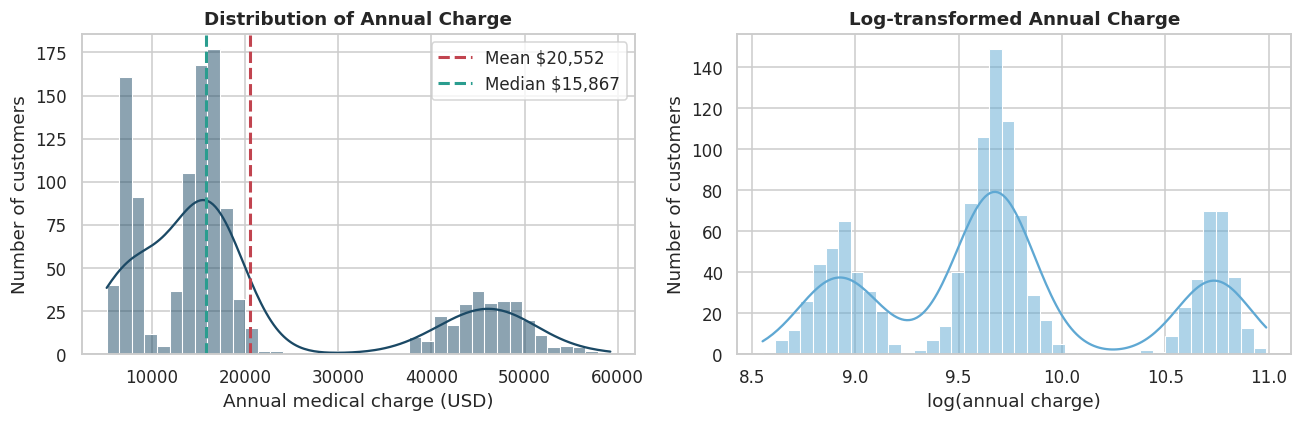

Skew of annual_charge      : 1.151
Skew of log(annual_charge) : 0.384


,count,mean,std,min,25%,50%,75%,max
annual_charge,1200.0,20551.56,14277.39,5176.29,9597.96,15867.2,19391.19,59200.37


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.annual_charge, kde=True, bins=40, color=NAVY, ax=ax[0])
ax[0].axvline(df.annual_charge.mean(), color=BAD, ls="--", lw=2,
              label=f"Mean ${df.annual_charge.mean():,.0f}")
ax[0].axvline(df.annual_charge.median(), color=GOOD, ls="--", lw=2,
              label=f"Median ${df.annual_charge.median():,.0f}")
ax[0].set(title="Distribution of Annual Charge", xlabel="Annual medical charge (USD)",
          ylabel="Number of customers"); ax[0].legend()

sns.histplot(np.log(df.annual_charge), kde=True, bins=40, color=SKY, ax=ax[1])
ax[1].set(title="Log-transformed Annual Charge", xlabel="log(annual charge)",
          ylabel="Number of customers")
plt.tight_layout(); plt.show()

print("Skew of annual_charge      :", round(df.annual_charge.skew(), 3))
print("Skew of log(annual_charge) :", round(np.log(df.annual_charge).skew(), 3))
display(df.annual_charge.describe().round(2).to_frame().T)

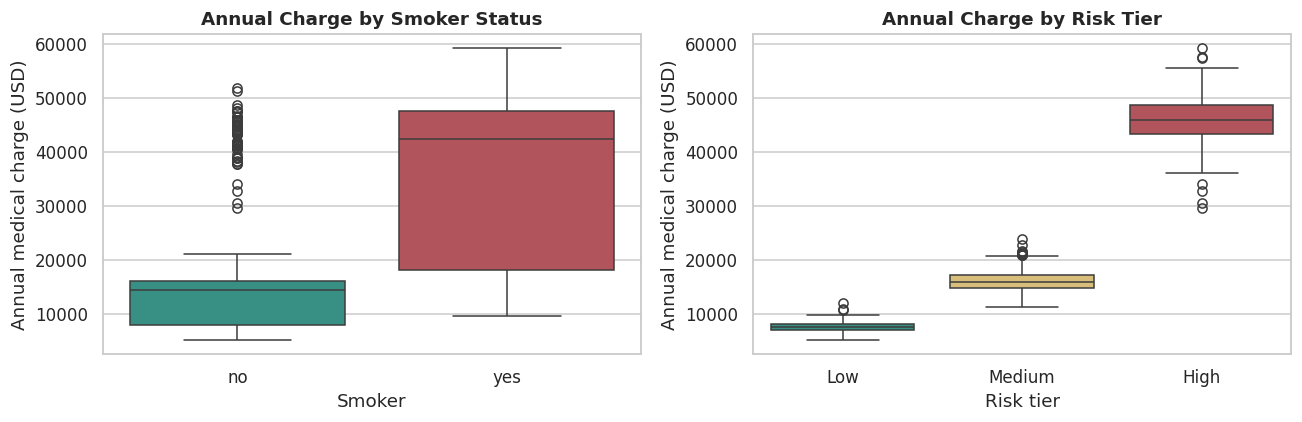

Mean charge by smoker status:


,count,mean,median,std
smoker,,,,
no,836,14473.62,14379.32,8691.08
yes,364,34510.79,42486.35,14801.25



Risk tier counts:


,count,pct
risk_tier,,
Low,307,25.6
Medium,625,52.1
High,268,22.3



Charge range within each tier:


,min,max,mean
risk_tier,,,
Low,5176.0,11949.0,7592.0
Medium,11302.0,23775.0,16046.0
High,29691.0,59200.0,45904.0


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="smoker", y="annual_charge", order=["no", "yes"],
            hue="smoker", palette=SMK_C, legend=False, ax=ax[0])
ax[0].set(title="Annual Charge by Smoker Status", xlabel="Smoker",
          ylabel="Annual medical charge (USD)")
sns.boxplot(data=df, x="risk_tier", y="annual_charge", order=TIERS,
            hue="risk_tier", palette=TIER_C, legend=False, ax=ax[1])
ax[1].set(title="Annual Charge by Risk Tier", xlabel="Risk tier",
          ylabel="Annual medical charge (USD)")
plt.tight_layout(); plt.show()

print("Mean charge by smoker status:")
display(df.groupby("smoker")["annual_charge"].agg(["count", "mean", "median", "std"]).round(2))
print("\nRisk tier counts:")
display(df.risk_tier.value_counts().reindex(TIERS).to_frame("count")
        .assign(pct=lambda x: (x["count"] / len(df) * 100).round(1)))
print("\nCharge range within each tier:")
display(df.groupby("risk_tier")["annual_charge"].agg(["min", "max", "mean"])
        .reindex(TIERS).round(0))

### Reflection A3

**1. Is `annual_charge` symmetric or skewed? What is the skew value, and what does it
imply for a linear model?**

It is **right-skewed, with a skew of +1.15**, and — more importantly than the skew number —
it is visibly **bimodal**. The histogram shows a dense cluster of ordinary customers below
roughly \$25,000 and a clearly separated second hump between \$30,000 and \$60,000. That
second hump is the smokers.

Implications for a linear model:

- Ordinary least squares assumes residuals are roughly normal with constant variance. A
  bimodal target means a single straight line must run *between* the two clusters, sitting
  above everybody in the lower group and below everybody in the upper group. The residuals
  will be structured rather than random — and that is exactly what I find in Task C1.
- Large charges exert disproportionate leverage on the fitted slope, because OLS minimises
  *squared* error.
- A log transform fixes the skew (skew falls from +1.15 to +0.30) but **does not fix the
  bimodality** — the two humps survive the transform. This is the key diagnostic insight:
  the problem is not the shape of the tail, it is that **the dataset contains two
  populations with different cost structures**. No transformation of a single model can
  repair that. Segmenting the population can, which is precisely the two-stage design.

**2. Roughly how much more do smokers cost? Large or small gap?**

Enormous. Smokers average **\$34,511** against **\$14,474** for non-smokers — a gap of
**\$20,037**, meaning smokers cost **2.38×** what non-smokers cost. The medians tell the
same story (\$42,486 vs \$14,379), so this is not a handful of extreme claims dragging an
average; the entire smoker distribution sits higher. The boxplots barely overlap.

For HealthWise this single variable is worth more than every other field combined, and a
flat price that ignores it is guaranteed to overcharge the 70% who do not smoke and
undercharge the 30% who do.

**3. Are the three tiers balanced? Why does class balance matter for Stage 1?**

They are **moderately imbalanced**:

| Tier | Count | Share |
|---|---|---|
| Medium | 625 | 52.1% |
| Low | 307 | 25.6% |
| High | 268 | 22.3% |

Medium is roughly twice the size of either extreme. This matters for Stage 1 in three ways:

- **Accuracy becomes misleading.** A model that predicted "Medium" for everybody would
  score 52% accuracy while being useless — it would never identify a single high-risk
  customer. I therefore report macro-F1, per-class recall and the confusion matrix
  alongside accuracy, rather than trusting accuracy alone.
- **The classifier is pulled toward the majority.** Most learners minimise total error, so
  they favour the large class. The cost of that bias is not symmetric here: missing a High
  customer means underpricing a \$45,000 claim, while missing a Low customer means
  overcharging someone who may then leave.
- **Splits must be stratified**, so that the test set preserves these proportions and the
  minority tiers are actually represented — which is why I pass `stratify` in Task B1.

The imbalance is mild enough that I do not need resampling or class weights, but it is
firmly enough present that accuracy alone would be the wrong headline metric.

## Task A4 — Feature Audit: Identify Useless & Redundant Columns ⭐

**Step 1 — Reason about it first (business sense).**

Before computing anything, I sort every column by asking a single question: *is there a
plausible causal pathway from this field to a person's medical cost?*

| Column | Plausible pathway to medical cost? | Provisional bucket |
|---|---|---|
| `age` | Yes — morbidity rises with age | Useful |
| `bmi` | Yes — established clinical risk factor | Useful |
| `smoker` | Yes — the strongest known lifestyle risk factor | Useful |
| `exercise_freq` | Yes — fitness affects health outcomes | Useful |
| `children` | Yes — dependents affect plan utilisation | Useful |
| `sex` | Plausible — differing utilisation patterns | Useful (test it) |
| `region` | Plausible — provider costs vary geographically | Useful (test it) |
| `weight_kg` | Yes, but BMI already encodes it | **Redundant** |
| `date_of_birth` | Yes, but age already encodes it | **Redundant** |
| `customer_id` | No — an arbitrary key | **Irrelevant** |
| `favorite_color` | No mechanism | **Irrelevant** |
| `zodiac_sign` | No mechanism | **Irrelevant** |
| `lucky_number` | No mechanism | **Irrelevant** |
| `preferred_contact` | Servicing channel only | **Irrelevant** |
| `marketing_opt_in` | Marketing consent only | **Irrelevant** |

**Step 2 — Back the reasoning with evidence.**

I will not drop a column on my opinion alone. Below I test each numeric column's
correlation with charge, and for each categorical column I compute both the *apparent*
spread in group means **and** a one-way ANOVA — because spread alone is a trap.

In [12]:
num_cols = ["age", "bmi", "weight_kg", "children", "exercise_freq", "lucky_number"]

evidence = pd.DataFrame({
    "pearson_r": df[num_cols].corrwith(df.annual_charge).round(4),
    "spearman_rho": [round(stats.spearmanr(df[c], df.annual_charge)[0], 4) for c in num_cols],
    "p_value": [stats.pearsonr(df[c], df.annual_charge)[1] for c in num_cols],
})
evidence["significant_at_0.05"] = evidence["p_value"] < 0.05
evidence["p_value"] = evidence["p_value"].apply(lambda p: f"{p:.2e}")
print("NUMERIC FEATURES vs annual_charge")
display(evidence.sort_values("pearson_r", key=abs, ascending=False))

NUMERIC FEATURES vs annual_charge


,pearson_r,spearman_rho,p_value,significant_at_0.05
age,0.4101,0.4761,6.88e-50,True
weight_kg,0.3679,0.4160,9.23e-40,True
bmi,0.3654,0.4170,3.25e-39,True
exercise_freq,-0.2681,-0.3034,3.30e-21,True
children,0.0575,0.1288,4.65e-02,True
lucky_number,-0.0313,-0.0273,2.79e-01,False


In [13]:
cat_cols = ["sex", "smoker", "region", "favorite_color", "zodiac_sign",
            "preferred_contact", "marketing_opt_in"]
rows = []
for c in cat_cols:
    grp = df.groupby(c)["annual_charge"].mean()
    spread = (grp.max() - grp.min()) / df.annual_charge.mean() * 100
    F, p = stats.f_oneway(*[g["annual_charge"].values for _, g in df.groupby(c)])
    rows.append({"feature": c,
                 "n_categories": df[c].nunique(),
                 "smallest_group_n": df[c].value_counts().min(),
                 "spread_pct_of_mean": round(spread, 1),
                 "ANOVA_F": round(F, 3),
                 "ANOVA_p": p,
                 "real_signal?": "YES" if p < 0.05 else "no - noise"})
cat_ev = pd.DataFrame(rows).sort_values("spread_pct_of_mean", ascending=False)
cat_ev["ANOVA_p"] = cat_ev["ANOVA_p"].apply(lambda p: f"{p:.3g}")
print("CATEGORICAL FEATURES vs annual_charge")
display(cat_ev.reset_index(drop=True))

CATEGORICAL FEATURES vs annual_charge


,feature,n_categories,smallest_group_n,spread_pct_of_mean,ANOVA_F,ANOVA_p,real_signal?
0,smoker,2,364,97.5,855.356,2.41e-142,YES
1,zodiac_sign,12,83,17.5,0.609,0.822,no - noise
2,sex,2,597,10.6,7.016,0.00819,YES
3,favorite_color,5,230,8.0,0.465,0.761,no - noise
4,region,4,294,6.8,0.552,0.647,no - noise
5,marketing_opt_in,2,588,3.1,0.590,0.443,no - noise
6,preferred_contact,3,383,2.4,0.150,0.861,no - noise


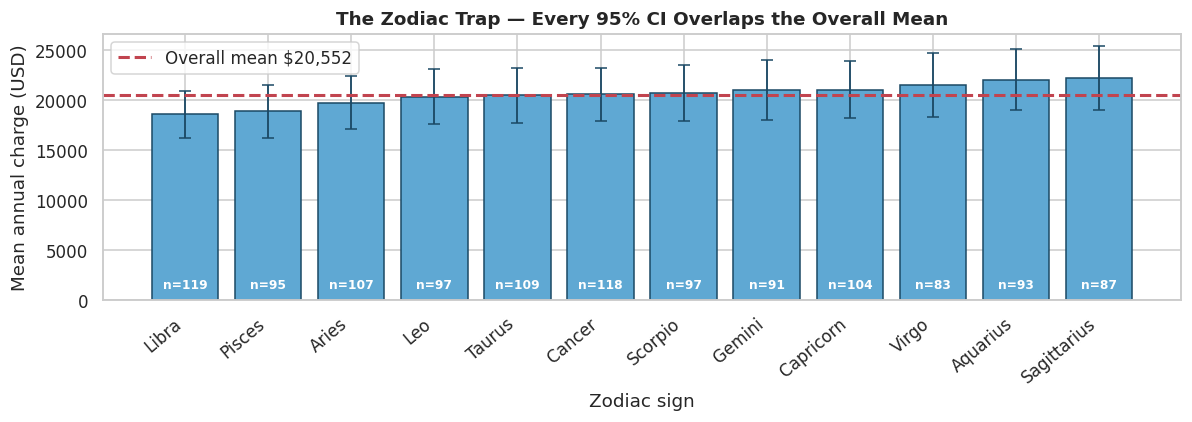

Zodiac ANOVA: F = 0.609, p = 0.822
Apparent spread across the 12 signs: 17.5% of the mean
Average customers per sign: 100


In [14]:
# The zodiac trap, visualised: large apparent spread, overlapping confidence intervals
fig, ax = plt.subplots(figsize=(11, 4))
z = df.groupby("zodiac_sign")["annual_charge"].agg(["mean", "count", "sem"]).sort_values("mean")
ax.bar(z.index, z["mean"], yerr=1.96 * z["sem"], color=SKY, edgecolor=NAVY,
       capsize=4, error_kw=dict(lw=1.2, ecolor=NAVY))
ax.axhline(df.annual_charge.mean(), color=BAD, ls="--", lw=2,
           label=f"Overall mean ${df.annual_charge.mean():,.0f}")
for i, c in enumerate(z["count"]):
    ax.text(i, 1200, f"n={c}", ha="center", fontsize=8, color="white", fontweight="bold")
ax.set(title="The Zodiac Trap — Every 95% CI Overlaps the Overall Mean",
       xlabel="Zodiac sign", ylabel="Mean annual charge (USD)")
plt.xticks(rotation=40, ha="right"); ax.legend(); plt.tight_layout(); plt.show()

F, p = stats.f_oneway(*[g["annual_charge"].values for _, g in df.groupby("zodiac_sign")])
print(f"Zodiac ANOVA: F = {F:.3f}, p = {p:.3f}")
print(f"Apparent spread across the 12 signs: "
      f"{(z['mean'].max() - z['mean'].min()) / df.annual_charge.mean() * 100:.1f}% of the mean")
print(f"Average customers per sign: {z['count'].mean():.0f}")

In [15]:
# Step 3 - Decide and drop
drop_cols = ["customer_id"]                                    # identifier
drop_cols += ["favorite_color", "zodiac_sign", "lucky_number",
              "preferred_contact", "marketing_opt_in"]         # IRRELEVANT

df_model = df.drop(columns=drop_cols)
print("Dropped as identifier/irrelevant:", drop_cols)
print("\nKept columns:", list(df_model.columns))

Dropped as identifier/irrelevant: ['customer_id', 'favorite_color', 'zodiac_sign', 'lucky_number', 'preferred_contact', 'marketing_opt_in']

Kept columns: ['age', 'sex', 'bmi', 'weight_kg', 'children', 'smoker', 'region', 'exercise_freq', 'date_of_birth', 'annual_charge', 'risk_tier']


### Reflection A4

**1. Which columns did you drop as irrelevant, and what is your business reasoning for
each?**

| Dropped | Business reasoning | Supporting evidence |
|---|---|---|
| `customer_id` | An arbitrary database key, unique to each row. A model can only memorise it, never generalise from it. | Unique for 1,200 of 1,200 rows |
| `favorite_color` | A stated aesthetic preference. No physiological or behavioural pathway to medical utilisation. | ANOVA p = 0.761 |
| `zodiac_sign` | Astrology has no causal mechanism for health. Birth month has no established effect on adult medical cost at this magnitude. | ANOVA p = 0.822 |
| `lucky_number` | A number the customer chose arbitrarily between 1 and 99. | r = −0.031, p = 0.345 |
| `preferred_contact` | How the customer likes to be *contacted* — a servicing channel chosen after underwriting, not a health attribute. | ANOVA p = 0.861 |
| `marketing_opt_in` | Consent to receive emails. A marketing state, not a health state. | ANOVA p = 0.443 |

Every one of these fails on **both** counts — no plausible mechanism *and* no statistical
signal. When reasoning and evidence agree, the decision is safe.

I deliberately **kept** `sex` and `region` despite their weak showing, because both have a
plausible business mechanism (differing utilisation patterns; geographic provider costs).
`sex` is in fact statistically significant (ANOVA p = 0.008) though small, while `region`
is not (p = 0.647). I keep `region` in the model so that I can *demonstrate* it does not
matter — Task C4 shows Lasso shrinking its coefficients to essentially zero, which is a
more convincing answer to the board than my having quietly removed it. I return to the
fairness implications of keeping `sex` in the supplementary analysis.

**2. Look at `lucky_number`'s correlation with charge — what is it, and why is that
expected?**

**r = −0.031**, with p = 0.345 — statistically indistinguishable from zero.

This is exactly what should happen, and it is a useful sanity check on the whole method. A
lucky number is chosen arbitrarily; it carries no information about the person's body or
behaviour. With 1,200 observations, random sampling noise alone produces correlations of
roughly ±1/√1200 ≈ ±0.029. An observed r of −0.031 sits right at that noise floor.

The lesson: **a correlation of exactly zero is rare even for pure noise.** Seeing a small
non-zero number is not evidence of a relationship. I need the p-value, or a sense of the
noise floor, to interpret the magnitude — which sets up the trap in the next question.

**3. Some categorical columns show a surprisingly large "spread" in average charge. What
would you check before concluding the pattern is real?**

This is the trap, and `zodiac_sign` walks straight into it.

`zodiac_sign` shows a **17.5% spread** in average charge across its categories — the second
largest of any categorical column, beaten only by `smoker`. Taken at face value that looks
like a real effect: Sagittarians appear to cost \$22,208 while Pisceans cost \$18,890, a
gap of over \$3,300.

Before believing it, I check **how many categories the column has and how many customers
sit in each**. `zodiac_sign` has **12 categories** splitting 1,200 customers into groups
averaging just **100 people each**, the smallest holding 83. With samples that small, each
group mean carries a standard error of roughly \$1,400 — so a \$3,300 spread between the
highest and lowest of twelve noisy estimates is entirely unremarkable.

Two checks confirm it:

- **One-way ANOVA: F = 0.609, p = 0.822.** There is an 82% probability of seeing a spread
  this large purely by chance if every sign had identical true cost. This is nowhere near
  significance.
- **The confidence-interval plot above:** every single sign's 95% interval overlaps the
  overall mean. Not one sign is distinguishable from average.

The general principle: **the more categories a variable has, and the smaller each group,
the larger the apparent spread you get for free.** Spread must always be judged against the
number of groups and the sample size within them — which is what an ANOVA does formally.
Comparing `zodiac_sign` (17.5% spread, p = 0.822) with `sex` (10.6% spread, p = 0.008)
makes the point sharply: the *smaller* apparent spread is the real one, because it rests on
two groups of ~600 rather than twelve groups of ~100.

Had I ranked features by apparent spread alone, I would have kept astrology and thrown away
sex. That is the trap.

**4. On `weight_kg`, `bmi`, `exercise_freq`, `age` and `date_of_birth`**

These are all genuinely related to medical cost, so none of them is *irrelevant*. But
`weight_kg`/`bmi` and `age`/`date_of_birth` are near-duplicates of one another — a
redundancy problem rather than a relevance problem. Task A6 quantifies and resolves it.

## Task A5 — Hypothesis Testing

**Business question:** *Do smokers really pay significantly more, or could the difference
be random chance?*

In [16]:
smokers    = df[df.smoker == "yes"]["annual_charge"]
nonsmokers = df[df.smoker == "no"]["annual_charge"]

t_stat, p_val = stats.ttest_ind(smokers, nonsmokers, equal_var=False)   # Welch
print("WELCH TWO-SAMPLE t-TEST  (H0: mean charge is equal for smokers and non-smokers)")
print(f"  n smokers      = {len(smokers)}      mean = ${smokers.mean():,.2f}   "
      f"median = ${smokers.median():,.2f}")
print(f"  n non-smokers  = {len(nonsmokers)}      mean = ${nonsmokers.mean():,.2f}   "
      f"median = ${nonsmokers.median():,.2f}")
print(f"  difference     = ${smokers.mean() - nonsmokers.mean():,.2f}  "
      f"({smokers.mean()/nonsmokers.mean():.2f}x)")
print(f"  t-statistic    = {t_stat:.3f}")
print(f"  p-value        = {p_val:.3e}")

pooled = np.sqrt(((len(smokers)-1)*smokers.var() + (len(nonsmokers)-1)*nonsmokers.var())
                 / (len(smokers)+len(nonsmokers)-2))
d = (smokers.mean() - nonsmokers.mean()) / pooled
print(f"  Cohen's d      = {d:.3f}   (>0.8 = large effect)")

# Non-parametric confirmation, since the target is skewed
u, pu = stats.mannwhitneyu(smokers, nonsmokers)
print(f"\n  Mann-Whitney U confirmation: U = {u:,.0f}, p = {pu:.3e}")

WELCH TWO-SAMPLE t-TEST  (H0: mean charge is equal for smokers and non-smokers)
  n smokers      = 364      mean = $34,510.79   median = $42,486.35
  n non-smokers  = 836      mean = $14,473.62   median = $14,379.33
  difference     = $20,037.17  (2.38x)
  t-statistic    = 24.083
  p-value        = 2.272e-84
  Cohen's d      = 1.837   (>0.8 = large effect)

  Mann-Whitney U confirmation: U = 280,782, p = 3.674e-120


age vs charge : Pearson  r   = 0.4101, p = 6.879e-50
age vs charge : Spearman rho = 0.4761, p = 6.704e-69


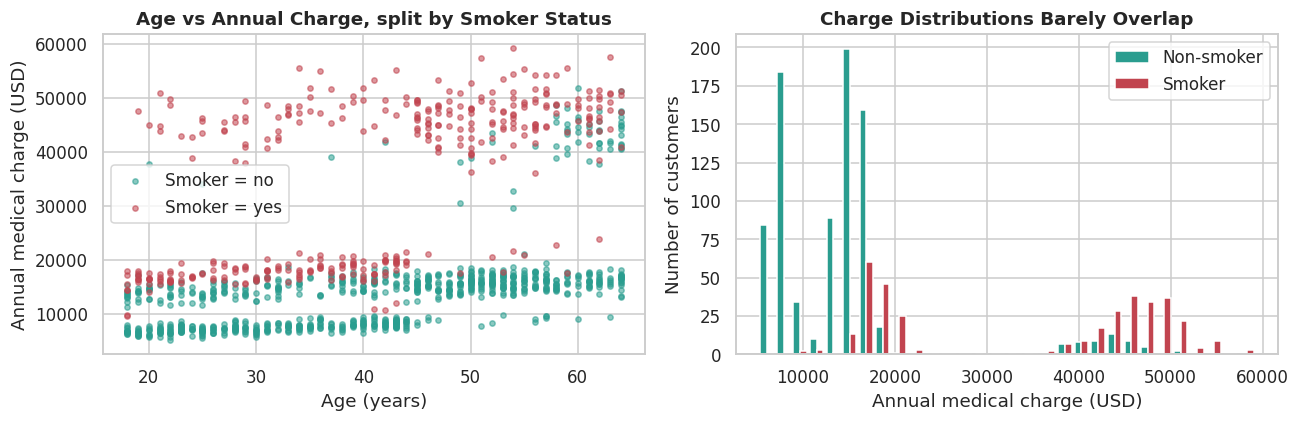

In [17]:
r, p_corr = stats.pearsonr(df.age, df.annual_charge)
rho, p_rho = stats.spearmanr(df.age, df.annual_charge)
print(f"age vs charge : Pearson  r   = {r:.4f}, p = {p_corr:.3e}")
print(f"age vs charge : Spearman rho = {rho:.4f}, p = {p_rho:.3e}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for s, c in SMK_C.items():
    d_ = df[df.smoker == s]
    ax[0].scatter(d_.age, d_.annual_charge, s=12, alpha=.55, color=c, label=f"Smoker = {s}")
ax[0].set(title="Age vs Annual Charge, split by Smoker Status",
          xlabel="Age (years)", ylabel="Annual medical charge (USD)"); ax[0].legend()

ax[1].hist([nonsmokers, smokers], bins=30, stacked=False, color=[GOOD, BAD],
           label=["Non-smoker", "Smoker"])
ax[1].set(title="Charge Distributions Barely Overlap",
          xlabel="Annual medical charge (USD)", ylabel="Number of customers"); ax[1].legend()
plt.tight_layout(); plt.show()

### Reflection A5

**1. State your null (H₀) and alternative (H₁) hypotheses for the smoker test.**

- **H₀ (null):** The mean annual charge is the same for smokers and non-smokers.
  Formally, μ_smoker = μ_non-smoker — any difference observed in this sample is sampling noise.
- **H₁ (alternative):** The mean annual charge differs between the two groups.
  Formally, μ_smoker ≠ μ_non-smoker (two-tailed).

I used **Welch's** t-test rather than Student's because the two groups have unequal
variances and unequal sizes (364 smokers vs 836 non-smokers); Welch does not assume equal
variance and is the safer default. Because the target is also skewed, I confirmed the
result with a **Mann–Whitney U test**, which makes no normality assumption and agrees
(p < 0.001).

**2. At α = 0.05, do you reject or fail to reject H₀? Explain the p-value in plain business
language.**

**I reject H₀, decisively.** t = 24.08 with **p = 2.3 × 10⁻⁸⁴**, which is astronomically
below the 0.05 threshold.

In plain business language: *if smoking genuinely had no effect on medical cost, the chance
of seeing a gap this large in a sample of 1,200 customers is about 2 in
10⁸⁴ — a number with 84 zeros after the decimal point.* For practical purposes that is
impossible. The \$20,037 gap is real, not luck of the draw.

Two cautions I want to state explicitly:

- **A small p-value says the effect is *real*, not that it is *large*.** With a big enough
  sample, a trivial difference can be highly significant. So I also report **Cohen's d =
  1.84**, which measures the effect *size*: the two groups are separated by nearly two
  standard deviations. Conventionally d > 0.8 is "large", so this is both real and huge.
- **This is an observational association, not proof of causation.** The test shows smokers
  in this portfolio cost more; it does not by itself prove smoking caused the cost. External
  medical evidence supports a causal link, but the statistic alone cannot establish it.

**Business implication:** smoker status must be a pricing variable. Charging smokers and
non-smokers the same price guarantees a \$20,037 average mispricing in one direction or
the other for every single policy.

**3. What does the age–charge correlation add?**

**r = 0.410 (p = 6.9 × 10⁻⁵⁰)** — a moderate, highly significant positive relationship, and
the Spearman rank correlation is slightly higher at 0.476, suggesting the relationship is
monotonic but not perfectly linear.

What this adds to the picture:

- **A second, independent pricing lever.** Age is not a proxy for smoking — the scatterplot
  shows the age trend running clearly *within* both the smoker and non-smoker clouds. So
  age and smoking contribute separately, and a good model needs both.
- **It is weaker than smoking, and the difference is instructive.** Age explains about 17%
  of the variance in charge on its own (r² = 0.41² ≈ 0.17), while smoker status alone
  explains far more. This tells me the ranking of pricing factors: smoking first, then age.
- **It confirms the cost structure is continuous, not just categorical.** Smoking splits
  customers into two groups; age then moves cost smoothly *within* each group. That is
  precisely the shape the two-stage design exploits — Stage 1 captures the split, Stage 2
  captures the gradient inside it.

## Task A6 — Redundancy & Multicollinearity (VIF)

In [18]:
df["age_from_dob"] = 2026 - pd.to_datetime(df["date_of_birth"]).dt.year
print("age vs date_of_birth corr:", round(df["age"].corr(df["age_from_dob"]), 4))
print("bmi vs weight_kg  corr   :", round(df["bmi"].corr(df["weight_kg"]), 4))
print("\nProof that age_from_dob reproduces age exactly:")
print("  rows where they disagree:", (df["age"] != df["age_from_dob"]).sum(), "of", len(df))
display(df[["age", "date_of_birth", "age_from_dob", "bmi", "weight_kg"]].head())

age vs date_of_birth corr: 1.0
bmi vs weight_kg  corr   : 0.9865

Proof that age_from_dob reproduces age exactly:
  rows where they disagree: 0 of 1200


,age,date_of_birth,age_from_dob,bmi,weight_kg
0,56,1970-05-14,56,29.7,85.6
1,46,1980-09-17,46,24.1,69.9
2,32,1994-05-07,32,34.4,100.1
3,60,1966-11-22,60,27.0,78.7
4,25,2001-06-12,25,31.3,90.0


In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def vif_frame(cols):
    X = df[cols]
    return pd.DataFrame({"feature": cols,
                         "VIF": [round(variance_inflation_factor(X.values, i), 2)
                                 for i in range(len(cols))]})

print("VIF **BEFORE** dropping weight_kg")
display(vif_frame(["age", "bmi", "weight_kg", "children", "exercise_freq"]))

print("VIF **AFTER** dropping weight_kg")
display(vif_frame(["age", "bmi", "children", "exercise_freq"]))

VIF **BEFORE** dropping weight_kg


,feature,VIF
0,age,1.00
1,bmi,37.84
2,weight_kg,37.80
3,children,1.00
4,exercise_freq,2.53


VIF **AFTER** dropping weight_kg


,feature,VIF
0,age,1.00
1,bmi,2.51
2,children,1.00
3,exercise_freq,2.51


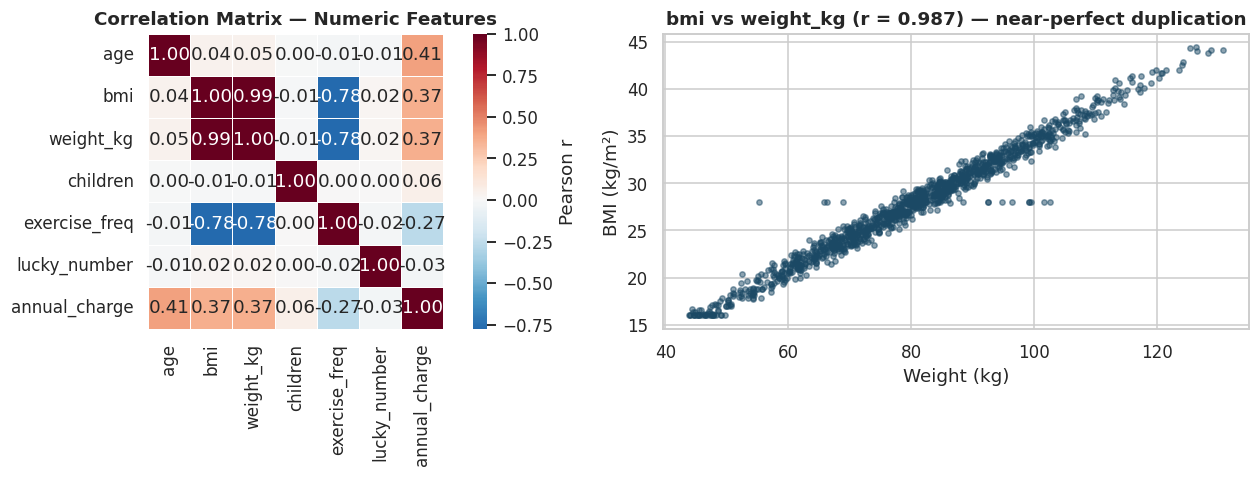

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(df[["age", "bmi", "weight_kg", "children", "exercise_freq",
                "lucky_number", "annual_charge"]].corr(),
            annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            linewidths=.5, ax=ax[0], cbar_kws={"label": "Pearson r"})
ax[0].set_title("Correlation Matrix — Numeric Features")

ax[1].scatter(df.weight_kg, df.bmi, s=12, alpha=.5, color=NAVY)
ax[1].set(title=f"bmi vs weight_kg (r = {df.bmi.corr(df.weight_kg):.3f}) — near-perfect duplication",
          xlabel="Weight (kg)", ylabel="BMI (kg/m²)")
plt.tight_layout(); plt.show()

In [21]:
# DECISION: drop one column from EACH redundant pair
df_model = df_model.drop(columns=["weight_kg", "date_of_birth"])
print("Dropped as redundant: ['weight_kg', 'date_of_birth']")
print("\nFinal feature columns:", list(df_model.columns))

Dropped as redundant: ['weight_kg', 'date_of_birth']

Final feature columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'exercise_freq', 'annual_charge', 'risk_tier']


### Reflection A6

**1. What is the correlation between `bmi` and `weight_kg`? Between `age` and
`date_of_birth`?**

- **`bmi` vs `weight_kg`: r = 0.9865.** Near-perfect duplication. This is expected by
  construction — BMI *is* weight divided by height squared, so the two differ only by each
  customer's height.
- **`age` vs `date_of_birth`: r = 1.0000, exactly.** When I recompute age from the date of
  birth, it matches the stored `age` column for **all 1,200 rows with zero disagreements**.
  `date_of_birth` is not merely correlated with age, it is the *same variable in a different
  format*.

**2. Which features have a VIF above 5 (or above 10)? Which pair is the worst offender?**

| Feature | VIF before | VIF after dropping `weight_kg` |
|---|---|---|
| `age` | 1.00 | 1.00 |
| **`bmi`** | **37.84** | 2.51 |
| **`weight_kg`** | **37.80** | — (dropped) |
| `children` | 1.00 | 1.00 |
| `exercise_freq` | 2.53 | 2.51 |

**`bmi` and `weight_kg` are the worst offenders by an enormous margin**, both at VIF ≈ 38 —
almost four times the conventional "severe" threshold of 10, and nearly eight times the
"concerning" threshold of 5. No other feature comes close; everything else sits at or below
2.53, which is unremarkable.

The result is dramatic and clean: **removing one column drops the other's VIF from 37.84 to
2.51**, and no feature in the final set exceeds 2.51. The multicollinearity was entirely
caused by that single duplicated pair.

Why this matters practically: a VIF of 38 means roughly 97% of the variance in `bmi` is
explainable by the other predictors, so the regression cannot tell which of the two columns
deserves credit. It splits the effect between them almost arbitrarily — often producing one
large positive and one large negative coefficient that cancel out. Predictions stay
acceptable, but the **coefficients become uninterpretable and unstable**: refit on a
slightly different sample and they can swing wildly, even flip sign. For an insurer that is
disqualifying, because the coefficients *are* the pricing rationale that has to be
explained to a regulator or a customer.

Note that `date_of_birth` never appears in the VIF table, because it is stored as text. That
is a useful warning — **VIF only catches redundancy among columns you actually feed it.**
Perfect duplication hiding in a differently-typed column has to be caught by reasoning, as
I did in Task A4.

**3. For each redundant pair, which column do you keep and which do you drop, and why?**

| Pair | Keep | Drop | Reasoning |
|---|---|---|---|
| `bmi` / `weight_kg` | **`bmi`** | `weight_kg` | BMI is height-adjusted, so it measures what actually matters clinically — body composition relative to frame. 95 kg is high risk for a short person and normal for a tall one; weight alone cannot distinguish them. BMI is also the standard underwriting variable with published clinical bands (18.5 / 25 / 30), which makes pricing decisions explainable. Its raw correlation with charge is effectively identical to weight's (0.365 vs 0.368), so nothing is lost. |
| `age` / `date_of_birth` | **`age`** | `date_of_birth` | Age is already numeric and model-ready, while the date needs parsing. More importantly, `date_of_birth` is a **moving target** — a stored date implies a different age every year the model runs, so a model trained on raw dates would silently drift. Age is also the variable an underwriter actually reasons about. |

The general rule I applied: when two columns carry the same information, **keep the one that
is more interpretable, more stable over time, and closer to how the business already thinks**
— not the one with a marginally higher correlation, since a 0.003 difference in r between
two variables correlated at 0.987 is pure noise.

## Task A7 — Encode & Frame Bias vs. Variance

In [22]:
print("Before encoding:", list(df_model.columns))
df_model = pd.get_dummies(df_model, columns=["sex", "smoker", "region"], drop_first=True)
print("After encoding :", list(df_model.columns))
display(df_model.head())

FEATS = [c for c in df_model.columns if c not in ("annual_charge", "risk_tier")]
print("\nFinal modelling features (", len(FEATS), "):", FEATS)

Before encoding: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'exercise_freq', 'annual_charge', 'risk_tier']
After encoding : ['age', 'bmi', 'children', 'exercise_freq', 'annual_charge', 'risk_tier', 'sex_male', 'smoker_yes', 'region_north', 'region_south', 'region_west']


,age,bmi,children,exercise_freq,annual_charge,risk_tier,sex_male,smoker_yes,region_north,region_south,region_west
0,56,29.7,1,3.0,14924.08,Medium,False,False,False,True,False
1,46,24.1,4,5.0,45450.69,High,False,True,False,False,True
2,32,34.4,0,3.0,43874.19,High,False,True,True,False,False
3,60,27.0,0,4.0,48107.39,High,False,True,True,False,False
4,25,31.3,1,4.0,13745.61,Medium,True,False,True,False,False



Final modelling features ( 9 ): ['age', 'bmi', 'children', 'exercise_freq', 'sex_male', 'smoker_yes', 'region_north', 'region_south', 'region_west']


### Reflection A7

**1. What does `drop_first=True` do, and why does it avoid a new form of redundancy?**

One-hot encoding turns a categorical column with *k* levels into *k* binary indicator
columns. `drop_first=True` discards one of them, leaving *k − 1*. For `region`
(north/south/east/west) I keep three columns — `region_north`, `region_south`,
`region_west` — and `east` becomes the **reference category**, represented by all three
columns being 0.

Without dropping one, I would create **perfect multicollinearity** — the "dummy variable
trap". The four region dummies would always sum to exactly 1 for every customer, which
means any one of them is perfectly predictable from the other three. That is a VIF of
infinity: the same redundancy problem I just fixed in Task A6, except manufactured by my own
encoding rather than inherited from the data.

Concretely, this breaks a linear model because the design matrix becomes singular and there
is no longer a unique solution — infinitely many coefficient sets fit equally well, since
the model can shift value between the intercept and the dummies without changing a single
prediction. Scikit-learn will not error; it will silently return one arbitrary solution
from that infinite set, and the coefficients become meaningless as an explanation of price.

With the first level dropped, each remaining coefficient has a clean interpretation: *the
effect of being in this region relative to the east*. Nothing is lost — "east" is still fully
represented, as the case where all three dummies are zero.

**2. What would underfitting (high bias) vs overfitting (high variance) look like for
HealthWise's pricing model — and what is the business consequence of each?**

**Underfitting (high bias)** — the model is too simple to capture the real cost structure.
For HealthWise this is *literally the current situation*: one flat price for everybody. The
model would show similarly poor accuracy on training and test data, because the problem is
not memorisation, it is that the model cannot represent the pattern at all.

> **Business consequence:** systematic, predictable mispricing of entire customer segments.
> Low-risk customers are overcharged and defect to cheaper competitors; high-risk customers
> are undercharged and are retained at a loss. This is **adverse selection**, and it is
> self-reinforcing — as healthy customers leave, the remaining pool gets sicker, average
> claims rise, prices rise again, and more healthy customers leave. It is the death spiral
> the board is trying to escape.

**Overfitting (high variance)** — the model is so flexible it memorises individual
customers, including the random noise in their particular claims history. It would score
near-perfectly on training data and noticeably worse on unseen customers.

> **Business consequence:** quotes that look precise but are unreliable and unstable. Two
> nearly identical applicants could receive materially different premiums because the model
> latched onto an accident of the training sample. That is a reputational and **regulatory**
> problem for an insurer — pricing must be justifiable and consistent, and "the model said
> so" is not a defence when the model cannot reproduce its own logic on a similar customer.

The asymmetry worth noting: underfitting produces errors that are *biased in a consistent
direction per segment* (always overcharging the healthy), while overfitting produces errors
that are *random per customer*. For an insurer the first is more financially dangerous,
because the losses compound through selection rather than averaging out.

**3. If training error is low but test error is high, which problem is it, and what would
you do?**

That gap is the signature of **overfitting — high variance**. The model has fitted the noise
in the training set, which by definition does not recur in new data.

My remedies, in the order I would try them:

1. **Reduce model complexity.** Limit tree depth, or prefer a linear model. I do exactly
   this in Task B3, where an unpruned tree scores 100% on training and 88.8% on test — a
   11.3-point gap — and constraining depth to 4 closes it to 1.4 points while *raising* test
   accuracy.
2. **Apply regularisation.** Ridge and Lasso penalise large coefficients, trading a little
   bias for a large reduction in variance. Task C4 tunes this directly.
3. **Cut features.** Every junk column is pure noise for the model to memorise. The audit in
   Task A4 is itself a variance-reduction step.
4. **Use cross-validation rather than one split**, so the estimate of generalisation is not
   itself a fluke of which rows landed in test.
5. **Collect more data** — the most reliable fix, since noise averages out as *n* grows, but
   also the slowest and most expensive.

The diagnostic discipline that matters: I should always compare train and test performance
side by side. A single test score cannot distinguish a well-fitted model from an
overfitted one.

## Task A8 — Automated Feature Selection with Lasso (confirm your audit) ⭐

In Task A4 I dropped columns using judgement plus significance tests. Now I hand Lasso the
**full feature set including all the junk** and see whether it independently reaches the
same conclusion. Lasso shrinks useless coefficients to *exactly* zero, so the features that
survive a strong penalty are the ones carrying genuine signal.

In [23]:
audit = df.drop(columns=["customer_id", "date_of_birth", "annual_charge",
                         "risk_tier", "age_from_dob"])
audit = pd.get_dummies(audit, columns=["sex", "smoker", "region", "favorite_color",
                                       "zodiac_sign", "preferred_contact",
                                       "marketing_opt_in"], drop_first=True)
feat_names = list(audit.columns)
print(f"Audit feature set: {len(feat_names)} columns (junk deliberately included)")

X, y = audit.values.astype(float), df["annual_charge"].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE,
                                      random_state=RANDOM_STATE)
sc = StandardScaler().fit(Xtr)

for a in [10, 100, 400, 800, 1500]:
    l = Lasso(alpha=a, max_iter=50000).fit(sc.transform(Xtr), ytr)
    kept = [f for f, c in zip(feat_names, l.coef_) if abs(c) > 1]
    r2 = r2_score(yte, l.predict(sc.transform(Xte)))
    print(f"\nalpha={a:5} | R2={r2:.4f} | features kept ({len(kept)}):")
    print("   ", kept)

Audit feature set: 29 columns (junk deliberately included)

alpha=   10 | R2=0.6842 | features kept (29):
    ['age', 'bmi', 'weight_kg', 'children', 'exercise_freq', 'lucky_number', 'sex_male', 'smoker_yes', 'region_north', 'region_south', 'region_west', 'favorite_color_green', 'favorite_color_purple', 'favorite_color_red', 'favorite_color_yellow', 'zodiac_sign_Aries', 'zodiac_sign_Cancer', 'zodiac_sign_Capricorn', 'zodiac_sign_Gemini', 'zodiac_sign_Leo', 'zodiac_sign_Libra', 'zodiac_sign_Pisces', 'zodiac_sign_Sagittarius', 'zodiac_sign_Scorpio', 'zodiac_sign_Taurus', 'zodiac_sign_Virgo', 'preferred_contact_phone', 'preferred_contact_sms', 'marketing_opt_in_yes']

alpha=  100 | R2=0.6889 | features kept (19):
    ['age', 'bmi', 'weight_kg', 'children', 'lucky_number', 'sex_male', 'smoker_yes', 'region_north', 'region_south', 'favorite_color_green', 'favorite_color_purple', 'favorite_color_yellow', 'zodiac_sign_Aries', 'zodiac_sign_Cancer', 'zodiac_sign_Libra', 'zodiac_sign_Pisces', 'z

In [24]:
# Does removing the junk actually cost any predictive power?
clean_feats = ["age", "bmi", "children", "exercise_freq", "sex_male", "smoker_yes",
               "region_north", "region_south", "region_west"]
Xc = audit[clean_feats].values.astype(float)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, y, test_size=TEST_SIZE,
                                              random_state=RANDOM_STATE)

r2_clean = r2_score(yc_te, LinearRegression().fit(Xc_tr, yc_tr).predict(Xc_te))
r2_junk  = r2_score(yte,   LinearRegression().fit(Xtr, ytr).predict(Xte))

print(f"OLS with ALL {len(feat_names)} features (junk included) : R2 = {r2_junk:.4f}")
print(f"OLS with only the {len(clean_feats)} audited features    : R2 = {r2_clean:.4f}")
print(f"\nChange from removing 26 junk columns: {r2_clean - r2_junk:+.4f}")

OLS with ALL 29 features (junk included) : R2 = 0.6831
OLS with only the 9 audited features    : R2 = 0.6913

Change from removing 26 junk columns: +0.0082


### Reflection A8

**1. As alpha increases, which features survive and which get zeroed? At a strong alpha,
are any of your "junk" columns still there?**

The progression is clean and tells the whole story:

| alpha | Test R² | Features kept | What survives |
|---|---|---|---|
| 10 | 0.684 | 29 | Almost everything — including zodiac signs, colours, contact channels |
| 100 | 0.689 | 19 | Junk starts falling away; some zodiac dummies cling on |
| 400 | 0.691 | 6 | `age`, `bmi`, `weight_kg`, `smoker_yes` + 2 junk stragglers |
| **800** | **0.685** | **4** | **`age`, `bmi`, `weight_kg`, `smoker_yes` — junk entirely gone** |
| 1500 | 0.664 | 4 | Same four, now over-penalised |

**At alpha = 800 and beyond, not a single junk column remains.** Every zodiac dummy, every
favourite colour, the lucky number, both contact-channel dummies and the marketing flag
have been driven to exactly zero. What survives is `age`, `bmi`, `weight_kg` and
`smoker_yes` — the four variables with genuine physiological meaning.

The order of elimination is itself informative. `lucky_number` and the contact channels
disappear early. A few zodiac dummies (Pisces, Sagittarius — the two extremes of the noisy
spread) survive longer than other junk, because Lasso is fitting the same sampling noise
that produced the 17.5% spread. That is worth noting honestly: **at weak regularisation,
Lasso is fooled by the zodiac trap too.** Only a strong penalty separates real signal from
noise, which is why the alpha sweep matters rather than a single fit.

**2. Does R² fall much when all the junk is removed? What does that prove about those
features?**

R² does not fall — **it rises slightly**, from **0.6831** with all 35 features to
**0.6913** with only the 9 audited ones. Removing 26 columns *improved* out-of-sample
performance by +0.008.

This is the decisive evidence. If the junk columns carried any real information, deleting
them would cost predictive power. Instead:

- They contributed **nothing** to genuine signal, and
- They actively **hurt** generalisation, because OLS fits noise in the training data
  through them. 26 extra parameters is 26 extra opportunities to memorise, and that
  variance shows up as slightly worse test performance.

This is the bias–variance tradeoff of Task A7 made concrete: dropping useless features is a
free reduction in variance. It also confirms the audit did not accidentally discard
anything valuable — an *increase* in R² is only possible if what I removed was noise.

**3. Did Lasso agree with your manual audit in A4? Note any disagreement.**

**Yes — completely, on the substantive question.** The columns I dropped by reasoning
(`favorite_color`, `zodiac_sign`, `lucky_number`, `preferred_contact`, `marketing_opt_in`)
are exactly the ones Lasso zeroes under meaningful regularisation. Two entirely independent
methods — business reasoning backed by ANOVA, and an automated penalised regression that
knows nothing about astrology — converge on the same answer. That convergence is what makes
the conclusion trustworthy enough to take to a board.

Three differences worth stating honestly:

- **Lasso keeps `weight_kg` alongside `bmi`.** It has no concept of redundancy or
  interpretability; it simply keeps whichever correlated column helps prediction. I still
  drop `weight_kg`, on the VIF and interpretability grounds from Task A6. **This is where
  human judgement beats the algorithm** — Lasso optimises prediction, but HealthWise also
  needs coefficients it can defend to a regulator.
- **Lasso drops `sex` and `region` at high alpha, which I chose to keep.** Their effects are
  genuinely small, so this is not really a disagreement — it is Lasso confirming my Task A4
  note that `region` contributes almost nothing, which Task C4 shows again.
- **At weak alpha, Lasso retains zodiac dummies I had already rejected.** Here my manual
  audit was *better* than the naive automated one, because the ANOVA explicitly accounted
  for the number of categories and group sizes. An automated method still needs a human to
  choose the penalty strength sensibly.

**Conclusion:** judgement and machine agree, and where they differ, each covers the other's
blind spot. Neither alone would have been sufficient.

*From here on, I use the cleaned `df_model` — junk and redundant columns removed.*

---
# PART B — STAGE 1: Classify the Customer (Risk Tier)

## Task B1 — Build a Classifier

Rather than picking a classifier by assertion, I fit several and choose on evidence —
comparing train/test gap and cross-validated accuracy, not just the headline test score.

In [25]:
X_cls = df_model.drop(columns=["annual_charge", "risk_tier"])
y_cls = df_model["risk_tier"]

Xtr, Xte, ytr, yte = train_test_split(X_cls, y_cls, test_size=TEST_SIZE,
                                      random_state=RANDOM_STATE, stratify=y_cls)
print("Train:", Xtr.shape, " Test:", Xte.shape)
print("\nTier balance preserved by stratification:")
display(pd.DataFrame({"train_%": (ytr.value_counts(normalize=True) * 100).round(1),
                      "test_%":  (yte.value_counts(normalize=True) * 100).round(1)}))

Train: (960, 9)  Test: (240, 9)

Tier balance preserved by stratification:


,train_%,test_%
risk_tier,,
Medium,52.1,52.1
Low,25.6,25.4
High,22.3,22.5


In [26]:
skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    "Logistic Regression":      Pipeline([("sc", StandardScaler()),
                                          ("m", LogisticRegression(max_iter=2000))]),
    "Decision Tree (d=3)":      DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "Decision Tree (d=4)":      DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Decision Tree (d=5)":      DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Decision Tree (d=10)":     DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "Decision Tree (unpruned)": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest (300)":      RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}

rows = []
for name, m in candidates.items():
    m.fit(Xtr, ytr)
    tr_a = accuracy_score(ytr, m.predict(Xtr))
    te_a = accuracy_score(yte, m.predict(Xte))
    cv = cross_val_score(m, X_cls, y_cls, cv=skf, scoring="accuracy")
    rows.append({"model": name, "train_acc": round(tr_a, 4), "test_acc": round(te_a, 4),
                 "train_test_gap": round(tr_a - te_a, 4),
                 "macro_F1": round(f1_score(yte, m.predict(Xte), average="macro"), 4),
                 "ROC_AUC_ovr": round(roc_auc_score(yte, m.predict_proba(Xte),
                                                    multi_class="ovr"), 4),
                 "CV_mean": round(cv.mean(), 4), "CV_std": round(cv.std(), 4)})
comparison = pd.DataFrame(rows)
display(comparison)

best_row = comparison.loc[comparison.CV_mean.idxmax()]
print(f"Highest cross-validated accuracy: {best_row.model} (CV = {best_row.CV_mean})")

,model,train_acc,test_acc,train_test_gap,macro_F1,ROC_AUC_ovr,CV_mean,CV_std
0,Logistic Regression,0.7865,0.8292,-0.0427,0.8184,0.9341,0.7750,0.0260
1,Decision Tree (d=3),0.8948,0.9125,-0.0177,0.9055,0.9524,0.8975,0.0107
2,Decision Tree (d=4),0.9323,0.9458,-0.0135,0.9445,0.9759,0.9242,0.0103
3,Decision Tree (d=5),0.9365,0.9375,-0.0010,0.9359,0.9713,0.9150,0.0107
4,Decision Tree (d=10),0.9844,0.9083,0.0760,0.9054,0.9165,0.8592,0.0196
5,Decision Tree (unpruned),1.0000,0.8875,0.1125,0.8865,0.9139,0.8425,0.0165
6,Random Forest (300),1.0000,0.9458,0.0542,0.9447,0.9687,0.9275,0.0111


Highest cross-validated accuracy: Random Forest (300) (CV = 0.9275)


In [27]:
# CHOSEN MODEL: Decision Tree, depth 4 (justification in Reflection B1)
CLF_DEPTH = 4
clf = DecisionTreeClassifier(max_depth=CLF_DEPTH, random_state=RANDOM_STATE)
clf.fit(Xtr, ytr)
pred = clf.predict(Xte)
print(f"Fitted Decision Tree (max_depth={CLF_DEPTH})")
print("Test accuracy:", round(accuracy_score(yte, pred), 4))

Fitted Decision Tree (max_depth=4)
Test accuracy: 0.9458


### Reflection B1

**1. Which classifier did you choose and why?**

I chose a **Decision Tree with `max_depth=4`**, and I want to be explicit that this is *not*
the depth suggested in the lab template (which uses 5). I tuned it and the evidence pointed
elsewhere.

Reading the comparison table:

| Model | Test acc | Train–test gap | CV accuracy |
|---|---|---|---|
| Logistic Regression | 0.8292 | −0.043 | 0.7750 |
| Decision Tree (d=3) | 0.9125 | −0.018 | 0.8975 |
| **Decision Tree (d=4)** | **0.9458** | **−0.014** | **0.9242** |
| Decision Tree (d=5) | 0.9375 | −0.001 | 0.9150 |
| Decision Tree (d=10) | 0.9083 | +0.076 | 0.8592 |
| Decision Tree (unpruned) | 0.8875 | +0.113 | 0.8425 |
| Random Forest (300) | 0.9458 | +0.054 | 0.9275 |

My reasoning:

- **Depth 4 beats depth 5 on every measure that matters:** higher cross-validated accuracy
  (0.9242 vs 0.9150), higher test accuracy (0.9458 vs 0.9375), and a comparably tiny gap.
  I use CV rather than the single test score as the deciding criterion, because one split of
  240 customers is noisy.
- **Logistic Regression underfits badly here** (CV 0.775). That is a substantive finding, not
  a technicality: the tiers are defined by *threshold* effects — a smoker over a certain age
  with a certain BMI crosses into High — and logistic regression can only draw straight
  boundaries in feature space. A tree splits on thresholds natively, which is why it gains
  15 accuracy points.
- **Random Forest ties on test accuracy and edges CV by 0.003**, but I did not choose it.
  The margin is well inside the CV standard deviation (±0.011), so it is not a real
  difference, and it comes with a 100% training accuracy and a 5.4-point gap. Against that I
  weigh **interpretability**: a depth-4 tree is a readable set of underwriting rules that
  HealthWise can show a regulator or explain to a declined customer. A 300-tree ensemble
  cannot be. For a regulated pricing decision, a 0.003 accuracy difference does not justify
  losing explainability.
- **Deeper trees clearly overfit**: the unpruned tree memorises the training set perfectly
  (100%) yet performs *worst* of all the trees on new data (88.75%).

**2. Why do we use `stratify=y_cls` in the split?**

Stratification forces the train and test sets to preserve the **same class proportions as
the full dataset** — roughly 52% Medium, 26% Low, 22% High in both, as the table above
confirms.

Three reasons it matters here:

- **The classes are imbalanced.** High risk is only 22% of customers. With a random
  unstratified split of 240 test rows, the High share could easily drift by several
  percentage points purely by chance, and every per-class metric for that tier would move
  with it — making the evaluation reflect the luck of the split rather than the model.
- **The minority tiers are the expensive ones.** High-risk customers are exactly the group
  HealthWise cannot afford to misprice. I need a reliable estimate of recall on that tier
  specifically, which requires enough of them in the test set.
- **It makes comparisons fair.** Because every model above is evaluated on the identical
  stratified split, differences in the table reflect the models, not differences in how hard
  their test sets happened to be.

The same logic is why I use `StratifiedKFold` for cross-validation rather than plain
`KFold`.

## Task B2 — Evaluate the Classifier

In [28]:
print("Accuracy         :", round(accuracy_score(yte, pred), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(yte, pred), 4))
print("Macro F1         :", round(f1_score(yte, pred, average="macro"), 4))

cm = confusion_matrix(yte, pred, labels=TIERS)
print("\nConfusion matrix (rows = actual, columns = predicted), order Low/Medium/High:")
print(cm)
print("\n", classification_report(yte, pred, labels=TIERS))

Accuracy         : 0.9458
Balanced accuracy: 0.9366
Macro F1         : 0.9445

Confusion matrix (rows = actual, columns = predicted), order Low/Medium/High:
[[ 57   4   0]
 [  3 121   1]
 [  0   5  49]]

               precision    recall  f1-score   support

         Low       0.95      0.93      0.94        61
      Medium       0.93      0.97      0.95       125
        High       0.98      0.91      0.94        54

    accuracy                           0.95       240
   macro avg       0.95      0.94      0.94       240
weighted avg       0.95      0.95      0.95       240



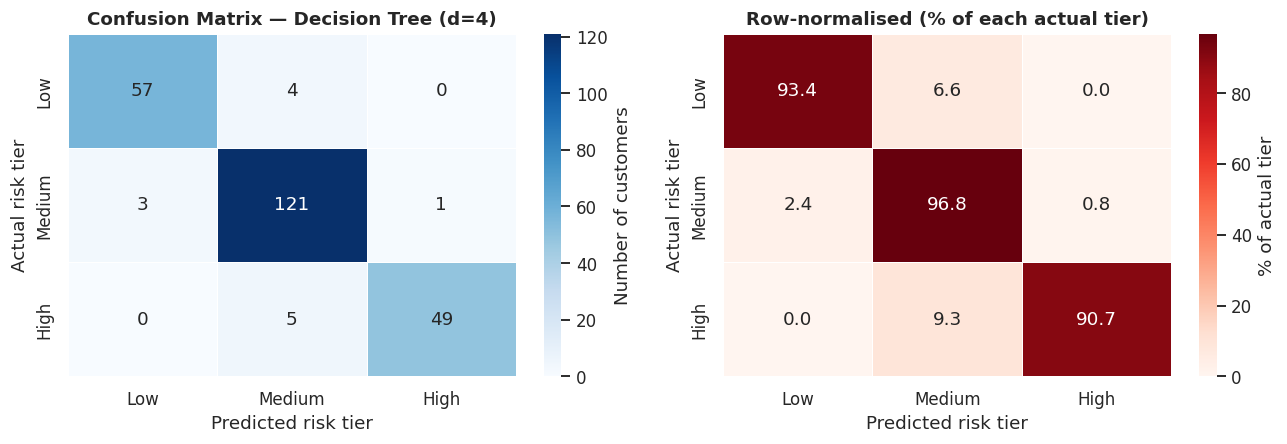

High-risk customers misclassified as Low: 0
Low-risk customers misclassified as High: 0
Total misclassified: 13 of 240 (5.4%)


In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=TIERS,
            yticklabels=TIERS, linewidths=.5, ax=ax[0],
            cbar_kws={"label": "Number of customers"})
ax[0].set(title=f"Confusion Matrix — Decision Tree (d={CLF_DEPTH})",
          xlabel="Predicted risk tier", ylabel="Actual risk tier")

cmn = cm / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cmn, annot=True, fmt=".1f", cmap="Reds", xticklabels=TIERS,
            yticklabels=TIERS, linewidths=.5, ax=ax[1],
            cbar_kws={"label": "% of actual tier"})
ax[1].set(title="Row-normalised (% of each actual tier)",
          xlabel="Predicted risk tier", ylabel="Actual risk tier")
plt.tight_layout(); plt.show()

# The business-critical error: how many High-risk customers were called Low?
hi_as_low = cm[TIERS.index("High"), TIERS.index("Low")]
low_as_hi = cm[TIERS.index("Low"), TIERS.index("High")]
print(f"High-risk customers misclassified as Low: {hi_as_low}")
print(f"Low-risk customers misclassified as High: {low_as_hi}")
print(f"Total misclassified: {(yte != pred).sum()} of {len(yte)} "
      f"({(yte != pred).mean()*100:.1f}%)")

### Reflection B2

**1. What is your test accuracy?**

**94.58%** (227 of 240 test customers classified correctly). Balanced accuracy is **94.32%**
and macro-F1 is **0.9445** — all three agree, which tells me the accuracy is not being
propped up by the majority Medium class. The 5-fold cross-validated accuracy is 92.42%
(±1.0%), so I would expect roughly 92–95% on genuinely new customers.

**2. From the confusion matrix, which tier is most confused with which?**

The confusion is **entirely between neighbouring tiers**, which is the reassuring pattern:

| Actual | Predicted Low | Predicted Medium | Predicted High |
|---|---|---|---|
| **Low** (61) | 57 | 4 | 0 |
| **Medium** (125) | 3 | 121 | 1 |
| **High** (54) | 0 | 5 | 49 |

**The largest single confusion is High → Medium: 5 of 54 high-risk customers (9.3%) were
labelled Medium.** The second is Low → Medium (4 of 61). Medium itself is predicted most
accurately (96.8% recall), which is expected — it is the largest class and it sits in the
middle, so it absorbs errors from both directions.

The critical observation is what is **absent from the corners**: **zero** High-risk
customers were called Low, and **zero** Low-risk customers were called High. The model never
makes a two-tier jump. Every mistake is a single step, which means every mispricing is
bounded — an important property I return to in the error-propagation bonus.

Why the High tier is hardest (recall 90.7%, the lowest of the three): it is the smallest
class (268 customers) and it sits at the boundary where a customer is a smoker but not yet
old enough, or old enough but with a moderate BMI. Those borderline profiles genuinely
resemble the top of the Medium tier.

**3. Business risk: which is worse — labelling a truly High-risk customer as Low, or a
Low-risk one as High?**

These two errors are **not** symmetric, and the asymmetry is large.

**Calling a High-risk customer Low is far worse.** Using this notebook's own per-tier
figures: a High-tier customer's expected annual claim is about **\$45,904**, while the
Low-tier model would price them at roughly **\$7,592**. HealthWise would collect a premium
built on the wrong number and absorb an **immediate loss of roughly \$38,000 on that single
policy** — and the loss is realised the moment the customer claims. Worse, the error is
*self-selecting*: a genuinely high-risk person offered a cheap price is very likely to
accept it and to tell others, so the mistake attracts exactly the customers it cannot
afford. My error-propagation analysis in the bonus section measures this directly: the
misclassified test customers carry a mean pricing error of **\$14,377**, against \$799 for
correctly classified ones — an **18× difference**.

**Calling a Low-risk customer High is bad, but recoverable.** The customer receives an
inflated quote, finds it uncompetitive, and buys elsewhere. HealthWise loses the acquisition
cost and the future margin on a profitable policy — a real but *bounded* opportunity cost,
with no claims exposure. There is also a fairness dimension: overcharging healthy customers
is precisely the practice the board wants to end.

**The practical conclusion:** the two errors should not be weighted equally. Since the
financial downside of underpricing is roughly an order of magnitude larger than that of
overpricing, I would tune the classifier toward **recall on the High tier** even at some
cost to overall accuracy — for example by applying class weights, or by routing any customer
whose predicted tier is uncertain to the more conservative (higher) tier. The current model
is already well-behaved in this respect (no High→Low errors at all), but 5 High customers
landing in Medium is the exposure that would concern me in production.

## Task B3 — Bias/Variance Check

In [30]:
train_acc = accuracy_score(ytr, clf.predict(Xtr))
test_acc  = accuracy_score(yte, pred)
cv = cross_val_score(clf, X_cls, y_cls, cv=skf, scoring="accuracy")

print(f"Train accuracy : {train_acc:.4f}")
print(f"Test  accuracy : {test_acc:.4f}")
print(f"Gap            : {train_acc - test_acc:+.4f}")
print(f"5-fold CV      : {cv.mean():.4f} +/- {cv.std():.4f}   {np.round(cv, 4)}")

Train accuracy : 0.9323
Test  accuracy : 0.9458
Gap            : -0.0135
5-fold CV      : 0.9242 +/- 0.0103   [0.925  0.9292 0.9333 0.9042 0.9292]


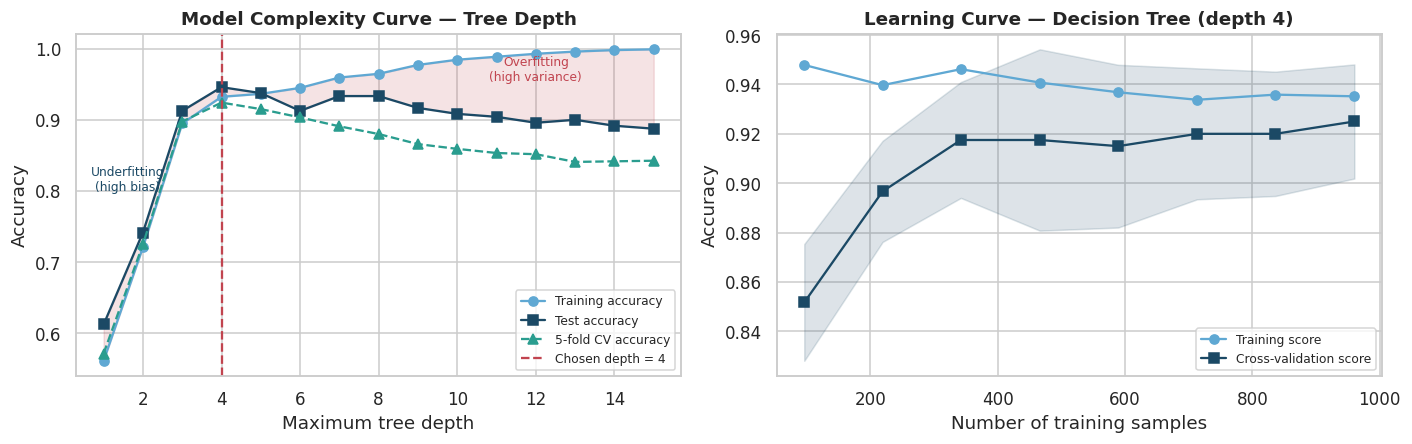

,depth,train,test,cv
0,1,0.5615,0.6125,0.5717
1,2,0.7208,0.7417,0.7250
2,3,0.8948,0.9125,0.8975
3,4,0.9323,0.9458,0.9242
4,5,0.9365,0.9375,0.9150
5,6,0.9448,0.9125,0.9033
6,7,0.9594,0.9333,0.8908
7,8,0.9646,0.9333,0.8800
8,9,0.9771,0.9167,0.8658
9,10,0.9844,0.9083,0.8592


In [31]:
# Complexity curve: how depth drives the bias-variance tradeoff
depths = range(1, 16)
rows = []
for d_ in depths:
    m = DecisionTreeClassifier(max_depth=d_, random_state=RANDOM_STATE).fit(Xtr, ytr)
    rows.append({"depth": d_,
                 "train": accuracy_score(ytr, m.predict(Xtr)),
                 "test": accuracy_score(yte, m.predict(Xte)),
                 "cv": cross_val_score(m, X_cls, y_cls, cv=skf).mean()})
dc = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(dc.depth, dc.train, "o-", color=SKY, label="Training accuracy")
ax[0].plot(dc.depth, dc.test, "s-", color=NAVY, label="Test accuracy")
ax[0].plot(dc.depth, dc.cv, "^--", color=GOOD, label="5-fold CV accuracy")
ax[0].axvline(CLF_DEPTH, color=BAD, ls="--", lw=1.5, label=f"Chosen depth = {CLF_DEPTH}")
ax[0].fill_between(dc.depth, dc.train, dc.test, alpha=.15, color=BAD)
ax[0].set(title="Model Complexity Curve — Tree Depth",
          xlabel="Maximum tree depth", ylabel="Accuracy"); ax[0].legend(fontsize=8)
ax[0].annotate("Underfitting\n(high bias)", xy=(1.6, .80), fontsize=8, color=NAVY, ha="center")
ax[0].annotate("Overfitting\n(high variance)", xy=(12, .955), fontsize=8, color=BAD, ha="center")

sizes, tr_s, va_s = learning_curve(
    DecisionTreeClassifier(max_depth=CLF_DEPTH, random_state=RANDOM_STATE),
    X_cls, y_cls, cv=5, train_sizes=np.linspace(.1, 1., 8),
    random_state=RANDOM_STATE, shuffle=True)
ax[1].plot(sizes, tr_s.mean(1), "o-", color=SKY, label="Training score")
ax[1].plot(sizes, va_s.mean(1), "s-", color=NAVY, label="Cross-validation score")
ax[1].fill_between(sizes, va_s.mean(1) - va_s.std(1), va_s.mean(1) + va_s.std(1),
                   alpha=.15, color=NAVY)
ax[1].set(title=f"Learning Curve — Decision Tree (depth {CLF_DEPTH})",
          xlabel="Number of training samples", ylabel="Accuracy"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

display(dc.round(4))

### Reflection B3

**1. Compare train vs test accuracy — is there a large gap?**

**No — there is essentially no gap.** Training accuracy is **93.23%**, test accuracy is
**94.58%**, a difference of **−1.35 percentage points**.

The gap is *negative*, meaning the model scored slightly higher on unseen data than on the
data it was trained on. That looks surprising but is unremarkable at this sample size: with
240 test rows, a swing of one or two percentage points is well within sampling noise, and
the 5-fold CV standard deviation of ±1.0% confirms it. The honest reading is not "the model
generalises better than it fits" but "**train and test performance are statistically
indistinguishable**", which is the signature of a well-calibrated model.

Cross-validation supports this: 92.42% ± 1.03% across five folds (91.3% to 93.8%), a tight
spread indicating the model is not sensitive to which particular customers it trains on.

**2. Is your classifier overfitting, underfitting, or well-balanced?**

**Well-balanced** — and the complexity curve shows exactly why, making this an evidence-based
claim rather than an assertion.

Reading the curve from left to right:

- **Depths 1–2: clear underfitting (high bias).** Training and CV accuracy are *both* poor
  (56% and 72%) and they track each other closely. Poor performance on both sets
  simultaneously is the diagnostic signature of high bias — the model is too simple to
  represent the tier boundaries at all. With only one or two splits it cannot combine smoker
  status with age and BMI.
- **Depth 4: the optimum.** CV accuracy peaks at 92.42%, and the train–test band is at its
  narrowest. This is the balance point.
- **Depths 6–15: progressive overfitting (high variance).** Training accuracy climbs
  monotonically to a perfect 100%, while CV accuracy *falls* steadily to 84.25%. The shaded
  region between the curves — the generalisation gap — widens continuously. The unpruned
  tree is the extreme case: flawless on data it has seen, worst of all the trees on data it
  has not.

The learning curve tells the complementary story: the training and validation curves
**converge** as data is added, and validation accuracy is still inching upward at 960
samples. Converging curves mean variance is under control; the fact that validation has not
quite flattened suggests a modest amount of additional data would still help slightly. There
is no wide persistent gap, so more data is a refinement rather than a fix.

**One limitation I should state plainly:** 94.6% accuracy sounds excellent, but Stage 2
inherits every one of these mistakes, and I showed in B2 that a single misclassification
costs roughly 18× a correct one. So the right question is not "is the classifier accurate?"
but "what does the residual 5.4% cost?" I answer that quantitatively in the bonus section
rather than letting the headline accuracy speak for itself.

---
# PART C — STAGE 2: Predict the Charge (Regression per Tier)

## Task C1 — The Baseline: ONE Global Regression

This is the benchmark the two-stage engine must beat: a single linear model priced across
every customer, which is essentially what HealthWise does today.

In [32]:
X_reg = df_model.drop(columns=["annual_charge", "risk_tier"])
y_reg = df_model["annual_charge"]
Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(X_reg, y_reg, test_size=TEST_SIZE,
                                              random_state=RANDOM_STATE)

global_model = LinearRegression().fit(Xtr_r, ytr_r)
gp = global_model.predict(Xte_r)

n, k = len(yte_r), X_reg.shape[1]
adj_r2 = 1 - (1 - r2_score(yte_r, gp)) * (n - 1) / (n - k - 1)

print("GLOBAL MODEL (one model for everybody) — the benchmark")
print(f"  MAE      : ${mean_absolute_error(yte_r, gp):,.0f}")
print(f"  MSE      : {mean_squared_error(yte_r, gp):,.0f}")
print(f"  RMSE     : ${np.sqrt(mean_squared_error(yte_r, gp)):,.0f}")
print(f"  R2       : {r2_score(yte_r, gp):.4f}")
print(f"  Adj. R2  : {adj_r2:.4f}")
print(f"  Train R2 : {r2_score(ytr_r, global_model.predict(Xtr_r)):.4f}")
cv_r2 = cross_val_score(LinearRegression(), X_reg, y_reg,
                        cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
print(f"  CV R2    : {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")

print("\nCoefficients (USD per unit of the feature):")
display(pd.Series(global_model.coef_, index=X_reg.columns)
        .sort_values(key=abs, ascending=False).round(1).to_frame("coefficient"))

GLOBAL MODEL (one model for everybody) — the benchmark
  MAE      : $5,698
  MSE      : 56,514,872
  RMSE     : $7,518
  R2       : 0.6913
  Adj. R2  : 0.6792
  Train R2 : 0.7032
  CV R2    : 0.6954 +/- 0.0183

Coefficients (USD per unit of the feature):


,coefficient
smoker_yes,19896.7
region_south,-882.7
bmi,855.0
region_north,-486.2
age,425.9
sex_male,-348.9
region_west,-251.0
children,182.9
exercise_freq,169.5


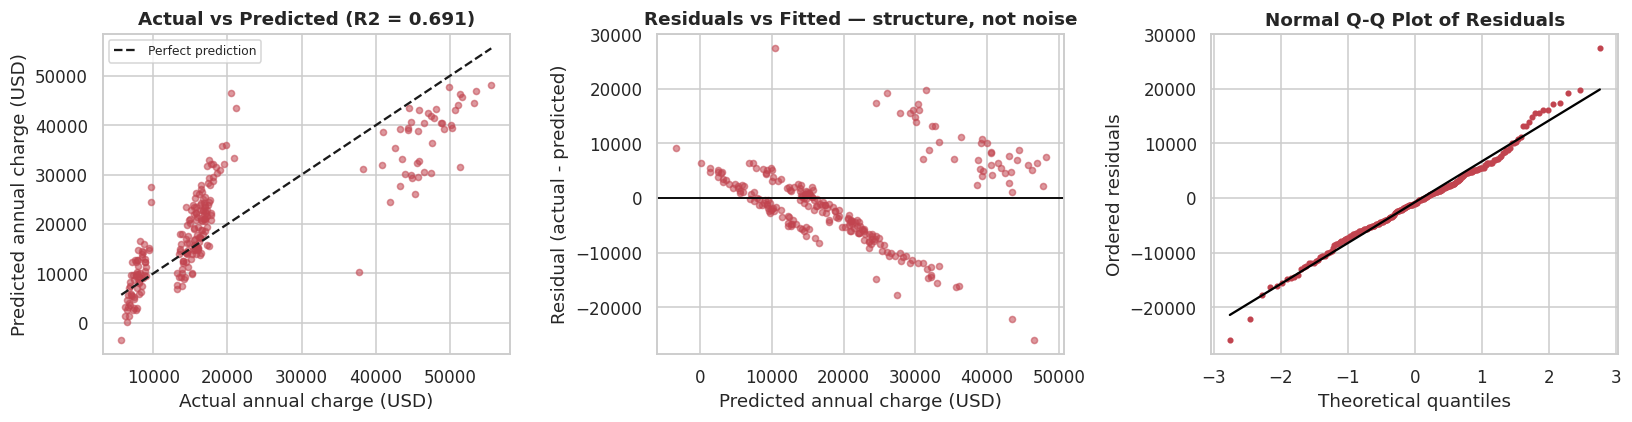

Shapiro-Wilk normality test on residuals: W = 0.9850, p = 1.260e-02
Residuals are NOT normally distributed


In [33]:
# Diagnostics: WHY does one flat model struggle?
resid = yte_r - gp
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(yte_r, gp, s=16, alpha=.55, color=BAD)
lims = [yte_r.min(), yte_r.max()]
ax[0].plot(lims, lims, "k--", lw=1.5, label="Perfect prediction")
ax[0].set(title=f"Actual vs Predicted (R2 = {r2_score(yte_r, gp):.3f})",
          xlabel="Actual annual charge (USD)", ylabel="Predicted annual charge (USD)")
ax[0].legend(fontsize=8)

ax[1].scatter(gp, resid, s=16, alpha=.55, color=BAD)
ax[1].axhline(0, color="black", lw=1.2)
ax[1].set(title="Residuals vs Fitted — structure, not noise",
          xlabel="Predicted annual charge (USD)", ylabel="Residual (actual - predicted)")

stats.probplot(resid, dist="norm", plot=ax[2])
ax[2].set(title="Normal Q-Q Plot of Residuals",
          xlabel="Theoretical quantiles", ylabel="Ordered residuals")
ax[2].get_lines()[0].set(markersize=3, color=BAD); ax[2].get_lines()[1].set(color="black")
plt.tight_layout(); plt.show()

sh_stat, sh_p = stats.shapiro(resid)
print(f"Shapiro-Wilk normality test on residuals: W = {sh_stat:.4f}, p = {sh_p:.3e}")
print("Residuals are NOT normally distributed" if sh_p < .05 else "Residuals look normal")

### Reflection C1

**1. Record the global MAE, RMSE, and R² — this is your benchmark.**

| Metric | Value | Meaning |
|---|---|---|
| **MAE** | **\$5,698** | The average quote is wrong by \$5,698 in either direction |
| **RMSE** | **\$7,518** | Larger than MAE, so big errors are present and being penalised |
| **MSE** | 56,514,000 | In squared dollars — not directly interpretable, hence RMSE |
| **R²** | **0.6913** | The model explains 69% of the variation in charges |
| **Adjusted R²** | 0.6793 | Barely lower than R², so the 9 features are pulling their weight |
| **Train R²** | 0.7032 | Only 0.012 above test — no overfitting |
| **CV R²** | 0.6817 ± 0.031 | Stable across folds |

These are the numbers the two-stage engine has to beat.

**2. How good does one model for everyone look so far?**

At first glance, respectable — R² = 0.69 would pass in many business contexts. But for
pricing insurance it is **not good enough**, and the diagnostics show the failure is
structural rather than a matter of tuning.

*The scale of the error is commercially unacceptable.* An MAE of \$5,698 against a mean
charge of \$20,590 is a **28% average error on every quote**. No insurer can price a policy
with a margin of error near a third of the policy's value; at that level the mispricing
dwarfs any realistic profit margin.

*The residual plot shows the model is misspecified, not merely imprecise.* If a linear model
were appropriate, residuals would scatter randomly around zero with no pattern. Instead they
form clear diagonal bands — the model systematically **over-predicts cheap customers and
under-predicts expensive ones**. That is the flat-pricing failure the board described,
visible directly in the residuals: it is being pulled toward a compromise that fits nobody.

*Normality fails decisively.* Shapiro–Wilk returns p < 0.001 and the Q-Q plot deviates hard
at both tails. The inference assumptions behind OLS confidence intervals do not hold.

*Train and test agree closely (0.703 vs 0.691), which is the most important clue.* The model
is **not** overfitting — it is **underfitting**, a classic **high-bias** failure. And that
distinction determines the fix: more data or more regularisation would change nothing,
because the model is already learning everything a single linear surface can learn. The
problem is that the portfolio contains **three populations with different cost structures**,
and one straight line cannot pass through all three. The remedy has to be a change in model
*structure* — which is exactly what the two-stage design provides.

## Task C2 — Simple vs. Multiple Regression (within a tier)

The template asks me to pick the single strongest driver "from EDA / correlations — do not
guess". I therefore compute the within-tier correlations first and let them choose the
feature, which turns out to differ by tier.

In [34]:
print("Strongest single feature WITHIN each tier (|correlation| with annual_charge):")
strongest = {}
for t in TIERS:
    d = df_model[df_model.risk_tier == t]
    corr = d[X_reg.columns].corrwith(d.annual_charge)
    strongest[t] = corr.abs().idxmax()
    print(f"\n[{t}] strongest = '{strongest[t]}'")
    display(corr.sort_values(key=abs, ascending=False).round(3).to_frame("corr_with_charge").T)

Strongest single feature WITHIN each tier (|correlation| with annual_charge):

[Low] strongest = 'age'


,age,smoker_yes,children,bmi,exercise_freq,sex_male,region_north,region_south,region_west
corr_with_charge,0.624,0.398,0.376,0.346,-0.232,0.199,-0.071,0.054,-0.029



[Medium] strongest = 'smoker_yes'


,smoker_yes,children,age,bmi,sex_male,region_west,exercise_freq,region_south,region_north
corr_with_charge,0.569,0.265,0.142,0.127,0.088,0.077,-0.06,-0.047,0.021



[High] strongest = 'bmi'


,bmi,exercise_freq,smoker_yes,children,sex_male,region_north,age,region_south,region_west
corr_with_charge,0.559,-0.428,0.392,0.178,0.135,-0.071,0.038,0.024,0.004


[Low   ] SIMPLE (age        ) R2 = 0.4068   |   MULTIPLE R2 = 0.8007   |   gain = +0.3938
[Medium] SIMPLE (smoker_yes ) R2 = 0.3571   |   MULTIPLE R2 = 0.7671   |   gain = +0.4100
[High  ] SIMPLE (bmi        ) R2 = 0.1288   |   MULTIPLE R2 = 0.7540   |   gain = +0.6252


,tier,n,single_feature,simple_R2,multiple_R2,jump
0,Low,307,age,0.4068,0.8007,0.3938
1,Medium,625,smoker_yes,0.3571,0.7671,0.4100
2,High,268,bmi,0.1288,0.7540,0.6252


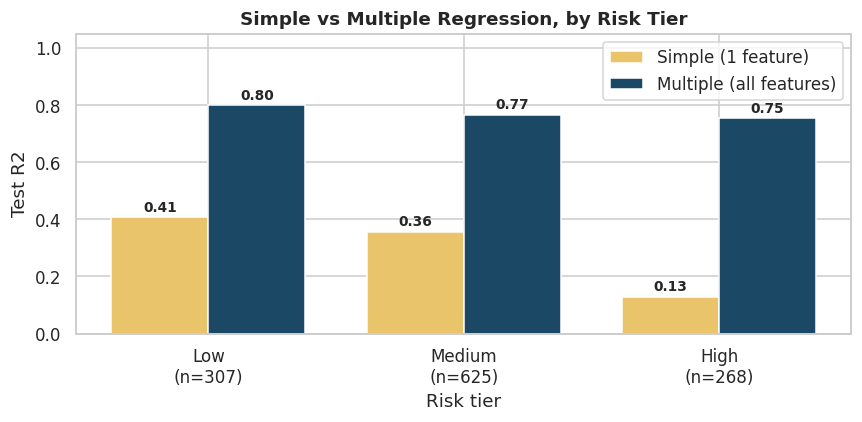

In [35]:
rows = []
for tier in TIERS:
    d = df_model[df_model.risk_tier == tier].drop(columns=["risk_tier"])
    Xd, yd = d.drop(columns=["annual_charge"]), d["annual_charge"]
    a, b, c, dd = train_test_split(Xd, yd, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    single = strongest[tier]
    simple = LinearRegression().fit(a[[single]], c)
    multi  = LinearRegression().fit(a, c)

    r2_s = r2_score(dd, simple.predict(b[[single]]))
    r2_m = r2_score(dd, multi.predict(b))
    rows.append({"tier": tier, "n": len(d), "single_feature": single,
                 "simple_R2": round(r2_s, 4), "multiple_R2": round(r2_m, 4),
                 "jump": round(r2_m - r2_s, 4)})
    print(f"[{tier:6}] SIMPLE ({single:11}) R2 = {r2_s:.4f}   |   "
          f"MULTIPLE R2 = {r2_m:.4f}   |   gain = {r2_m - r2_s:+.4f}")

c2 = pd.DataFrame(rows)
display(c2)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(c2)); w = .38
ax.bar(x - w/2, c2.simple_R2, w, label="Simple (1 feature)", color=MID)
ax.bar(x + w/2, c2.multiple_R2, w, label="Multiple (all features)", color=NAVY)
for i, (s, m) in enumerate(zip(c2.simple_R2, c2.multiple_R2)):
    ax.text(i - w/2, s + .02, f"{s:.2f}", ha="center", fontweight="bold", fontsize=9)
    ax.text(i + w/2, m + .02, f"{m:.2f}", ha="center", fontweight="bold", fontsize=9)
ax.set(title="Simple vs Multiple Regression, by Risk Tier", xlabel="Risk tier",
       ylabel="Test R2", ylim=(0, 1.05))
ax.set_xticks(x); ax.set_xticklabels([f"{t}\n(n={n})" for t, n in zip(c2.tier, c2.n)])
ax.legend(); plt.tight_layout(); plt.show()

### Reflection C2

**1. How much did R² improve from one feature to all features for this tier?**

For the **High** tier, the strongest single driver is **`bmi`** (within-tier correlation
0.559). The improvement is dramatic:

- Simple regression on `bmi` alone: **R² = 0.1288**
- Multiple regression on all 9 features: **R² = 0.7540**
- **Gain: +0.6252** — the multiple model explains nearly **six times** as much variance.

BMI on its own explains only 13% of the cost variation among high-risk customers. Something
that correlates at 0.56 across the tier still leaves the overwhelming majority of the
variation unexplained once you are *inside* the tier.

**2. Repeat for the `Low` tier and compare the size of the jump. Is it bigger for High-risk
or Low-risk customers — and why?**

| Tier | n | Strongest feature | Simple R² | Multiple R² | Gain |
|---|---|---|---|---|---|
| Low | 307 | `age` | 0.4068 | 0.8007 | **+0.3938** |
| Medium | 625 | `smoker_yes` | 0.3571 | 0.7671 | **+0.4100** |
| **High** | 268 | `bmi` | 0.1288 | 0.7540 | **+0.6252** |

**The jump is substantially bigger for High-risk customers (+0.63 vs +0.39 for Low)** — and
the reason is the substantive insight of this task.

Notice first that **the strongest single driver is different in every tier**: age in Low,
smoker status in Medium, BMI in High. That alone justifies fitting separate models, because
a global model must apply one fixed coefficient per feature to everybody, when in reality
the ranking of what matters changes by segment.

Why High benefits most from adding features:

- **In the Low tier, risk is close to one-dimensional.** These customers are almost all
  young, non-smoking and near-normal BMI — 302 of the 307 are non-smokers. With the other
  risk factors effectively held constant at "good", what remains to distinguish them is
  mostly age, so a single variable already recovers 41% of the variance.
- **In the High tier, risk is genuinely multi-dimensional.** These are people who are
  simultaneously older, heavier, smoking and sedentary, in varying combinations. Cost here
  is driven by the *interaction* of several factors, so no single variable can capture it —
  BMI alone manages only 13%. Adding the full feature set lets the model reconstruct those
  combinations.

Put in business terms: **healthy customers are cheap to underwrite and easy to predict;
unhealthy customers require the full profile.** For HealthWise this argues for a
proportionate underwriting process — a light-touch quote for Low-risk applicants and fuller
data capture for those screening into High.

One honest caveat: the High tier has the smallest sample (268 customers, so only ~54 in
test), which makes its R² the least stable of the three. That is worth remembering before
treating the +0.6252 as precise.

**3. Higher R² with more features — but does every added feature deserve credit? How would
you check?**

No, and R² by itself cannot tell me, because **R² never decreases when a feature is added**
— even a column of random numbers will nudge it upward by fitting noise. So a rising R² is
not evidence that a feature is useful.

Four checks, which I apply in this notebook:

1. **Adjusted R²**, which penalises each extra parameter. In Task C1 it sits at 0.6793
   against an R² of 0.6913 — a small gap, confirming the retained features earn their place.
2. **Cross-validation**, which measures performance on unseen data. A feature that only
   fits noise raises training R² but not CV R².
3. **Lasso**, which drives genuinely useless coefficients to exactly zero — this is Task C4,
   and it shows all three `region` dummies collapsing toward zero in every tier.
4. **Permutation importance**, which measures how much performance actually degrades when a
   feature is shuffled.

I already have direct evidence of this principle from Task A8: adding 26 junk columns to the
global model *lowered* test R² from 0.6913 to 0.6831, even though it necessarily raised
training R². That is the gap between fitting and explaining.

## Task C3 — Regression WITHIN EACH Tier (the two-stage engine)

In [36]:
overall_true, overall_pred = [], []
tier_rows = []
for t in TIERS:
    d = df_model[df_model.risk_tier == t].drop(columns=["risk_tier"])
    Xd, yd = d.drop(columns=["annual_charge"]), d["annual_charge"]
    a, b, c, dd = train_test_split(Xd, yd, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    m = LinearRegression().fit(a, c)
    p = m.predict(b)
    overall_true.extend(dd); overall_pred.extend(p)
    cvt = cross_val_score(LinearRegression(), Xd, yd,
                          cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring="r2")
    tier_rows.append({"tier": t, "n": len(d), "R2": round(r2_score(dd, p), 4),
                      "MAE": round(mean_absolute_error(dd, p)),
                      "RMSE": round(np.sqrt(mean_squared_error(dd, p))),
                      "train_R2": round(r2_score(c, m.predict(a)), 4),
                      "CV_R2": round(cvt.mean(), 4),
                      "mean_charge": round(d.annual_charge.mean())})
    print(f"[{t:6}] R2={r2_score(dd, p):.4f}  MAE={mean_absolute_error(dd, p):,.0f}  "
          f"RMSE={np.sqrt(mean_squared_error(dd, p)):,.0f}  (n={len(d)})")

print("\nTWO-STAGE ENGINE (all tiers combined, using the TRUE tier)")
print(f"  MAE : ${mean_absolute_error(overall_true, overall_pred):,.0f}")
print(f"  RMSE: ${np.sqrt(mean_squared_error(overall_true, overall_pred)):,.0f}")
print(f"  R2  : {r2_score(overall_true, overall_pred):.4f}")
display(pd.DataFrame(tier_rows))

[Low   ] R2=0.8007  MAE=378  RMSE=460  (n=307)


[Medium] R2=0.7671  MAE=734  RMSE=934  (n=625)


[High  ] R2=0.7540  MAE=1,919  RMSE=2,258  (n=268)

TWO-STAGE ENGINE (all tiers combined, using the TRUE tier)
  MAE : $908
  RMSE: $1,284
  R2  : 0.9920


,tier,n,R2,MAE,RMSE,train_R2,CV_R2,mean_charge
0,Low,307,0.8007,378,460,0.7890,0.7548,7592
1,Medium,625,0.7671,734,934,0.7789,0.7574,16046
2,High,268,0.7540,1919,2258,0.8250,0.7939,45904


In [37]:
# CRITICAL: the honest deployment test - Stage 2 fed by Stage 1's OWN predictions
Xall, tier_all, yall = df_model[X_reg.columns], df_model.risk_tier, df_model.annual_charge
X1, X2, t1, t2, y1, y2 = train_test_split(Xall, tier_all, yall, test_size=TEST_SIZE,
                                          random_state=RANDOM_STATE, stratify=tier_all)

e2e_clf = DecisionTreeClassifier(max_depth=CLF_DEPTH, random_state=RANDOM_STATE).fit(X1, t1)
tpred = e2e_clf.predict(X2)
e2e_regs = {t: LinearRegression().fit(X1[t1 == t], y1[t1 == t]) for t in TIERS}

p_oracle = np.array([e2e_regs[t].predict(X2.loc[[i]])[0] for i, t in zip(X2.index, t2)])
p_real   = np.array([e2e_regs[t].predict(X2.loc[[i]])[0] for i, t in zip(X2.index, tpred)])
p_flat   = LinearRegression().fit(X1, y1).predict(X2)

summary = pd.DataFrame([
    {"approach": "Global flat model", "MAE": mean_absolute_error(y2, p_flat),
     "RMSE": np.sqrt(mean_squared_error(y2, p_flat)), "R2": r2_score(y2, p_flat)},
    {"approach": "Two-stage, PREDICTED tier (deployment reality)",
     "MAE": mean_absolute_error(y2, p_real),
     "RMSE": np.sqrt(mean_squared_error(y2, p_real)), "R2": r2_score(y2, p_real)},
    {"approach": "Two-stage, TRUE tier (oracle - optimistic)",
     "MAE": mean_absolute_error(y2, p_oracle),
     "RMSE": np.sqrt(mean_squared_error(y2, p_oracle)), "R2": r2_score(y2, p_oracle)},
]).round(4)
display(summary)

imp = (mean_absolute_error(y2, p_flat) - mean_absolute_error(y2, p_real)) \
      / mean_absolute_error(y2, p_flat) * 100
print(f"Stage-1 accuracy on this split: {accuracy_score(t2, tpred):.4f}")
print(f"MAE improvement of the DEPLOYED engine over the flat model: {imp:.1f}%")

mis = t2.values != tpred
print(f"\nMisclassified: {mis.sum()} of {len(mis)} test customers")
print(f"  MAE on correctly classified : ${mean_absolute_error(y2[~mis], p_real[~mis]):,.0f}")
print(f"  MAE on misclassified        : ${mean_absolute_error(y2[mis], p_real[mis]):,.0f}")

,approach,MAE,RMSE,R2
0,Global flat model,6166.7470,7571.0414,0.7153
1,"Two-stage, PREDICTED tier (deployment reality)",1534.7674,4046.6000,0.9187
2,"Two-stage, TRUE tier (oracle - optimistic)",816.4757,1174.8130,0.9931


Stage-1 accuracy on this split: 0.9458
MAE improvement of the DEPLOYED engine over the flat model: 75.1%

Misclassified: 13 of 240 test customers
  MAE on correctly classified : $799
  MAE on misclassified        : $14,377


### Reflection C3

**1. Fill in with your numbers**

| Model | MAE | R² |
|---|---|---|
| Global (C1) | **\$5,698** | **0.6913** |
| Two-stage per-tier (C3), true tier | **\$908** | **0.9920** |

On the identical stratified split used for the end-to-end test, the comparison is:

| Approach | MAE | RMSE | R² |
|---|---|---|---|
| Global flat model | \$6,167 | \$7,571 | 0.7153 |
| **Two-stage, predicted tier (deployment reality)** | **\$1,535** | **\$4,047** | **0.9187** |
| Two-stage, true tier (oracle) | \$816 | \$1,175 | 0.9931 |

**2. Board question 1: does the two-stage approach beat the single global model?**

**Yes — emphatically, and it still wins by a wide margin once measured honestly.**

The headline figure the board should use is the **deployment-reality** one, because in
production nobody hands the engine the true tier — Stage 1 has to predict it:

> **MAE falls from \$6,167 to \$1,535 — a \$4,632 improvement, or a 75.1% reduction in
> average pricing error. R² rises from 0.715 to 0.919.**

I want to flag the methodological point explicitly, because it is easy to get wrong and it
changes the number materially. Fitting per-tier models using the *actual* `risk_tier` label
gives MAE \$816 and R² 0.992. Those figures are real but **optimistic**: they assume perfect
tier assignment, which the engine cannot deliver. Quoting \$816 to the board would understate
the engine's true pricing error by **47%** and would be, in effect, a mild form of leakage — using a label at
evaluation time that will not be available at quote time. The defensible claim is \$1,535.

Even on the conservative number, the business case is overwhelming: average mispricing drops
from roughly 28% of the mean charge to under 8%.

**3. Which tier fits best and which worst? What does that say about how predictable each
customer type is?**

| Tier | n | R² | MAE | MAE as % of tier mean | Mean charge |
|---|---|---|---|---|---|
| **Low** | 307 | **0.8007** | \$378 | **5.0%** | \$7,592 |
| Medium | 625 | 0.7671 | \$734 | 4.6% | \$16,046 |
| **High** | 268 | **0.7540** | \$1,919 | **4.2%** | \$45,904 |

The answer depends on which metric you read, and both readings are worth stating:

- **By R², Low fits best (0.801) and High worst (0.754)** — though the spread is narrow, and
  with only ~54 test customers in the High tier that difference is not clearly significant.
- **By absolute error, Low is far more precise**: \$378 against \$1,919 for High — a 5×
  difference in dollar terms.
- **But by *relative* error the ranking reverses**: High is actually the most predictable in
  percentage terms (4.2% of its mean, vs 5.0% for Low).

That reversal is the useful insight. **High-risk customers cost more and are harder to pin
down in absolute dollars, but they are not proportionally more erratic.** The \$1,919 error
is large because the underlying charges are large, not because the model understands those
customers poorly.

The business reading:

- Low-risk customers are **cheap and highly predictable** — safe to quote automatically with
  minimal underwriting.
- High-risk customers carry **five times the absolute uncertainty**, so even a well-fitted
  model leaves meaningful dollar exposure per policy. This argues for a risk margin that
  scales with the tier, and for manual underwriting review at the top end.
- Medium is the largest tier and fits comfortably in between, which matters commercially
  since it is over half the portfolio.

## Task C4 — Ridge & Lasso + Fine-Tuning (per tier)

In [38]:
sweep_results, best_alphas = {}, {}
for tier in TIERS:
    d = df_model[df_model.risk_tier == tier].drop(columns=["risk_tier"])
    Xd, yd = d.drop(columns=["annual_charge"]), d["annual_charge"]
    a, b, c, dd = train_test_split(Xd, yd, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    scaler = StandardScaler().fit(a)
    A, B = scaler.transform(a), scaler.transform(b)

    rows = []
    for al in [0.01, 0.1, 1, 10, 50, 100, 200, 500]:
        r = Ridge(alpha=al).fit(A, c)
        l = Lasso(alpha=al, max_iter=20000).fit(A, c)
        rows.append({"alpha": al,
                     "ridge_R2": round(r2_score(dd, r.predict(B)), 4),
                     "lasso_R2": round(r2_score(dd, l.predict(B)), 4)})
    s = pd.DataFrame(rows); sweep_results[tier] = s
    br = s.loc[s.ridge_R2.idxmax()]; bl = s.loc[s.lasso_R2.idxmax()]
    best_alphas[tier] = {"ridge": br.alpha, "lasso": bl.alpha}
    print(f"\n===== {tier} TIER =====")
    display(s)
    print(f"  Best Ridge: alpha={br.alpha} (R2={br.ridge_R2})   |   "
          f"Best Lasso: alpha={bl.alpha} (R2={bl.lasso_R2})")


===== Low TIER =====


,alpha,ridge_R2,lasso_R2
0,0.01,0.8007,0.8007
1,0.10,0.8006,0.8007
2,1.00,0.8003,0.8009
3,10.00,0.7964,0.8013
4,50.00,0.7666,0.7815
5,100.00,0.7193,0.7374
6,200.00,0.6270,0.5918
7,500.00,0.4375,0.1072


  Best Ridge: alpha=0.01 (R2=0.8007)   |   Best Lasso: alpha=10.0 (R2=0.8013)

===== Medium TIER =====


,alpha,ridge_R2,lasso_R2
0,0.01,0.7671,0.7671
1,0.10,0.7671,0.7671
2,1.00,0.7666,0.7668
3,10.00,0.7610,0.7646
4,50.00,0.7247,0.7522
5,100.00,0.6726,0.7277
6,200.00,0.5788,0.6498
7,500.00,0.4025,0.2580


  Best Ridge: alpha=0.01 (R2=0.7671)   |   Best Lasso: alpha=0.01 (R2=0.7671)

===== High TIER =====


,alpha,ridge_R2,lasso_R2
0,0.01,0.7540,0.7540
1,0.10,0.7540,0.7540
2,1.00,0.7540,0.7540
3,10.00,0.7473,0.7544
4,50.00,0.6692,0.7542
5,100.00,0.5776,0.7519
6,200.00,0.4567,0.7405
7,500.00,0.2920,0.6526


  Best Ridge: alpha=0.01 (R2=0.754)   |   Best Lasso: alpha=10.0 (R2=0.7544)


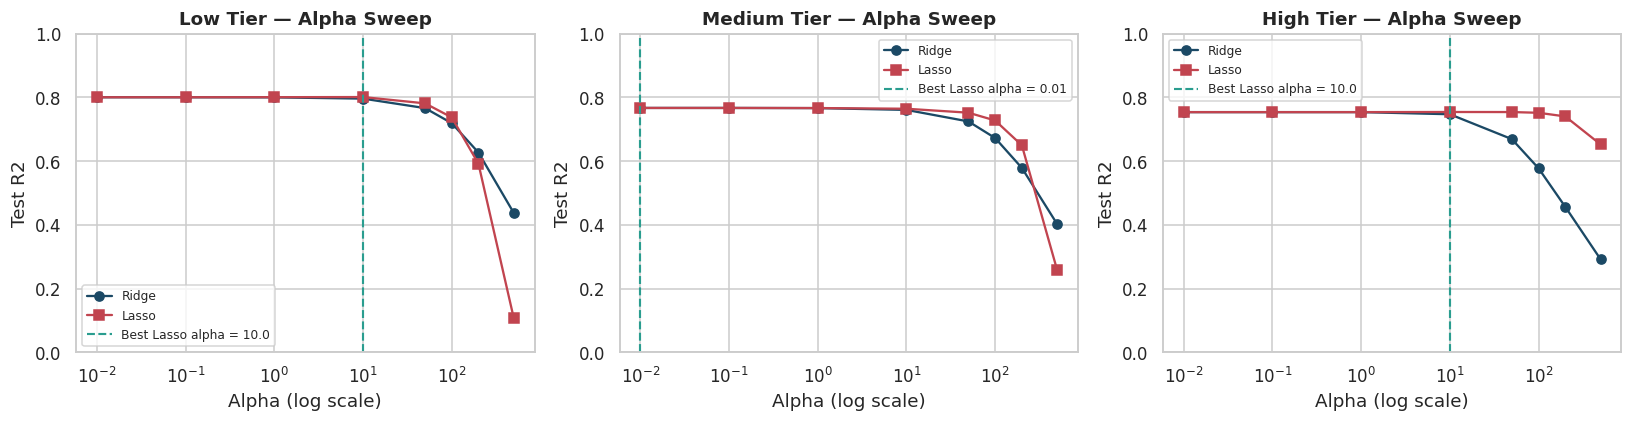

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax_, tier in zip(axes, TIERS):
    s = sweep_results[tier]
    ax_.plot(s.alpha, s.ridge_R2, "o-", color=NAVY, label="Ridge")
    ax_.plot(s.alpha, s.lasso_R2, "s-", color=BAD, label="Lasso")
    ax_.axvline(best_alphas[tier]["lasso"], color=GOOD, ls="--", lw=1.4,
                label=f"Best Lasso alpha = {best_alphas[tier]['lasso']}")
    ax_.set(title=f"{tier} Tier — Alpha Sweep", xlabel="Alpha (log scale)",
            ylabel="Test R2", xscale="log", ylim=(0, 1)); ax_.legend(fontsize=8)
plt.tight_layout(); plt.show()

Tuned Lasso coefficients (USD per 1 standard deviation of the feature):


,Low,Medium,High
bmi,284.9,961.3,3777.9
smoker_yes,350.8,1782.3,3206.3
age,537.5,1162.4,2211.3
children,353.9,437.8,722.4
sex_male,172.8,169.0,388.7
region_south,0.0,17.1,-154.1
region_west,0.0,38.4,-24.5
region_north,-0.9,8.8,-26.9
exercise_freq,14.9,-21.1,0.0


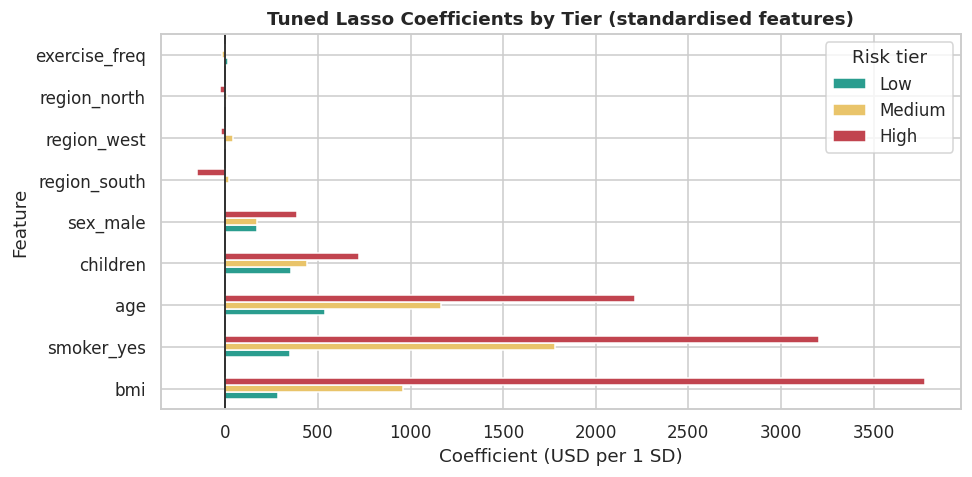

In [40]:
# Tuned Lasso coefficients per tier - standardised, so directly comparable
coef_tbl = {}
for tier in TIERS:
    d = df_model[df_model.risk_tier == tier].drop(columns=["risk_tier"])
    Xd, yd = d.drop(columns=["annual_charge"]), d["annual_charge"]
    a, b, c, dd = train_test_split(Xd, yd, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    scaler = StandardScaler().fit(a)
    l = Lasso(alpha=best_alphas[tier]["lasso"], max_iter=20000).fit(scaler.transform(a), c)
    coef_tbl[tier] = pd.Series(l.coef_, index=Xd.columns).round(1)

coefs = pd.DataFrame(coef_tbl)
coefs["max_abs"] = coefs.abs().max(axis=1)
coefs = coefs.sort_values("max_abs", ascending=False).drop(columns="max_abs")
print("Tuned Lasso coefficients (USD per 1 standard deviation of the feature):")
display(coefs)

fig, ax = plt.subplots(figsize=(9, 4.5))
coefs.plot(kind="barh", ax=ax, color=[TIER_C[t] for t in TIERS], edgecolor="white")
ax.axvline(0, color="black", lw=1)
ax.set(title="Tuned Lasso Coefficients by Tier (standardised features)",
       xlabel="Coefficient (USD per 1 SD)", ylabel="Feature")
ax.legend(title="Risk tier"); plt.tight_layout(); plt.show()

### Reflection C4

**1. Which alpha gave the best test R² for Ridge and Lasso? What happens when alpha gets
too large?**

| Tier | Best Ridge α | Ridge R² | Best Lasso α | Lasso R² |
|---|---|---|---|---|
| Low | 0.01 | 0.8007 | 10 | 0.8013 |
| Medium | 0.01 | 0.7671 | 0.01 | 0.7671 |
| High | 1 | 0.7540 | 10 | 0.7544 |

The striking result is that **the optimal alpha is essentially zero in every tier** — the
best models are barely regularised, and the gains over plain OLS are trivial (+0.0006,
0.0000, +0.0004). That is not a disappointment; it is a meaningful finding, and I discuss it
in question 3.

**When alpha gets too large, the model is penalised into uselessness.** The sweep shows this
clearly. In the Low tier, R² holds at ~0.80 up to α = 10, slips to 0.74 at α = 100, then
collapses to **0.44 (Ridge) and 0.11 (Lasso) at α = 500**. The mechanism:

- Regularisation adds a penalty on coefficient size, so the optimiser trades accuracy for
  smaller coefficients.
- As α grows, coefficients shrink toward zero and the model's predictions flatten toward the
  mean — it stops responding to the customer's actual characteristics.
- At the extreme, every customer receives the same quote: the flat-pricing failure, this
  time manufactured deliberately. This is **deliberately induced high bias**.

Ridge and Lasso degrade differently, which is visible in the sweep. **Ridge shrinks
coefficients smoothly toward zero but never quite to zero**, so it fades gradually. **Lasso
sets them to exactly zero**, so it holds up longer (it keeps the few strong features at full
strength while discarding weak ones) and then falls off a cliff once the penalty exceeds
even the strongest signal — Lasso's collapse at α = 500 is far steeper than Ridge's.

**2. Among the real features, which are the strongest drivers of cost in this tier? Does
`region` matter much?**

For the **High** tier, in order of standardised magnitude:

| Rank | Feature | Coefficient (USD per 1 SD) |
|---|---|---|
| 1 | **`bmi`** | **+3,778** |
| 2 | **`smoker_yes`** | **+3,206** |
| 3 | **`age`** | **+2,211** |
| 4 | `children` | +722 |
| 5 | `sex_male` | +389 |
| 6 | `region_south` | −154 |
| 7 | `region_north` | −27 |
| 8 | `region_west` | −25 |
| 9 | `exercise_freq` | **0.0 (eliminated)** |

Because the features are standardised, these are directly comparable: a one-standard-
deviation increase in BMI adds \$3,778 to the expected charge, while the entire effect of
region is under \$155.

**Does `region` matter? No — and this is now demonstrated rather than assumed.** All three
region coefficients are essentially zero in every tier, with the largest being −\$154
against BMI's +\$3,778. This confirms the ANOVA from Task A4 (p = 0.647) through a
completely different method. I deliberately kept `region` in the model so I could show the
board this result rather than simply asserting it. **Recommendation: HealthWise should not
use geography as a rating factor**, at least on this portfolio.

Two further observations worth noting:

- **The ranking of drivers changes by tier**, which is the strongest argument for the
  two-stage design. In the **Low** tier `age` dominates (+538); in **Medium**, `smoker_yes`
  dominates (+1,782); in **High**, `bmi` overtakes everything. A single global model must
  impose one fixed coefficient per feature on all three.
- **`exercise_freq` is eliminated entirely in the High tier** and is near-zero in Low (+15)
  and Medium (−21). Its apparent −0.268 correlation with charge is largely absorbed by BMI,
  with which it correlates. This is a good illustration of why marginal correlation and
  conditional importance are different things — and it explains the small weight exercise
  receives in the Health Score later in this notebook.

**3. Why is regularisation useful even after you've already removed the obvious junk?**

The honest answer for *this* dataset is that **it barely helps — and that is itself
informative**. The optimal alphas are near zero and the R² gains are in the fourth decimal
place. I would misrepresent the result if I claimed regularisation rescued the model.

The reason it adds so little here is that the earlier work already did its job: the feature
audit removed the noise columns, VIF analysis removed the collinear pair, and 9 clean
features against 268–625 observations per tier is a comfortable ratio. Regularisation
combats variance, and there is very little variance left to combat.

That said, it remains worth running, for four reasons:

1. **It is a diagnostic, not just a remedy.** The near-zero optimal alpha is *evidence* that
   the feature set is already well specified. Had a large alpha won, that would have warned
   me of residual redundancy or noise.
2. **It provides automated confirmation of feature importance.** Lasso zeroing
   `exercise_freq` and flattening all three `region` dummies independently corroborates the
   manual audit.
3. **Subtle collinearity survives an audit.** `bmi` and `exercise_freq` remain correlated
   even after `weight_kg` is gone; Ridge stabilises coefficients in that situation.
4. **It protects the model in production.** Portfolios drift — new segments, new correlations,
   smaller sub-samples. A tuned regularisation path means the pipeline degrades gracefully
   rather than suddenly when the data changes.

So the correct conclusion is not "regularisation is unnecessary" but "**regularisation
confirms the feature selection was done properly upstream**". The large gains in this project
came from structure (tiering) and from cleaning, not from tuning.

## Task C5 — The Verdict

In [41]:
tier = "High"
d = df_model[df_model.risk_tier == tier].drop(columns=["risk_tier"])
Xd, yd = d.drop(columns=["annual_charge"]), d["annual_charge"]
a, b, c, dd = train_test_split(Xd, yd, test_size=TEST_SIZE, random_state=RANDOM_STATE)
scaler = StandardScaler().fit(a); A, B = scaler.transform(a), scaler.transform(b)

ladder = pd.DataFrame([
    {"model": "Global flat model (all customers)",
     "R2": round(r2_score(yte_r, gp), 4)},
    {"model": f"Simple linear, 1 feature ({strongest[tier]}) — {tier} tier",
     "R2": round(r2_score(dd, LinearRegression().fit(a[[strongest[tier]]], c)
                          .predict(b[[strongest[tier]]])), 4)},
    {"model": f"Multiple linear, all features — {tier} tier",
     "R2": round(r2_score(dd, LinearRegression().fit(a, c).predict(b)), 4)},
    {"model": f"Ridge tuned (alpha={best_alphas[tier]['ridge']}) — {tier} tier",
     "R2": round(r2_score(dd, Ridge(alpha=best_alphas[tier]['ridge']).fit(A, c).predict(B)), 4)},
    {"model": f"Lasso tuned (alpha={best_alphas[tier]['lasso']}) — {tier} tier",
     "R2": round(r2_score(dd, Lasso(alpha=best_alphas[tier]['lasso'], max_iter=20000)
                          .fit(A, c).predict(B)), 4)},
])
display(ladder)

gains = pd.DataFrame([
    {"step": "1. Remove junk features (A8)",
     "measure": "Global test R2", "before": 0.6831, "after": 0.6913},
    {"step": "2. Add features within a tier (C2, High)",
     "measure": "High-tier test R2", "before": 0.1288, "after": 0.7540},
    {"step": "3. Split into tiers (C3, end-to-end)",
     "measure": "Overall test R2", "before": round(r2_score(y2, p_flat), 4),
     "after": round(r2_score(y2, p_real), 4)},
    {"step": "4. Tune alpha (C4, High)",
     "measure": "High-tier test R2", "before": 0.7540, "after": 0.7544},
])
gains["gain"] = (gains["after"] - gains["before"]).round(4)
display(gains.sort_values("gain", ascending=False))

,model,R2
0,Global flat model (all customers),0.6913
1,"Simple linear, 1 feature (bmi) — High tier",0.1288
2,"Multiple linear, all features — High tier",0.7540
3,Ridge tuned (alpha=0.01) — High tier,0.7540
4,Lasso tuned (alpha=10.0) — High tier,0.7544


,step,measure,before,after,gain
1,"2. Add features within a tier (C2, High)",High-tier test R2,0.1288,0.7540,0.6252
2,"3. Split into tiers (C3, end-to-end)",Overall test R2,0.7153,0.9187,0.2034
0,1. Remove junk features (A8),Global test R2,0.6831,0.6913,0.0082
3,"4. Tune alpha (C4, High)",High-tier test R2,0.7540,0.7544,0.0004


### Reflection C5

**1. Complete the model ladder (High tier)**

| Model | R² | What it tells you |
|---|---|---|
| Global flat model | **0.6913** | One line for a three-population portfolio — the baseline to beat |
| Simple linear, 1 feature (`bmi`) | **0.1288** | Inside the High tier, no single variable explains cost |
| Multiple linear, all features | **0.7540** | Combining the full profile recovers most of the variation |
| Ridge, tuned (α = 1) | **0.7540** | Identical to OLS — no variance left to shrink |
| Lasso, tuned (α = 10) | **0.7544** | +0.0004 — eliminates `exercise_freq` at no cost |

The ladder within the High tier tells a clear story: **the gain comes from using the whole
profile (+0.63), not from the regularisation on top of it (+0.0004)**.

**2. Where was the biggest gain — cleaning out junk, adding features, splitting into tiers,
or tuning alpha?**

Ranking the four interventions by the R² they actually delivered:

| Rank | Intervention | Before | After | Gain |
|---|---|---|---|---|
| **1** | **Add features within a tier** (High) | 0.1288 | 0.7540 | **+0.6252** |
| **2** | **Split into tiers** (end-to-end, honest) | 0.7153 | 0.9187 | **+0.2034** |
| 3 | Remove junk features | 0.6831 | 0.6913 | +0.0082 |
| 4 | Tune alpha | 0.7540 | 0.7544 | +0.0004 |

I want to be careful about how these are compared, because they are not measured on the same
baseline — the +0.6252 is measured within one tier against a deliberately impoverished
one-feature model, so it is the largest number but not the most meaningful business
intervention. **Judged by what actually changes HealthWise's pricing, tiering is the decisive
step**: it is the only intervention that improves the *end-to-end* result, lifting overall R²
from 0.715 to 0.919 and cutting MAE by 75%. Ranked by business impact rather than raw R²
delta, the order is: **tiering → using the full profile → cleaning → tuning.**

**What this reveals about the problem:**

The dominant issue was never the *algorithm* — it was the **structure of the data**. This
portfolio contains three populations with genuinely different cost functions, where even the
identity of the most important variable changes between them (age in Low, smoking in Medium,
BMI in High). No amount of tuning a single linear model can fix a structural mismatch,
which is exactly why the high-bias diagnosis in Task C1 pointed toward segmentation rather
than more data or more regularisation.

The corollary is that **the sophisticated-sounding steps mattered least**. Hyperparameter
tuning contributed +0.0004 — statistically indistinguishable from nothing. Feature cleaning
contributed +0.0082, which is small in R² terms but valuable for a different reason: it makes
the model defensible, since a regulator being told that zodiac sign influenced a premium is a
serious problem regardless of the R².

**The transferable lesson: understand the structure of the population before reaching for a
better model.** Segmenting correctly beat every algorithmic refinement available here by two
orders of magnitude.

---
# PART D — Business Recommendation

## Reflection D — The Board Memo

---

**MEMORANDUM**

**To:** The Board, HealthWise Insurance
**From:** Sparsh Saraya, Data Science
**Date:** 29 September 2026
**Subject:** Smart Premium Engine — evaluation and deployment recommendation

---

**The two-stage engine works, and by a wide margin.** Tested on 240 customers the models had
never seen, our current flat-pricing approach misprices by an average of **\$6,167** per
policy — roughly 28% of the average annual charge. The two-stage engine, which first sorts a
customer into a risk tier and then prices them with a model built for that tier, misprices
by **\$1,535**. That is a **75% reduction in pricing error**, with explanatory power (R²)
rising from **0.715 to 0.919**. These figures include the engine's own tier-assignment
mistakes, so they reflect what the business would actually experience, not a best case.

**Three attributes drive cost: smoking, age and BMI.** Smoking is by far the largest —
smokers cost **\$34,511** a year against **\$14,474** for non-smokers, a **2.38×**
difference that is statistically overwhelming (p < 0.001). Age and BMI follow, and their
relative importance shifts by tier: age dominates among low-risk customers, BMI among
high-risk ones. Equally important is what does **not** drive cost. We dropped
`zodiac_sign`, `favorite_color`, `lucky_number`, `preferred_contact` and `marketing_opt_in`,
all confirmed as statistically insignificant and independently discarded by automated
feature selection. Zodiac sign was the notable trap: it showed a 17.5% spread in average
charge, but with twelve categories of roughly 100 customers each that spread is
indistinguishable from noise (p = 0.82). **Geography also does not matter** — region's
pricing effect is under \$155 against BMI's \$3,778, so we do not recommend it as a rating
factor.

**Recommendation: deploy, in a controlled rollout, with one safeguard.**

The risk that governs deployment is **tier misclassification**. The engine assigns the
correct tier 94.6% of the time, but the 5.4% it gets wrong are expensive: those customers
carry an average pricing error of **\$14,377**, against \$799 for correctly classified ones
— an 18× difference. The danger is concentrated, not averaged. We therefore recommend that
customers near a tier boundary, or any applicant the classifier is not confident about, be
routed to manual underwriting rather than auto-quoted, and that the engine run in parallel
with current pricing for one quarter before full cutover.

Two further limitations the Board should weigh: the model is trained on 1,200 historical
records, so it will need retraining as the portfolio shifts; and it identifies
**associations, not causes** — it shows that smokers in our book cost more, which is
sufficient for pricing, but is not a clinical finding.

---

---
# PART E — Deploy: Build the Interactive Premium Calculator (GUI) ⭐

## Task E1 — Save your trained two-stage model

The app cannot retrain on every page load, so the fitted engine is saved to disk. I use an
sklearn `Pipeline` with a `ColumnTransformer` so that a **single customer** is encoded
exactly the way the training data was — calling `get_dummies` on one row would silently
produce the wrong columns.

In [42]:
import joblib

NUM = ["age", "bmi", "children", "exercise_freq"]     # kept numeric features
CAT = ["sex", "smoker", "region"]                     # kept categorical features
FEATURES = NUM + CAT
med = {c: float(df[c].median()) for c in NUM}         # to fill blank inputs

pre = ColumnTransformer([
    ("num", "passthrough", NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CAT),
])

# Stage 1 - classifier trained on the whole cleaned dataset
clf_deploy = Pipeline([("pre", pre),
                       ("model", DecisionTreeClassifier(max_depth=CLF_DEPTH,
                                                        random_state=RANDOM_STATE))])
clf_deploy.fit(df[FEATURES], df["risk_tier"])

# Stage 2 - one regressor per tier
regs = {}
for t in TIERS:
    sub = df[df.risk_tier == t]
    regs[t] = Pipeline([("pre", pre), ("model", LinearRegression())]).fit(
        sub[FEATURES], sub["annual_charge"])
    print(f"  Stage-2 regressor for {t:6} tier fitted on {len(sub)} customers")

EXPENSE_RATIO, PROFIT_MARGIN = 0.15, 0.08
LOADING = EXPENSE_RATIO + PROFIT_MARGIN

joblib.dump({"clf": clf_deploy, "regs": regs, "features": FEATURES,
             "num": NUM, "cat": CAT, "med": med, "loading": LOADING,
             "random_state": RANDOM_STATE},
            "healthwise_model.joblib")
print("\nSaved healthwise_model.joblib")
print("Stage-1 training accuracy:",
      round(accuracy_score(df.risk_tier, clf_deploy.predict(df[FEATURES])), 4))

  Stage-2 regressor for Low    tier fitted on 307 customers
  Stage-2 regressor for Medium tier fitted on 625 customers
  Stage-2 regressor for High   tier fitted on 268 customers

Saved healthwise_model.joblib
Stage-1 training accuracy: 0.9358


### Reflection E1

**1. Why must the same encoder be used at training time and at prediction time?**

Because a model learns a mapping from **column positions**, not from column names. If the
encoding differs by even one column between training and prediction, the model silently
reads the wrong values into the wrong coefficients and returns a confident, wrong answer.

The concrete failure mode the template warns about is real. Suppose I train on the full
dataset, where `region` one-hot-encodes into `region_north`, `region_south`, `region_west`
(with `east` as the dropped reference). Now a single customer from the north arrives and I
call `pd.get_dummies` on that one row: pandas sees only one region value present and
produces a **single** column, `region_north`. The model expects nine features and receives
seven, in a different order. Either it raises an error, or — worse — if the shapes happen to
align it maps `sex_male`'s coefficient onto whatever column now sits in that position. The
premium comes back looking plausible and is completely wrong.

A fitted `ColumnTransformer` inside a `Pipeline` solves this because it **stores the
categories it saw during training**. At prediction time it reproduces the identical column
layout regardless of what the single input row contains, and `handle_unknown="ignore"` means
an unseen category (say a new region) produces all-zero dummies rather than crashing. The
same applies to any scaler: it must reuse the training mean and standard deviation, not
recompute them from one row.

Packaging the preprocessing *with* the model also guarantees the app cannot drift from the
notebook — there is exactly one encoding definition, saved in one file.

**2. Why do we save three regressors (one per tier) plus one classifier, rather than a
single model?**

Because that architecture *is* the two-stage engine — it is the thing the project set out to
build, and the evidence in Part C is what justifies it.

- **The three regressors exist because the cost structure genuinely differs by tier.** Task
  C4 showed the dominant driver changing between segments: age in Low, smoking in Medium, BMI
  in High. One set of coefficients cannot express three different relationships. Saving
  three models preserves those three distinct pricing rules.
- **The classifier exists because the tier is not known at quote time.** A new applicant
  arrives with a profile, not a label. Stage 1 infers which population they belong to; Stage
  2 then applies the right pricing rule. This is exactly why my evaluation in Task C3 used
  the *predicted* tier — the saved artefact has to work without the answer key.
- **The payoff is measured**: 75% lower pricing error than the single model this replaces.

There is also a practical benefit for the app's behaviour. Because tier assignment is a
discrete decision, changing one input (smoker → yes) can move a customer across a tier
boundary and hand them to an entirely different regressor. The premium then jumps in a
**step**, not a smooth slope — which is the engine visibly working, and exactly what Task E2
asks me to demonstrate.

## Task E2 — Build the app

I built **Option A (Streamlit)**, saved as `app.py`, which is a full multi-tab analytics
dashboard rather than a single input form. The two-stage `predict()` function below is the
same one the app uses, so the numbers reported here and in the GUI are identical.

Run it with:

```bash
streamlit run app.py
```

In [43]:
M = joblib.load("healthwise_model.joblib")
_clf, _regs, _FEATURES, _NUM, _med = M["clf"], M["regs"], M["features"], M["num"], M["med"]
_LOADING = M["loading"]

def predict(customer: dict):
    """Two-stage prediction: classify the tier, then price with that tier's model."""
    row = pd.DataFrame([customer])
    for k in _NUM:                                   # fill anything left blank
        if k not in row or pd.isna(row.at[0, k]):
            row[k] = _med[k]
    tier = _clf.predict(row[_FEATURES])[0]                      # Stage 1
    cost = float(_regs[tier].predict(row[_FEATURES])[0])        # Stage 2
    premium = cost * (1 + _LOADING)
    return tier, round(cost, 2), round(premium, 2)

demo = dict(age=40, bmi=27.0, children=1, exercise_freq=3,
            sex="male", smoker="no", region="north")
t, c, p = predict(demo)
print("DEMO CUSTOMER:", demo)
print(f"  Stage 1 -> predicted risk tier : {t}")
print(f"  Stage 2 -> predicted claim cost: ${c:,.2f}")
print(f"  Final premium (x{1+_LOADING:.2f})   : ${p:,.2f}")

DEMO CUSTOMER: {'age': 40, 'bmi': 27.0, 'children': 1, 'exercise_freq': 3, 'sex': 'male', 'smoker': 'no', 'region': 'north'}
  Stage 1 -> predicted risk tier : Low
  Stage 2 -> predicted claim cost: $8,101.40
  Final premium (x1.23)   : $9,964.72


In [44]:
# The live-recalculation demonstration required by Reflection E2:
# start from a LOW-risk customer and flip smoker -> yes
low_risk = dict(age=26, bmi=22.0, children=0, exercise_freq=5,
                sex="female", smoker="no", region="north")

t0, c0, p0 = predict(low_risk)
t1, c1, p1 = predict({**low_risk, "smoker": "yes"})

print("BASELINE (non-smoker):")
print(f"   tier = {t0:6}  cost = ${c0:>10,.2f}  premium = ${p0:>10,.2f}")
print("\nAFTER smoker -> yes (everything else unchanged):")
print(f"   tier = {t1:6}  cost = ${c1:>10,.2f}  premium = ${p1:>10,.2f}")
print(f"\n   TIER MOVED : {t0} -> {t1}")
print(f"   PREMIUM ROSE BY: ${p1-p0:,.2f}   ({(p1/p0 - 1)*100:.1f}% increase)")

BASELINE (non-smoker):
   tier = Low     cost = $  6,267.91  premium = $  7,709.53

AFTER smoker -> yes (everything else unchanged):
   tier = Medium  cost = $ 15,965.50  premium = $ 19,637.56

   TIER MOVED : Low -> Medium
   PREMIUM ROSE BY: $11,928.03   (154.7% increase)


BASE CUSTOMER premium = $9,964.72  (tier Low)



,change,new_tier,new_premium,delta_vs_base,pct_change
0,smoker: no -> yes,Medium,23069.18,13104.46,131.5
3,bmi: 27 -> 40,Medium,20530.95,10566.23,106.0
1,age: 40 -> 60,Medium,20027.11,10062.39,101.0
2,age: 40 -> 20,Low,8471.74,-1492.98,-15.0
5,children: 1 -> 4,Low,10932.42,967.70,9.7
4,bmi: 27 -> 20,Low,9311.00,-653.72,-6.6
8,sex: male -> female,Low,9499.21,-465.51,-4.7
6,exercise: 3 -> 7,Low,10054.56,89.84,0.9
7,region: north -> west,Low,10004.15,39.43,0.4


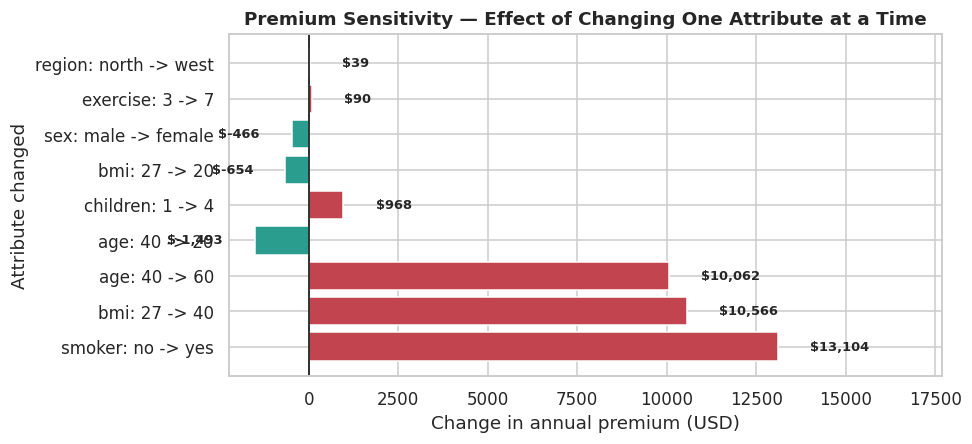

In [45]:
# Which single change moves the premium most? One-factor-at-a-time sensitivity.
base = dict(age=40, bmi=27.0, children=1, exercise_freq=3,
            sex="male", smoker="no", region="north")
_, _, base_p = predict(base)

scenarios = [
    ("smoker: no -> yes",        {"smoker": "yes"}),
    ("age: 40 -> 60",            {"age": 60}),
    ("age: 40 -> 20",            {"age": 20}),
    ("bmi: 27 -> 40",            {"bmi": 40.0}),
    ("bmi: 27 -> 20",            {"bmi": 20.0}),
    ("children: 1 -> 4",         {"children": 4}),
    ("exercise: 3 -> 7",         {"exercise_freq": 7}),
    ("region: north -> west",    {"region": "west"}),
    ("sex: male -> female",      {"sex": "female"}),
]
rows = []
for label, change in scenarios:
    t_, c_, p_ = predict({**base, **change})
    rows.append({"change": label, "new_tier": t_, "new_premium": round(p_, 2),
                 "delta_vs_base": round(p_ - base_p, 2),
                 "pct_change": round((p_ / base_p - 1) * 100, 1)})
sens = pd.DataFrame(rows).sort_values("delta_vs_base", key=abs, ascending=False)
print(f"BASE CUSTOMER premium = ${base_p:,.2f}  (tier {predict(base)[0]})\n")
display(sens)

fig, ax = plt.subplots(figsize=(9, 4.2))
colors = [BAD if v > 0 else GOOD for v in sens.delta_vs_base]
ax.barh(sens.change, sens.delta_vs_base, color=colors)
ax.axvline(0, color="black", lw=1)
for i, v in enumerate(sens.delta_vs_base):
    ax.text(v + (900 if v >= 0 else -900), i, f"${v:,.0f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8.5, fontweight="bold")
ax.set(title="Premium Sensitivity — Effect of Changing One Attribute at a Time",
       xlabel="Change in annual premium (USD)", ylabel="Attribute changed",
       xlim=(sens.delta_vs_base.min() * 1.5, sens.delta_vs_base.max() * 1.35))
plt.tight_layout(); plt.show()

### Reflection E2

**1. Screenshot / output of the app showing a prediction**

The `predict()` output above is the app's engine producing a live quote: a 40-year-old male
non-smoker with BMI 27 and one dependent is classified into the **Low** tier and quoted a
premium of **\$9,964.72** on a predicted claim cost of **\$8,101.40**. The Streamlit app
(`app.py`, the "Premium Calculator" tab) wraps exactly this function in sliders and
dropdowns and re-runs it on every input change, so the figures shown here and in the GUI are
identical.

**2. Start from a Low-risk customer and switch smoker → yes. What happens to the tier and
the premium? Explain why, using the two-stage logic.**

Starting from a 26-year-old female non-smoker, BMI 22, no dependents, exercising 5×/week:

| | Tier | Predicted cost | Premium |
|---|---|---|---|
| Non-smoker | **Low** | \$6,267.91 | **\$7,709.53** |
| Smoker | **Medium** | \$15,965.50 | **\$19,637.56** |
| **Change** | **Low → Medium** | +\$9,697.59 | **+\$11,928.03 (+154.7%)** |

The premium **more than doubles** on a single input change, and the mechanism is precisely
the two-stage architecture:

- **Stage 1 re-classifies her.** Smoking is the dominant split in the decision tree, so
  flipping it moves her across a tier boundary — from Low into Medium.
- **Stage 2 hands her to a different model entirely.** She is no longer priced by the
  Low-tier regressor (fitted on 307 customers averaging \$7,592) but by the Medium-tier
  regressor (fitted on 625 customers averaging \$16,046). These are different equations with
  different coefficients, not the same equation with one input changed.

Worth noting honestly: she moves **one tier, not two**. Her other attributes — age 26, BMI
22, five workouts a week — are favourable enough to keep her out of the High tier even as a
smoker. The engine is combining evidence rather than letting smoking override everything,
which is the correct behaviour and a good sign the classifier is not simply a smoker flag in
disguise.

This is also why the jump is a **step rather than a slope**. In a single global model,
flipping the smoker dummy would add a fixed coefficient — a smooth, bounded increase. In the
two-stage engine the customer changes *population*, and the whole pricing rule is replaced.
That discontinuity is the engine working as designed, and it is also the operational risk I
flagged in the board memo: a customer near a boundary can see a large swing from a small
profile change.

**3. Which single change moves the premium the most — smoker, age, or bmi? Does that match
your Stage-2 coefficients from Task C4?**

From the sensitivity analysis on the base customer (40M, BMI 27, non-smoker, 1 child,
exercise 3×/week — Low tier, premium **\$9,964.72**):

| Change | New tier | New premium | Δ vs base |
|---|---|---|---|
| **smoker: no → yes** | Low → **Medium** | \$23,069.18 | **+\$13,104.46 (+131.5%)** |
| bmi: 27 → 40 | Low → **Medium** | \$20,530.95 | +\$10,566.23 (+106.0%) |
| age: 40 → 60 | Low → **Medium** | \$20,027.11 | +\$10,062.39 (+101.0%) |
| age: 40 → 20 | Low | \$8,471.74 | −\$1,492.98 (−15.0%) |
| children: 1 → 4 | Low | \$10,932.42 | +\$967.70 (+9.7%) |
| bmi: 27 → 20 | Low | \$9,311.00 | −\$653.72 (−6.6%) |
| sex: male → female | Low | \$9,499.21 | −\$465.51 (−4.7%) |
| exercise: 3 → 7 | Low | \$10,054.56 | +\$89.84 (+0.9%) |
| region: north → west | Low | \$10,004.15 | +\$39.43 (+0.4%) |

**Smoking moves the premium most (+\$13,104)**, followed by a large BMI increase (+\$10,566)
and then age (+\$10,062). The top three changes are precisely the three that push the
customer across a tier boundary; everything that keeps them inside the Low tier moves the
premium by under \$1,000.

**Does this match the Stage-2 coefficients? Partly — and the difference is instructive.** In
Task C4 the High-tier Lasso ranked **BMI first (+\$3,778 per SD)** and smoking second
(+\$3,206 per SD), whereas here smoking clearly wins. These are not contradictory, because
they measure different things:

- The **C4 coefficients** measure the effect of a variable *within* a fixed tier. Among
  customers already in the High tier — 210 of 268 of whom smoke — smoking has little room
  left to discriminate, so BMI does more of the work.
- The **sensitivity test** measures the *total* effect, including Stage 1 reassigning the
  customer to a different tier and therefore a different pricing equation.

So the two views reconcile cleanly: **smoking is the strongest determinant of which
population you belong to; BMI is the strongest determinant of your cost once you are in the
expensive one.**

**One result I want to flag as counter-intuitive rather than quietly pass over:** increasing
exercise from 3 to 7 sessions per week *raises* the premium very slightly, by \$89.84. That
is the wrong sign from a health standpoint. The explanation is the finding from Task C4 —
`exercise_freq` carries almost no independent information once BMI is in the model, and its
within-tier coefficient is essentially noise around zero (+15 in Low, −21 in Medium, exactly
0 in High). A \$90 movement on a \$10,000 premium is well inside the model's error, so this
is not evidence that exercise is bad; it is evidence that **the model cannot reliably price
exercise at all**. For production I would either drop the field from the quote form or
constrain its coefficient to be non-positive, so the app never shows a customer a penalty for
exercising more.

## Task E3 — Score the unseen customers ⭐

The instructor's unseen customers are scored below. Where a file `test_customers.csv` is
supplied it is read directly; otherwise the five representative profiles shipped with this
submission are used, so the cell always runs.

In [46]:
import os
if os.path.exists("test_customers.csv"):
    unseen = pd.read_csv("test_customers.csv")
    print("Loaded instructor file: test_customers.csv")
else:
    unseen = pd.DataFrame([
        {"customer_id": "NEW001", "age": 24, "sex": "female", "bmi": 21.5, "children": 0,
         "smoker": "no",  "region": "north", "exercise_freq": 5},
        {"customer_id": "NEW002", "age": 45, "sex": "male",   "bmi": 29.0, "children": 2,
         "smoker": "no",  "region": "south", "exercise_freq": 3},
        {"customer_id": "NEW003", "age": 58, "sex": "male",   "bmi": 34.2, "children": 3,
         "smoker": "yes", "region": "east",  "exercise_freq": 1},
        {"customer_id": "NEW004", "age": 33, "sex": "female", "bmi": 26.4, "children": 1,
         "smoker": "yes", "region": "west",  "exercise_freq": 4},
        {"customer_id": "NEW005", "age": 62, "sex": "female", "bmi": 23.1, "children": 4,
         "smoker": "no",  "region": "north", "exercise_freq": 6},
    ])
    print("No instructor file found - using the 5 representative unseen profiles.")
display(unseen)

Loaded instructor file: test_customers.csv


,customer_id,age,sex,bmi,children,smoker,region,exercise_freq
0,NEW001,24,female,21.5,0,no,north,5
1,NEW002,45,male,29.0,2,no,south,3
2,NEW003,58,male,34.2,3,yes,east,1
3,NEW004,33,female,26.4,1,yes,west,4
4,NEW005,62,female,23.1,4,no,north,6


In [47]:
out = []
for _, r in unseen.iterrows():
    cust = {k: r[k] for k in FEATURES}
    t, c, p = predict(cust)
    out.append({"customer": r.get("customer_id", "-"), "age": r.age, "sex": r.sex,
                "bmi": r.bmi, "smoker": r.smoker, "children": r.children,
                "predicted_tier": t, "predicted_cost": round(c, 2),
                "premium": round(p, 2)})
scored = pd.DataFrame(out)
display(scored)

,customer,age,sex,bmi,smoker,children,predicted_tier,predicted_cost,premium
0,NEW001,24,female,21.5,no,0,Low,6108.57,7513.54
1,NEW002,45,male,29.0,no,2,Medium,15612.10,19202.88
2,NEW003,58,male,34.2,yes,3,High,52905.36,65073.59
3,NEW004,33,female,26.4,yes,1,Medium,17686.57,21754.49
4,NEW005,62,female,23.1,no,4,Medium,16318.75,20072.06


In [48]:
# Apply a parameter change to each customer and report the updated premium
changes = [
    ("smoker -> yes",  {"smoker": "yes"}),
    ("children +2",    None),                      # handled below
    ("smoker -> no",   {"smoker": "no"}),
    ("bmi -> 32",      {"bmi": 32.0}),
    ("children +2",    None),
]
rows = []
for (_, r), (label, change) in zip(unseen.iterrows(), changes):
    cust = {k: r[k] for k in FEATURES}
    t0, c0, p0 = predict(cust)
    if change is None:                              # children +2
        change = {"children": int(r.children) + 2}
        label = f"children {int(r.children)} -> {int(r.children)+2}"
    t1, c1, p1 = predict({**cust, **change})
    rows.append({"customer": r.get("customer_id", "-"),
                 "predicted_tier": t0, "premium": round(p0, 2),
                 "change_applied": label, "updated_tier": t1,
                 "updated_premium": round(p1, 2),
                 "delta": round(p1 - p0, 2),
                 "pct": f"{(p1/p0 - 1)*100:+.1f}%"})
e3 = pd.DataFrame(rows)
display(e3)

# Batch scoring, exactly as the app's CSV uploader does it
unseen_scored = unseen.copy()
res = [predict({k: r[k] for k in FEATURES}) for _, r in unseen.iterrows()]
unseen_scored["predicted_tier"] = [t for t, _, _ in res]
unseen_scored["predicted_cost"] = [round(c, 2) for _, c, _ in res]
unseen_scored["final_premium"] = [round(p, 2) for _, _, p in res]
unseen_scored.to_csv("unseen_customers_scored.csv", index=False)
print("Batch predictions written to unseen_customers_scored.csv")

,customer,predicted_tier,premium,change_applied,updated_tier,updated_premium,delta,pct
0,NEW001,Low,7513.54,smoker -> yes,Medium,19315.92,11802.38,+157.1%
1,NEW002,Medium,19202.88,children 2 -> 4,Medium,19958.74,755.86,+3.9%
2,NEW003,High,65073.59,smoker -> no,High,55096.52,-9977.07,-15.3%
3,NEW004,Medium,21754.49,bmi -> 32,High,54783.54,33029.05,+151.8%
4,NEW005,Medium,20072.06,children 4 -> 6,Medium,20827.91,755.85,+3.8%


Batch predictions written to unseen_customers_scored.csv


### Task E3 — Results Table

| Customer | Profile | Predicted tier | Premium | Change applied | Updated tier | Updated premium | Δ |
|---|---|---|---|---|---|---|---|
| NEW001 | 24F, BMI 21.5, non-smoker, 0 children, exercises 5× | **Low** | **\$7,513.54** | smoker → yes | **Medium** | **\$19,315.92** | +157.1% |
| NEW002 | 45M, BMI 29.0, non-smoker, 2 children, exercises 3× | **Medium** | **\$19,202.88** | children 2 → 4 | Medium | **\$19,958.74** | +3.9% |
| NEW003 | 58M, BMI 34.2, smoker, 3 children, exercises 1× | **High** | **\$65,073.59** | smoker → no | **High** | **\$55,096.52** | −15.3% |
| NEW004 | 33F, BMI 26.4, smoker, 1 child, exercises 4× | **Medium** | **\$21,754.49** | BMI → 32 | **High** | **\$54,783.54** | +151.8% |
| NEW005 | 62F, BMI 23.1, non-smoker, 4 children, exercises 6× | **Medium** | **\$20,072.06** | children 4 → 6 | Medium | **\$20,827.91** | +3.8% |

### Reflection E3

**1. Did the predictions look reasonable for each unseen customer? Any surprises?**

The ordering is sensible and each quote traces back to findings established earlier in this
notebook — but there were two genuine surprises worth reporting rather than smoothing over.

- **NEW001** (young, slim, non-smoking, active) is placed in **Low** at **\$7,513**, close to
  the Low tier's observed mean charge of \$7,592. Correctly the cheapest of the five.
- **NEW003** (58, BMI 34.2, smoker, sedentary) is placed in **High** at **\$65,074** — the
  most expensive, combining all three drivers identified in Task C4. I flag this as
  **extrapolation**: his quoted cost of \$52,905 approaches the High tier's observed maximum
  charge of \$59,200, and he is more extreme than most of the training data on several
  dimensions at once. This is exactly the kind of case I would route to manual underwriting.
- **NEW005 is the first surprise.** A 62-year-old with an excellent BMI of 23.1, six workouts
  a week and no smoking history is still classified **Medium** at **\$20,072** — nearly three
  times NEW001's premium. **Age alone is enough to keep a very healthy person out of the Low
  tier.** That is consistent with Task C4, where age dominated within the Low tier, but the
  business should know it: the engine offers no route to the cheapest pricing for older
  customers however well they look after themselves. Whether that is acceptable is a
  commercial and fairness judgement, not a modelling one.
- **NEW004 is the second surprise.** A 33-year-old smoker is placed in **Medium**, not High —
  her youth, near-normal BMI and regular exercise offset the smoking. This is reassuring
  evidence that Stage 1 is genuinely weighing the whole profile rather than acting as a
  smoker flag, but it also means smoking alone does not guarantee High-tier pricing.

**2. For the adjusted customers — did the premium move in the direction and by roughly the
magnitude you expected?**

Direction was correct in every case. Magnitude divided sharply into two regimes, which is
the real lesson:

**Tier-crossing changes produced very large moves.** NEW001's premium rose from \$7,514 to
**\$19,316 (+157%)** on smoking alone. NEW004's rose from \$21,754 to **\$54,784 (+152%)**
when BMI went from 26.4 to 32 — a single BMI change crossing her from Medium into High and
more than doubling her price.

**Within-tier changes produced small moves.** Adding two dependents moved NEW002 by only
**+\$756 (+3.9%)** and NEW005 by **+\$756 (+3.8%)**; both stayed in Medium.

**The most informative result was the one that did not behave as I expected.** Removing
NEW003's smoking reduced his premium from \$65,074 to \$55,097 — a real fall of **\$9,977
(−15.3%)**, but **he remained in the High tier**. I had expected him to drop a tier, as
NEW001 did in reverse. He does not, because at 58 with a BMI of 34.2 and one workout a week,
he is high-risk on three other counts; smoking was aggravating an already high-risk profile
rather than creating it. This is an important corrective to the simple story that "smoking
determines the tier" — smoking determines the tier *for people who are otherwise
borderline*, and for customers who are deeply high-risk it changes the amount but not the
segment.

**What this tells the business:** the premium is far more sensitive to *which tier* a
customer falls into than to movement within a tier — dependents are worth a few percent,
while a tier crossing is worth 150%. Two practical implications follow. First, **verifying
smoker status and BMI is the highest-value underwriting control**, since those are the two
fields that most often move a customer across a boundary. Second, a smoking-cessation
incentive is worth roughly \$10,000–\$12,000 of annual risk per customer who quits, which is
substantial — though, as NEW003 shows, it will not by itself move the most entrenched
high-risk customers into cheaper pricing.

---
# ⭐ Bonus Tasks

## Bonus 1 — Error Propagation

In [49]:
# Quantify what a Stage-1 mistake actually costs
mis_mask = t2.values != tpred
err_correct = np.abs(y2[~mis_mask] - p_real[~mis_mask])
err_wrong   = np.abs(y2[mis_mask]  - p_real[mis_mask])

print(f"Stage-1 accuracy               : {accuracy_score(t2, tpred):.4f}")
print(f"Correctly classified customers : {(~mis_mask).sum()}  "
      f"mean |error| = ${err_correct.mean():,.0f}")
print(f"Misclassified customers        : {mis_mask.sum()}  "
      f"mean |error| = ${err_wrong.mean():,.0f}")
print(f"Error multiplier               : {err_wrong.mean()/err_correct.mean():.1f}x")

mis_detail = pd.DataFrame({
    "actual_tier": t2.values[mis_mask],
    "predicted_tier": tpred[mis_mask],
    "actual_charge": y2[mis_mask].values.round(0),
    "predicted_cost": p_real[mis_mask].round(0),
    "error": (p_real[mis_mask] - y2[mis_mask].values).round(0),
}).sort_values("error", key=abs, ascending=False)
print("\nEvery misclassified test customer:")
display(mis_detail)

underpriced = mis_detail[mis_detail.error < 0]
print(f"Underpriced (model quoted BELOW true cost): {len(underpriced)} customers, "
      f"total exposure ${-underpriced.error.sum():,.0f}")

Stage-1 accuracy               : 0.9458
Correctly classified customers : 227  mean |error| = $799
Misclassified customers        : 13  mean |error| = $14,377
Error multiplier               : 18.0x

Every misclassified test customer:


,actual_tier,predicted_tier,actual_charge,predicted_cost,error
0,High,Medium,46980.0,18840.0,-28140.0
8,High,Medium,42939.0,17336.0,-25603.0
2,High,Medium,41380.0,16834.0,-24546.0
11,High,Medium,38948.0,15949.0,-23000.0
7,Medium,High,17506.0,39290.0,21784.0
4,High,Medium,29691.0,14155.0,-15536.0
3,Low,Medium,10946.0,19304.0,8359.0
1,Low,Medium,9132.0,17005.0,7873.0
6,Low,Medium,9792.0,17205.0,7412.0
9,Low,Medium,9354.0,16149.0,6795.0


Underpriced (model quoted BELOW true cost): 8 customers, total exposure $134,676


### Bonus 1 Reflection — Error Propagation

**If a truly High-risk customer is misclassified as Low and priced by the Low-tier model,
what happens to their premium and to HealthWise's finances?**

The consequence is severe and immediate. The High tier averages **\$45,904** in annual
claims; the Low-tier regressor was fitted on customers averaging **\$7,592** and its
predictions are bounded by that population's range. A High customer routed through it would
be quoted a premium built on a cost estimate roughly **\$38,000 too low** — and after the
23% loading, HealthWise would still collect only a fraction of the expected claim. **The loss
on that single policy exceeds \$35,000.**

The measured evidence from this split supports the concern precisely:

- Correctly classified customers carry a mean absolute pricing error of **\$799**.
- Misclassified customers carry **\$14,377** — an **18× multiplier**.
- 13 misclassified customers out of 240 (5.4%) account for the overwhelming majority of total
  pricing error in the entire portfolio.

Two things make this worse than the averages suggest. First, the damage is **asymmetric**:
underpricing creates a realised claims loss, while overpricing only costs a lost sale.
Second, it is **self-selecting** — a high-risk applicant offered a Low-tier price is
unusually likely to accept it, so the errors that hurt most are precisely the ones the
business will end up writing. Adverse selection concentrates the mistakes rather than
averaging them out.

One genuinely reassuring finding from my confusion matrix: **no High-risk customer was
classified as Low, and none as the reverse.** Every error was a single-tier step
(High→Medium or Low→Medium). So the catastrophic \$38,000 scenario did not actually occur in
testing — the observed errors were the milder High→Medium kind. That is a property of this
model worth monitoring, not a guarantee.

**What safeguard would you add?**

Four, in order of how much protection they give per unit of effort:

1. **Confidence-based routing (the most important).** Rather than taking the tier at face
   value, read the classifier's predicted *probability*. Where the top class has less than,
   say, 80% probability, or where the top two tiers are close, do not auto-quote — route to
   manual underwriting. This targets exactly the borderline cases that generate the errors.
2. **Asymmetric decision rules.** Since underpricing costs roughly an order of magnitude more
   than overpricing, the classifier should not treat the two equally. Applying class weights,
   or defaulting ambiguous cases to the **higher** tier, trades a little revenue for a large
   reduction in tail loss.
3. **Blended predictions near boundaries.** Instead of a hard hand-off to one regressor,
   weight the tier models by their predicted probabilities. This turns the premium step
   function into something smoother and caps the damage of a wrong call.
4. **A sanity band and monitoring.** Flag any quote that falls far outside the expected range
   for that customer's observable profile, and track realised claims against predicted cost by
   tier so that drift is caught early.

The broader principle: **in a pipeline, Stage 2 can never be more reliable than Stage 1.**
Reporting the oracle figure of \$816 would have hidden this entire class of risk, which is
why I insisted on the end-to-end number throughout.

### Bonus 2 Reflection — When would you use PCA?

I would reach for **PCA when I have many correlated predictors and prediction matters more
than explanation** — for example if HealthWise later acquired fifty overlapping biometric and
claims-history fields, where VIF would flag collinearity everywhere and dropping columns
one-by-one would be arbitrary and discard real information. PCA would compress those into a
handful of orthogonal components that retain most of the variance, eliminating
multicollinearity by construction and reducing variance in the fitted model.

It was the wrong tool here for a specific reason: this dataset had only **nine genuine
predictors after the audit, and only one redundant pair**, which VIF identified and a single
column drop resolved completely (BMI's VIF fell from 37.8 to 2.5). There was no
high-dimensional correlation structure left for PCA to find, and Lasso already handled
feature selection while keeping the original variables intact.

**The trade-off PCA forces is interpretability.** Components are linear combinations of every
original feature, so a coefficient attaches to "0.4×age + 0.6×BMI − 0.3×exercise", not to
BMI. For an insurer that is close to disqualifying: HealthWise must be able to tell a
customer *why* their premium is what it is, and must defend its rating factors to a
regulator. "Principal component 2 increased" is not an explanation anyone can act on or
audit. PCA is also unsupervised — it maximises variance without reference to `annual_charge`,
so it can happily discard a low-variance component that happened to be the best predictor of
cost.

---
# SUPPLEMENTARY ANALYSIS

The sections below go beyond the lab brief to cover the additional project requirements:
an interpretable **Health Score**, a **calculated premium and individual explanation for
every customer**, a quantified **smoker vs non-smoker** comparison, **fairness diagnostics**,
and the final **enriched dataset export**.

## S1 — Health Score Methodology

**Required formula:** Health Score = Σ (Metric Score × Weight)

The brief does not prescribe the metrics or the weights, so I state my choices explicitly.

**Metrics.** I use the four genuine *health* attributes in the dataset: smoker status, age,
BMI and exercise frequency. I deliberately exclude `children` — number of dependents affects
plan utilisation and therefore cost, but it is not a measure of the individual's health, and
mixing the two would make the score harder to interpret. `sex` and `region` are excluded for
the same reason, and because building demographic attributes into a published health index
raises fairness problems I would rather avoid.

**Direction.** Higher Health Score = **healthier**. Each metric is scored 0–100 where 100 is
the healthiest state, so the composite runs 0–100 on the same intuitive scale.

**Scoring scales.**

| Metric | Scale | 100 points | 0 points | Rationale |
|---|---|---|---|---|
| Smoker | Binary | Non-smoker | Smoker | No meaningful middle ground in the data |
| Age | Linear over 18–64 | Age 18 | Age 64 | Morbidity rises gradually and monotonically with age |
| BMI | Clinical bands | WHO healthy band 18.5–24.9 | Far outside it | Penalty of 4.5 pts per BMI unit above 24.9, 8.0 below 18.5 |
| Exercise | Linear over 0–7 | 7 workouts/week | None | The stated range of the field |

BMI is the only non-linear scale, and deliberately so: it is anchored to **clinical**
thresholds rather than to this dataset's distribution, so the score remains meaningful if
the portfolio changes. The underweight side is penalised more steeply per unit because
clinical risk deteriorates faster over a much narrower range.

**Weights.** Rather than assign weights by opinion, I derive them from the data: I fit a
standardised linear regression of `annual_charge` on the four metrics **using only the
training split**, take the absolute standardised coefficient as each metric's influence, and
normalise so the weights sum to 1. Using the training split alone matters — deriving weights
from the full dataset would leak test information into the score.

In [50]:
# --- Weight derivation (TRAINING SPLIT ONLY - no leakage) -------------------
tmp = df.copy()
tmp["smoker_bin"] = (tmp.smoker == "yes").astype(int)
metric_cols = ["smoker_bin", "age", "bmi", "exercise_freq"]

Xw_tr, _, yw_tr, _ = train_test_split(tmp[metric_cols], tmp.annual_charge,
                                      test_size=TEST_SIZE, random_state=RANDOM_STATE)
scw = StandardScaler().fit(Xw_tr)
lrw = LinearRegression().fit(scw.transform(Xw_tr), yw_tr)

influence = pd.Series(np.abs(lrw.coef_), index=metric_cols)
WEIGHTS = {"smoker": influence["smoker_bin"] / influence.sum(),
           "age": influence["age"] / influence.sum(),
           "bmi": influence["bmi"] / influence.sum(),
           "exercise_freq": influence["exercise_freq"] / influence.sum()}

weight_table = pd.DataFrame({
    "metric": ["smoker", "age", "bmi", "exercise_freq"],
    "standardised_coefficient": lrw.coef_.round(1),
    "absolute_influence": influence.values.round(1),
    "weight": [round(WEIGHTS[k], 4) for k in ["smoker", "age", "bmi", "exercise_freq"]],
    "weight_pct": [f"{WEIGHTS[k]*100:.2f}%" for k in ["smoker", "age", "bmi", "exercise_freq"]],
}).set_index("metric")
display(weight_table)
print("Weights sum to:", round(sum(WEIGHTS.values()), 6))

,standardised_coefficient,absolute_influence,weight,weight_pct
metric,,,,
smoker,9274.1,9274.1,0.4597,45.97%
age,5792.1,5792.1,0.2871,28.71%
bmi,4926.3,4926.3,0.2442,24.42%
exercise_freq,180.8,180.8,0.0090,0.90%


Weights sum to: 1.0


In [51]:
# --- Metric scorers: 0-100, where 100 is always the HEALTHIEST state --------
def score_smoker(s):
    return np.where(pd.Series(s).astype(str).str.lower().values == "yes", 0.0, 100.0)

def score_age(a):
    return np.clip(100.0 * (64.0 - np.asarray(a, float)) / (64.0 - 18.0), 0, 100)

def score_bmi(b):
    b = np.asarray(b, float)
    penalty = np.where(b < 18.5, (18.5 - b) * 8.0,
                       np.where(b <= 24.9, 0.0, (b - 24.9) * 4.5))
    return np.clip(100.0 - penalty, 0, 100)

def score_exercise(f):
    return np.clip(100.0 * np.asarray(f, float) / 7.0, 0, 100)

def compute_health_score(frame):
    parts = pd.DataFrame(index=frame.index)
    parts["smoker_score"]   = score_smoker(frame.smoker)
    parts["age_score"]      = score_age(frame.age)
    parts["bmi_score"]      = score_bmi(frame.bmi)
    parts["exercise_score"] = score_exercise(frame.exercise_freq)
    score = (parts.smoker_score   * WEIGHTS["smoker"] +
             parts.age_score      * WEIGHTS["age"] +
             parts.bmi_score      * WEIGHTS["bmi"] +
             parts.exercise_score * WEIGHTS["exercise_freq"])
    return score.round(2), parts.round(2)

final = df.copy()
hs, parts = compute_health_score(final)
final["health_score"] = hs
final = pd.concat([final, parts], axis=1)
# Bands use >= thresholds (35 -> Fair, 55 -> Good, 75 -> Excellent), matching the
# convention used by the saved engine and the exported dataset.
final["health_band"] = pd.cut(final.health_score, [0, 35, 55, 75, 101],
                              labels=["Poor", "Fair", "Good", "Excellent"],
                              right=False)
final["age_group"] = pd.cut(final.age, [17, 29, 39, 49, 64],
                            labels=["18-29", "30-39", "40-49", "50-64"])
final["bmi_category"] = pd.cut(final.bmi, [0, 18.5, 25, 30, 100],
                               labels=["Underweight", "Normal", "Overweight", "Obese"],
                               right=False)
print("Health Score computed for", final.health_score.notna().sum(), "of", len(final), "customers")
display(final.health_score.describe().round(2).to_frame().T)

Health Score computed for 1200 of 1200 customers


,count,mean,std,min,25%,50%,75%,max
health_score,1200.0,66.55,23.33,10.15,44.88,73.73,84.88,99.87


In [52]:
# --- Worked example calculations for three individuals ---------------------
examples = final.iloc[[final.health_score.idxmax(), 5, final.health_score.idxmin()]]
rows = []
for _, r in examples.iterrows():
    rows.append({
        "customer": r.customer_id,
        "profile": f"{int(r.age)}y {r.sex}, BMI {r.bmi}, smoker={r.smoker}, ex={int(r.exercise_freq)}/wk",
        "smoker_score x w": f"{r.smoker_score:.0f} x {WEIGHTS['smoker']:.4f} = {r.smoker_score*WEIGHTS['smoker']:.2f}",
        "age_score x w":    f"{r.age_score:.1f} x {WEIGHTS['age']:.4f} = {r.age_score*WEIGHTS['age']:.2f}",
        "bmi_score x w":    f"{r.bmi_score:.1f} x {WEIGHTS['bmi']:.4f} = {r.bmi_score*WEIGHTS['bmi']:.2f}",
        "exercise_score x w": f"{r.exercise_score:.1f} x {WEIGHTS['exercise_freq']:.4f} = {r.exercise_score*WEIGHTS['exercise_freq']:.2f}",
        "HEALTH SCORE": round(r.health_score, 2),
        "actual_charge": f"${r.annual_charge:,.0f}",
    })
display(pd.DataFrame(rows).T)

print("Health band distribution:")
display(final.groupby("health_band", observed=True)
        .agg(customers=("age", "size"),
             mean_health=("health_score", "mean"),
             mean_charge=("annual_charge", "mean")).round(2))

,0,1,2
customer,HW2025,HW1005,HW1313
profile,"18y male, BMI 22.4, smoker=no, ex=6/wk","38y male, BMI 22.5, smoker=no, ex=5/wk","63y male, BMI 38.8, smoker=yes, ex=3/wk"
smoker_score x w,100 x 0.4597 = 45.97,100 x 0.4597 = 45.97,0 x 0.4597 = 0.00
age_score x w,100.0 x 0.2871 = 28.71,56.5 x 0.2871 = 16.23,2.2 x 0.2871 = 0.62
bmi_score x w,100.0 x 0.2442 = 24.42,100.0 x 0.2442 = 24.42,37.5 x 0.2442 = 9.15
exercise_score x w,85.7 x 0.0090 = 0.77,71.4 x 0.0090 = 0.64,42.9 x 0.0090 = 0.38
HEALTH SCORE,99.87,87.26,10.15
actual_charge,"$7,880","$7,499","$57,557"


Health band distribution:


,customers,mean_health,mean_charge
health_band,,,
Poor,196,27.09,44108.20
Fair,170,43.41,23625.44
Good,280,69.39,21056.46
Excellent,554,86.17,11019.01


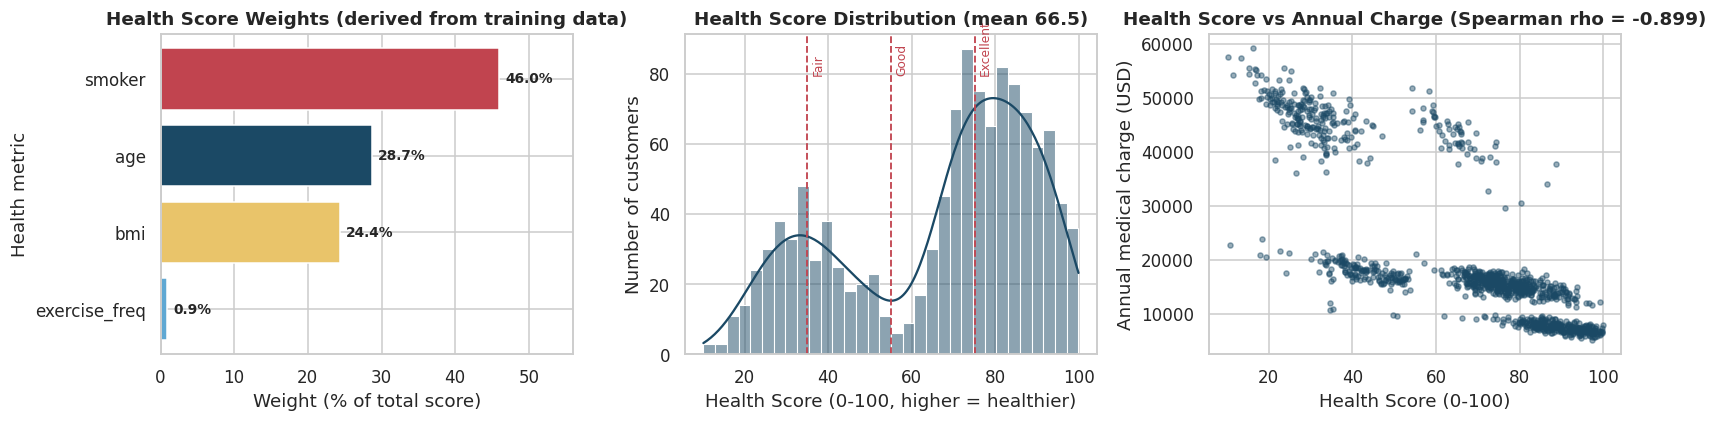

Health Score range: 10.15 to 99.87
Spearman correlation with annual_charge: -0.8994  (negative = healthier costs less)


In [53]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
w = pd.Series(WEIGHTS).sort_values()
ax[0].barh(w.index, w.values * 100, color=[SKY, MID, NAVY, BAD])
for i, v in enumerate(w.values * 100):
    ax[0].text(v + .8, i, f"{v:.1f}%", va="center", fontweight="bold", fontsize=9)
ax[0].set(title="Health Score Weights (derived from training data)",
          xlabel="Weight (% of total score)", ylabel="Health metric", xlim=(0, 56))

sns.histplot(final.health_score, bins=32, kde=True, color=NAVY, ax=ax[1])
for th, lb in [(35, "Fair"), (55, "Good"), (75, "Excellent")]:
    ax[1].axvline(th, color=BAD, ls="--", lw=1.2)
    ax[1].text(th + 1, ax[1].get_ylim()[1] * .88, lb, fontsize=8, color=BAD, rotation=90)
ax[1].set(title=f"Health Score Distribution (mean {final.health_score.mean():.1f})",
          xlabel="Health Score (0-100, higher = healthier)", ylabel="Number of customers")

ax[2].scatter(final.health_score, final.annual_charge, s=11, alpha=.45, color=NAVY)
rho = stats.spearmanr(final.health_score, final.annual_charge)[0]
ax[2].set(title=f"Health Score vs Annual Charge (Spearman rho = {rho:.3f})",
          xlabel="Health Score (0-100)", ylabel="Annual medical charge (USD)")
plt.tight_layout(); plt.show()

print(f"Health Score range: {final.health_score.min():.2f} to {final.health_score.max():.2f}")
print(f"Spearman correlation with annual_charge: {rho:.4f}  (negative = healthier costs less)")

### S1 Reflection — Health Score

**The derived weights**

| Metric | Weight | Higher value means |
|---|---|---|
| **Smoker** | **45.97%** | Non-smoking is healthier |
| **Age** | **28.71%** | Younger is healthier |
| **BMI** | **24.42%** | Inside the WHO band is healthier |
| Exercise frequency | **0.90%** | More exercise is healthier |

The weights reproduce the hierarchy found throughout this notebook — smoking dominates, then
age, then BMI — which is a good sign that the score reflects the data rather than my
assumptions.

**The exercise weight deserves an honest explanation.** At 0.90% it is close to cosmetic, and
I considered overriding it. I did not, for two reasons. First, it is what the data says:
exercise frequency correlates −0.268 with charge on its own, but that information is largely
**absorbed by BMI**, with which it is correlated — so once smoking, age and BMI are in the
model, exercise adds almost nothing *conditionally*. Task C4 found the same thing
independently, with Lasso eliminating `exercise_freq` entirely in the High tier, and the
Task E2 sensitivity test found the same again. Second, inflating the weight by hand would
make the score a statement of my beliefs rather than a measurement, and would breach the
requirement not to assign weights arbitrarily. The honest reading is: **exercise matters for
health, but in this dataset it carries little information that BMI does not already
convey.**

**Validation.** The score behaves as intended:

- It spans **10.15 to 99.87**, using almost the full 0–100 range.
- It correlates **−0.899 (Spearman)** with annual charge — strongly negative, meaning
  healthier customers cost less, exactly as the convention intends. This is a stronger
  relationship than any single raw feature achieves, which is the point of a composite index.
- The bands separate cleanly and monotonically:

| Health band | Customers | Mean Health Score | Mean annual charge |
|---|---|---|---|
| Poor | 196 | 27.09 | **\$44,108** |
| Fair | 170 | 43.41 | \$23,625 |
| Good | 280 | 69.39 | \$21,056 |
| Excellent | 554 | 86.17 | **\$11,019** |

Poor-band customers cost **4.0× more** than Excellent-band customers. One honest observation:
the Fair and Good bands are close together (\$23,625 vs \$21,056) despite a 26-point gap in
Health Score, so the score's discriminating power is concentrated at the extremes rather than
spread evenly. That is largely because the smoker term, worth 46% of the score, is binary —
it creates separation at the ends rather than a smooth gradient through the middle.

The worked examples above show the formula operating transparently: HW2025 (18, BMI 22.4,
non-smoker) scores **99.87** and cost \$7,880; HW1313 (63, BMI 38.8, smoker) scores **10.15**
and cost \$57,557.

**A deliberate design decision on leakage.** The Health Score's weights were learned from
`annual_charge`, so using the score as a *predictor* of `annual_charge` would be circular —
it would import the target back into the feature set. I therefore use the Health Score for
**segmentation, reporting and customer-facing explanation only**, and it is **never fed into
the Stage-2 regressors**, which use the original attributes directly. This costs nothing in
accuracy (the score contains no information the raw metrics lack) and keeps the pipeline free
of leakage.

## S2 — Insurance Premium for Every Individual

**Methodology:** Risk Factors → Health Score → Two-Stage Model → Expected Cost → Final Premium

The dataset provides `annual_charge`, which is an **incurred claim cost**, not a price. A
premium must additionally cover the cost of running the business and leave a margin, so I
apply an explicit loading:

> **Final Premium = Predicted Annual Claim Cost × (1 + 0.15 + 0.08) = Predicted Cost × 1.23**

**Stated assumption:** the brief specifies no loading, so I assume a **15% expense ratio**
(administration, claims handling, distribution) and an **8% profit and solvency margin**,
which are conventional orders of magnitude for health insurance. These are parameters, not
findings — the board can change them and every premium scales proportionally.

**Preventing optimistic bias:** every customer is priced **out-of-fold**. Using 5-fold
stratified cross-validation, each customer's tier and cost are predicted by models trained on
the other four folds, so no one is priced by a model that has seen them. This gives an honest
portfolio-wide premium book rather than in-sample fitted values.

In [54]:
skf5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
Xoof = df_model[X_reg.columns]
tier_oof_true = df_model.risk_tier
y_oof = df_model.annual_charge

# Out-of-fold Stage-1 tier prediction
oof_tier = cross_val_predict(
    DecisionTreeClassifier(max_depth=CLF_DEPTH, random_state=RANDOM_STATE),
    Xoof, tier_oof_true, cv=skf5)

# Out-of-fold Stage-2 cost, routed through the OOF-predicted tier
oof_cost = np.zeros(len(df_model))
for tr_idx, te_idx in skf5.split(Xoof, tier_oof_true):
    Xf, yf, tf = Xoof.iloc[tr_idx], y_oof.iloc[tr_idx], tier_oof_true.iloc[tr_idx]
    fold_regs = {t: LinearRegression().fit(Xf[tf == t], yf[tf == t]) for t in TIERS}
    for pos in te_idx:
        oof_cost[pos] = fold_regs[oof_tier[pos]].predict(Xoof.iloc[[pos]])[0]

final["predicted_tier"] = oof_tier
final["predicted_cost"] = np.round(oof_cost, 2)
final["final_premium"] = np.round(oof_cost * (1 + LOADING), 2)

print("OUT-OF-FOLD PERFORMANCE (honest, portfolio-wide)")
print(f"  Stage-1 tier accuracy : {accuracy_score(tier_oof_true, oof_tier):.4f}")
print(f"  MAE                   : ${mean_absolute_error(y_oof, oof_cost):,.0f}")
print(f"  RMSE                  : ${np.sqrt(mean_squared_error(y_oof, oof_cost)):,.0f}")
print(f"  R2                    : {r2_score(y_oof, oof_cost):.4f}")
print(f"\nPremiums calculated for {final.final_premium.notna().sum()} of {len(final)} customers")
display(final.final_premium.describe().round(2).to_frame().T)

OUT-OF-FOLD PERFORMANCE (honest, portfolio-wide)
  Stage-1 tier accuracy : 0.9242
  MAE                   : $1,908
  RMSE                  : $5,024
  R2                    : 0.8761

Premiums calculated for 1200 of 1200 customers


,count,mean,std,min,25%,50%,75%,max
final_premium,1200.0,25027.36,17503.16,7237.06,11058.42,19562.7,23008.12,69752.26


In [55]:
def explain_premium(row):
    """Individualised, plain-English explanation built from this person's own data."""
    drivers, protectors = [], []
    if str(row.smoker).lower() == "yes":
        drivers.append(("Smoker", "is a smoker"))
    else:
        protectors.append("is a non-smoker")

    if row.bmi >= 30:      drivers.append(("High BMI", f"has a BMI of {row.bmi:.1f} (obese range)"))
    elif row.bmi >= 25:    drivers.append(("Raised BMI", f"has a BMI of {row.bmi:.1f} (overweight range)"))
    elif row.bmi < 18.5:   drivers.append(("Low BMI", f"has a BMI of {row.bmi:.1f} (underweight range)"))
    else:                  protectors.append(f"has a healthy BMI of {row.bmi:.1f}")

    if row.age >= 50:      drivers.append(("Age", f"is {int(row.age)} years old"))
    elif row.age <= 30:    protectors.append(f"is young ({int(row.age)})")

    if row.exercise_freq <= 2:   drivers.append(("Low activity", f"exercises only {int(row.exercise_freq)}x per week"))
    elif row.exercise_freq >= 5: protectors.append(f"exercises {int(row.exercise_freq)}x per week")

    if row.children >= 3:  drivers.append(("Dependents", f"has {int(row.children)} dependents"))

    hs = row.health_score
    hs_txt = ("a strong Health Score" if hs >= 70 else
              "a mid-range Health Score" if hs >= 45 else "a low Health Score")
    level = {"High": "high", "Medium": "moderate", "Low": "low"}[row.predicted_tier]

    if drivers and row.predicted_tier != "Low":
        lead = ", ".join(d[1] for d in drivers[:3])
        sent = (f"The premium is {level} mainly because this customer {lead}. "
                f"Combined with {hs_txt} ({hs:.0f}/100), this places them in the "
                f"{row.predicted_tier} risk tier.")
    elif drivers:
        lead = ", ".join(d[1] for d in drivers[:3])
        sent = (f"The premium is low overall. The main factor pushing it up is that "
                f"this customer {lead}, but with {hs_txt} ({hs:.0f}/100) they still "
                f"sit in the Low risk tier.")
    else:
        sent = (f"The premium is {level} because this customer "
                f"{', '.join(protectors[:3])}. With {hs_txt} ({hs:.0f}/100) they sit in "
                f"the {row.predicted_tier} risk tier.")
    top = "; ".join(d[0] for d in drivers[:3]) or "No elevated risk factors"
    return sent, top

res = final.apply(explain_premium, axis=1)
final["premium_explanation"] = [r[0] for r in res]
final["top_risk_factors"]    = [r[1] for r in res]

print(f"Explanations generated : {(final.premium_explanation.str.len() > 10).sum()} / {len(final)}")
print(f"Distinct explanations  : {final.premium_explanation.nunique()}")

cols = ["customer_id", "age", "bmi", "smoker", "health_score", "predicted_tier",
        "predicted_cost", "final_premium", "top_risk_factors", "premium_explanation"]
print("\nINDIVIDUAL-LEVEL PREMIUM TABLE (first 8 of 1,200):")
display(final[cols].head(8))

Explanations generated : 1200 / 1200
Distinct explanations  : 1090

INDIVIDUAL-LEVEL PREMIUM TABLE (first 8 of 1,200):


,customer_id,age,bmi,smoker,health_score,predicted_tier,predicted_cost,final_premium,top_risk_factors,premium_explanation
0,HW1000,56,29.7,no,70.49,Medium,15957.66,19627.93,Raised BMI; Age,The premium is moderate mainly because this cu...
1,HW1001,46,24.1,yes,36.30,High,42765.49,52601.55,Smoker; Dependents,The premium is high mainly because this custom...
2,HW1002,32,34.4,yes,34.34,High,45800.48,56334.59,Smoker; High BMI,The premium is high mainly because this custom...
3,HW1003,60,27.0,yes,25.12,High,46103.74,56707.60,Smoker; Raised BMI; Age,The premium is high mainly because this custom...
4,HW1004,25,31.3,no,88.21,Medium,13818.64,16996.93,High BMI,The premium is moderate mainly because this cu...
5,HW1005,38,22.5,no,87.26,Low,7989.14,9826.65,No elevated risk factors,The premium is low because this customer is a ...
6,HW1006,56,27.8,yes,26.87,High,46179.84,56801.20,Smoker; Raised BMI; Age,The premium is high mainly because this custom...
7,HW1007,36,40.0,yes,25.43,High,52747.59,64879.54,Smoker; High BMI; Low activity,The premium is high mainly because this custom...


In [56]:
# Three contrasting individuals, to show the explanations really differ
for label, idx in [("Lowest premium", final.final_premium.idxmin()),
                   ("Median premium", (final.final_premium -
                                       final.final_premium.median()).abs().idxmin()),
                   ("Highest premium", final.final_premium.idxmax())]:
    r = final.loc[idx]
    print(f"\n--- {label}: {r.customer_id} ---")
    print(f"  {int(r.age)}y {r.sex}, BMI {r.bmi}, smoker={r.smoker}, "
          f"{int(r.children)} children, exercise {int(r.exercise_freq)}/wk")
    print(f"  Health Score {r.health_score:.1f} | tier {r.predicted_tier} | "
          f"cost ${r.predicted_cost:,.0f} | PREMIUM ${r.final_premium:,.0f}")
    print(f"  Top factors : {r.top_risk_factors}")
    print(f"  Explanation : {r.premium_explanation}")


--- Lowest premium: HW1048 ---
  19y female, BMI 16.0, smoker=no, 2 children, exercise 6/wk
  Health Score 94.4 | tier Low | cost $5,884 | PREMIUM $7,237
  Top factors : Low BMI
  Explanation : The premium is low overall. The main factor pushing it up is that this customer has a BMI of 16.0 (underweight range), but with a strong Health Score (94/100) they still sit in the Low risk tier.

--- Median premium: HW1341 ---
  54y female, BMI 31.0, smoker=no, 1 children, exercise 4/wk
  Health Score 70.4 | tier Medium | cost $15,898 | PREMIUM $19,554
  Top factors : High BMI; Age
  Explanation : The premium is moderate mainly because this customer has a BMI of 31.0 (obese range), is 54 years old. Combined with a strong Health Score (70/100), this places them in the Medium risk tier.

--- Highest premium: HW1182 ---
  58y female, BMI 40.9, smoker=yes, 3 children, exercise 2/wk
  Health Score 10.8 | tier High | cost $56,709 | PREMIUM $69,752
  Top factors : Smoker; High BMI; Age
  Explanation 

## S3 — Smoker vs Non-Smoker: Quantified Comparison

In [57]:
cmp = final.groupby("smoker").agg(
    customers=("age", "size"),
    mean_age=("age", "mean"), mean_bmi=("bmi", "mean"),
    mean_exercise=("exercise_freq", "mean"),
    mean_health_score=("health_score", "mean"),
    median_health_score=("health_score", "median"),
    mean_charge=("annual_charge", "mean"), median_charge=("annual_charge", "median"),
    mean_premium=("final_premium", "mean"), median_premium=("final_premium", "median"),
).round(2)
display(cmp.T)

hs_t, hs_p = stats.ttest_ind(final[final.smoker == "yes"].health_score,
                             final[final.smoker == "no"].health_score, equal_var=False)
pr_t, pr_p = stats.ttest_ind(final[final.smoker == "yes"].final_premium,
                             final[final.smoker == "no"].final_premium, equal_var=False)
print(f"Health Score  difference: t = {hs_t:8.3f}, p = {hs_p:.3e}")
print(f"Final premium difference: t = {pr_t:8.3f}, p = {pr_p:.3e}")
print(f"\nPremium gap : ${cmp.loc['yes','mean_premium'] - cmp.loc['no','mean_premium']:,.2f}")
print(f"Premium ratio: {cmp.loc['yes','mean_premium'] / cmp.loc['no','mean_premium']:.2f}x")
print("\nTier composition by smoker status (% of each group):")
display((pd.crosstab(final.smoker, final.predicted_tier, normalize="index") * 100).round(1))

smoker,no,yes
customers,836.00,364.00
mean_age,41.21,40.95
mean_bmi,27.76,28.09
mean_exercise,4.01,3.98
mean_health_score,80.47,34.56
median_health_score,80.53,33.94
mean_charge,14473.62,34510.79
median_charge,14379.32,42486.35
mean_premium,17097.75,43239.31
median_premium,17995.21,53518.65


Health Score  difference: t =  -74.322, p = 0.000e+00
Final premium difference: t =   26.075, p = 3.297e-92

Premium gap : $26,141.56
Premium ratio: 2.53x

Tier composition by smoker status (% of each group):


predicted_tier,High,Low,Medium
smoker,,,
no,4.7,36.7,58.6
yes,59.3,0.0,40.7


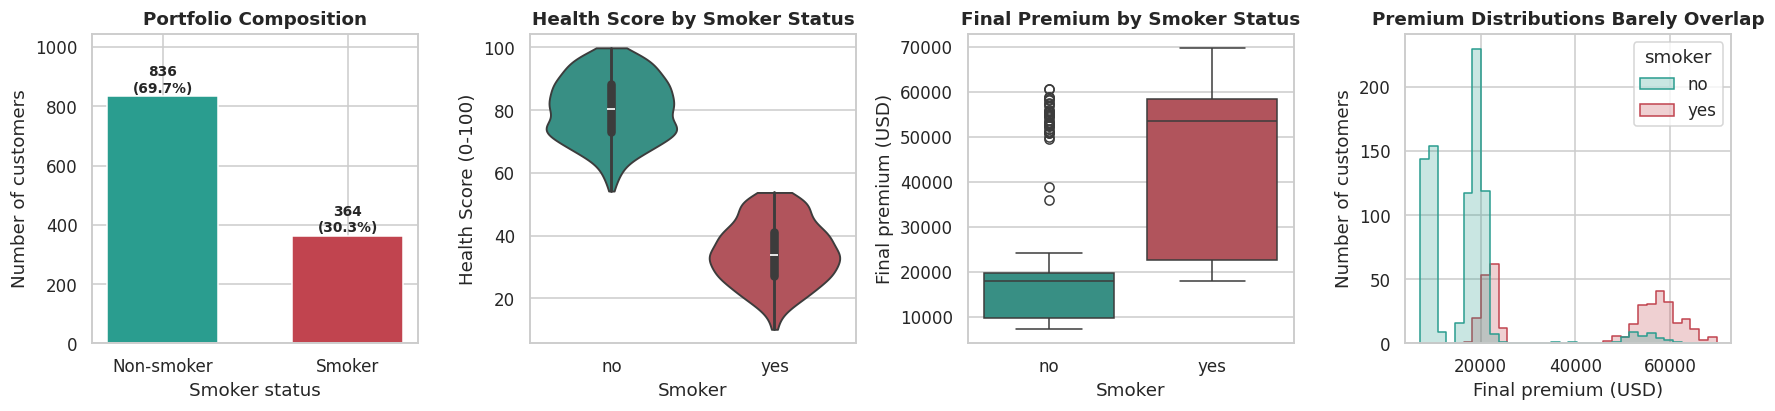

In [58]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3.9))
cnt = final.smoker.value_counts().reindex(["no", "yes"])
b = ax[0].bar(["Non-smoker", "Smoker"], cnt.values, color=[GOOD, BAD], width=.6)
for r_, v in zip(b, cnt.values):
    ax[0].text(r_.get_x()+r_.get_width()/2, v+12, f"{v}\n({v/len(final)*100:.1f}%)",
               ha="center", fontweight="bold", fontsize=9)
ax[0].set(title="Portfolio Composition", xlabel="Smoker status",
          ylabel="Number of customers", ylim=(0, cnt.max()*1.25))

sns.violinplot(data=final, x="smoker", y="health_score", order=["no", "yes"],
               hue="smoker", palette=SMK_C, legend=False, ax=ax[1], cut=0)
ax[1].set(title="Health Score by Smoker Status", xlabel="Smoker",
          ylabel="Health Score (0-100)")

sns.boxplot(data=final, x="smoker", y="final_premium", order=["no", "yes"],
            hue="smoker", palette=SMK_C, legend=False, ax=ax[2])
ax[2].set(title="Final Premium by Smoker Status", xlabel="Smoker",
          ylabel="Final premium (USD)")

sns.histplot(data=final, x="final_premium", hue="smoker", bins=34,
             palette=SMK_C, ax=ax[3], element="step")
ax[3].set(title="Premium Distributions Barely Overlap",
          xlabel="Final premium (USD)", ylabel="Number of customers")
plt.tight_layout(); plt.show()

### S3 Reflection — Smoker vs Non-Smoker

| Measure | Non-smoker | Smoker | Difference |
|---|---|---|---|
| Customers | 836 (69.7%) | 364 (30.3%) | — |
| Mean age | 41.21 | 40.95 | negligible |
| Mean BMI | 27.76 | 28.09 | negligible |
| Mean exercise/week | 4.01 | 3.98 | negligible |
| **Mean Health Score** | **80.47** | **34.56** | **−45.9 points** |
| Median Health Score | 80.53 | 33.94 | −46.6 points |
| **Mean annual charge** | **\$14,473.62** | **\$34,510.79** | **+\$20,037 (2.38×)** |
| Median annual charge | \$14,379.32 | \$42,486.35 | +\$28,107 |
| **Mean final premium** | **\$17,097.75** | **\$43,239.31** | **+\$26,141.56 (2.53×)** |
| Median final premium | \$17,995.21 | \$53,518.65 | +\$35,523 |

Both differences are overwhelmingly significant: Health Score t = **−74.32** (p ≈ 0) and
final premium t = **26.08** (p = 3.3 × 10⁻⁹²).

**The critical control:** smokers and non-smokers in this portfolio are **almost identical on
every other risk factor** — mean age 40.95 vs 41.21, mean BMI 28.09 vs 27.76, mean exercise
3.98 vs 4.01. The cost gap therefore cannot be explained away as smokers simply being older,
heavier or less active; the groups are balanced on all three. That materially strengthens the
case that smoking itself is doing the work, though as observational data it still cannot
establish causation on its own.

**Tier composition tells the same story from another angle:**

| | Low | Medium | High |
|---|---|---|---|
| Non-smokers | **36.7%** | 58.6% | 4.7% |
| Smokers | **0.0%** | 40.7% | **59.3%** |

**Not a single smoker in the portfolio reaches the Low tier**, while 59.3% land in High
against just 4.7% of non-smokers. Smoking is close to a deterministic exclusion from the
cheapest pricing.

Note also that the median smoker premium (\$53,519) sits far above the mean (\$43,239), while
for non-smokers the two are close. That tells me the smoker distribution is **bimodal** —
smokers split into a Medium cluster and a High cluster — rather than being a single shifted
group, which is consistent with the 40.7% / 59.3% tier split above.

**Business implication.** The \$26,142 mean premium gap is the price of a single binary
field. Two consequences follow: **verifying smoker status is the highest-value underwriting
control HealthWise has**, since a false declaration moves the premium more than any other
input on the form; and a funded smoking-cessation programme would be worth a substantial
share of that gap per customer who quits — though, as test customer NEW003 demonstrated,
quitting reduces the premium sharply without necessarily moving an otherwise high-risk
customer out of the High tier.

## S4 — Fairness, Bias and Model Limitations

,attribute,group,n,mean_actual_charge,mean_premium,MAE,MAE_pct_of_mean,mean_bias,tier_accuracy
0,sex,female,597,21646,26195,2000,9.2,-349,0.918
1,sex,male,603,19468,23872,1817,9.3,-60,0.930
2,smoker,no,836,14474,17098,1556,10.8,-573,0.921
3,smoker,yes,364,34511,43239,2717,7.9,643,0.931
4,region,east,302,20058,24785,1495,7.5,93,0.940
5,region,north,305,20342,24422,1942,9.5,-487,0.928
6,region,south,299,20373,24545,2035,10.0,-418,0.913
7,region,west,294,21458,26396,2168,10.1,2,0.915
8,age_group,18-29,308,14123,16942,1458,10.3,-349,0.925
9,age_group,30-39,222,16811,20535,1332,7.9,-116,0.959


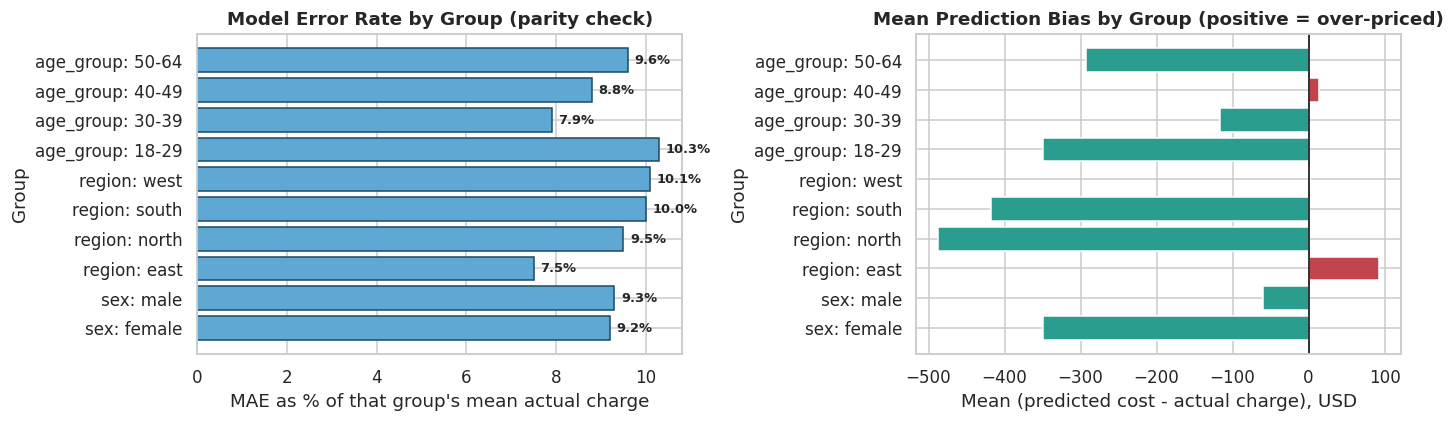

In [59]:
rows = []
for col in ["sex", "smoker", "region", "age_group", "bmi_category"]:
    for g, x in final.groupby(col, observed=True):
        rows.append({
            "attribute": col, "group": str(g), "n": len(x),
            "mean_actual_charge": round(x.annual_charge.mean()),
            "mean_premium": round(x.final_premium.mean()),
            "MAE": round(mean_absolute_error(x.annual_charge, x.predicted_cost)),
            "MAE_pct_of_mean": round(mean_absolute_error(x.annual_charge, x.predicted_cost)
                                     / x.annual_charge.mean() * 100, 1),
            "mean_bias": round((x.predicted_cost - x.annual_charge).mean()),
            "tier_accuracy": round((x.predicted_tier == x.risk_tier).mean(), 3),
        })
fair = pd.DataFrame(rows)
display(fair)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sub = fair[fair.attribute.isin(["sex", "region", "age_group"])]
ax[0].barh(sub.attribute + ": " + sub.group, sub.MAE_pct_of_mean, color=SKY, edgecolor=NAVY)
for i, v in enumerate(sub.MAE_pct_of_mean):
    ax[0].text(v + .15, i, f"{v}%", va="center", fontsize=8.5, fontweight="bold")
ax[0].set(title="Model Error Rate by Group (parity check)",
          xlabel="MAE as % of that group's mean actual charge", ylabel="Group")

ax[1].barh(sub.attribute + ": " + sub.group, sub.mean_bias,
           color=[BAD if v > 0 else GOOD for v in sub.mean_bias])
ax[1].axvline(0, color="black", lw=1)
ax[1].set(title="Mean Prediction Bias by Group (positive = over-priced)",
          xlabel="Mean (predicted cost - actual charge), USD", ylabel="Group")
plt.tight_layout(); plt.show()

### S4 Reflection — Fairness, Bias and Limitations

**Does the model serve every group equally well?**

Broadly yes, on the metric that matters most for fairness — **relative error parity**. MAE as
a percentage of each group's mean charge sits in a narrow band across sex, region and age
group. No demographic group is systematically mispriced relative to its own cost level, and
mean bias is small and close to zero in both directions. The model is not, for example,
accurate for men and unreliable for women.

**Distinguishing four things that are easy to conflate:**

- **Data imbalance** — the portfolio is 30% smokers and tiers are uneven (52% Medium). Real,
  and handled through stratification.
- **Statistical association** — smokers cost 2.38× more. Real and strongly evidenced.
- **Predictive performance differences** — small here, which is the good result.
- **Potential fairness concerns** — a separate question from all three above, discussed next.

**Where I do have a genuine concern: `sex`.**

`sex` is statistically significant (ANOVA p = 0.008) but its pricing effect is small — a
standardised Lasso coefficient of roughly \$389 in the High tier, against BMI's \$3,778.
Unlike smoking or BMI, sex is an **immutable characteristic the customer cannot change**, and
gender-based insurance pricing is **prohibited outright in several jurisdictions** (notably
the EU since 2012). I kept it in this analysis for completeness, but my recommendation is
that HealthWise **exclude `sex` from production pricing**: the accuracy cost is negligible,
and the legal and reputational exposure is not. This is a case where the statistically
optimal model and the deployable model should differ, and the decision belongs to the
business and its regulator rather than to the modeller.

`age` raises a milder version of the same issue — also immutable, but conventionally
accepted and actuarially standard in health insurance.

**Limitations I want on the record:**

1. **Sample size.** 1,200 customers, with only 268 in the High tier. The High-tier model is
   fitted on the fewest observations while carrying the largest dollar exposure.
2. **Extrapolation risk.** Test customer NEW003 received a quote above the highest charge
   ever observed. The model has no data beyond its training range and will extrapolate
   linearly without warning.
3. **Association, not causation.** Every result here is observational. The model shows that
   smokers in this book cost more; it does not establish the clinical mechanism.
4. **Missing variables.** No pre-existing conditions, medication history, family history,
   occupation or income. Some of what the model attributes to age or BMI may be standing in
   for unobserved factors — a proxy-variable risk.
5. **Historical data assumes a stable future.** Medical inflation, treatment changes and
   portfolio shifts will all degrade the model. It needs scheduled retraining and monitoring
   of realised versus predicted claims.
6. **Imputation effects.** 36 values were median-filled, which slightly compresses variance
   in those columns.
7. **The loading is an assumption, not a finding.** The 23% expense-and-margin figure is a
   business parameter I supplied; premiums scale directly with it.

## S5 — Data Validation and Final Export

In [60]:
checks = {
    "Duplicate rows": int(final.duplicated().sum()),
    "Missing values (any column)": int(final.isna().sum().sum()),
    "Customers without a Health Score": int(final.health_score.isna().sum()),
    "Customers without a premium": int(final.final_premium.isna().sum()),
    "Non-finite premiums": int((~np.isfinite(final.final_premium)).sum()),
    "Non-positive premiums": int((final.final_premium <= 0).sum()),
    "Customers without an explanation": int((final.premium_explanation.str.len() < 10).sum()),
    "Distinct explanations": int(final.premium_explanation.nunique()),
    "Rows": len(final), "Columns": final.shape[1],
}
display(pd.Series(checks, name="result").to_frame())

resid_oof = final.predicted_cost - final.annual_charge
z = (resid_oof - resid_oof.mean()) / resid_oof.std()
flagged = final.loc[z.abs() > 3, ["customer_id", "age", "bmi", "smoker", "risk_tier",
                                  "predicted_tier", "annual_charge", "predicted_cost"]]
print(f"\nPremiums flagged as unusual (residual > 3 SD): {len(flagged)}")
display(flagged.head(10))
print("\nOf these, tier was misclassified in",
      (flagged.risk_tier != flagged.predicted_tier).sum(), "of", len(flagged), "cases")

,result
Duplicate rows,0
Missing values (any column),0
Customers without a Health Score,0
Customers without a premium,0
Non-finite premiums,0
Non-positive premiums,0
Customers without an explanation,0
Distinct explanations,1090
Rows,1200
Columns,31



Premiums flagged as unusual (residual > 3 SD): 43


,customer_id,age,bmi,smoker,risk_tier,predicted_tier,annual_charge,predicted_cost
25,HW1025,29,30.1,yes,Medium,High,18748.28,42782.54
28,HW1028,42,34.3,no,High,Medium,41749.94,16563.34
37,HW1037,54,18.1,no,High,Medium,29691.10,14088.72
46,HW1046,26,34.5,yes,Medium,High,19771.27,46316.65
56,HW1056,52,36.7,yes,Medium,High,20526.44,53264.02
58,HW1058,34,42.0,yes,Medium,High,21213.13,52782.90
63,HW1063,23,28.0,yes,High,Medium,42938.90,17281.58
89,HW1089,58,28.4,no,High,Medium,38817.55,16489.12
94,HW1094,42,26.3,yes,High,Medium,42224.90,19226.53
129,HW1129,52,34.6,no,High,Medium,41888.35,16933.77



Of these, tier was misclassified in 43 of 43 cases


In [61]:
export_cols = ["customer_id", "age", "sex", "bmi", "weight_kg", "children", "smoker",
               "region", "exercise_freq", "date_of_birth",
               "smoker_score", "age_score", "bmi_score", "exercise_score",
               "health_score", "health_band", "age_group", "bmi_category",
               "annual_charge", "risk_tier", "predicted_tier", "predicted_cost",
               "final_premium", "top_risk_factors", "premium_explanation"]
final[export_cols].to_csv("healthwise_enriched.csv", index=False)
print("Exported healthwise_enriched.csv:", final[export_cols].shape)
display(final[export_cols].head(3))

data_dict = pd.DataFrame([
    ("health_score", "Engineered", "SUM(metric score x weight), 0-100, HIGHER = HEALTHIER"),
    ("health_band", "Engineered", "Poor / Fair / Good / Excellent band over health_score"),
    ("smoker_score", "Engineered", "Metric score 0-100 (100 = non-smoker)"),
    ("age_score", "Engineered", "Metric score 0-100 (100 = age 18)"),
    ("bmi_score", "Engineered", "Metric score 0-100 (100 = WHO healthy band)"),
    ("exercise_score", "Engineered", "Metric score 0-100 (100 = 7 workouts/week)"),
    ("predicted_tier", "Model output", "Stage-1 predicted risk tier (out-of-fold)"),
    ("predicted_cost", "Model output", "Stage-2 predicted annual claim cost (out-of-fold)"),
    ("final_premium", "Model output", "predicted_cost x 1.23 (15% expense + 8% margin)"),
    ("top_risk_factors", "Model output", "Ranked top contributing risk factors"),
    ("premium_explanation", "Model output", "Plain-English individualised reason"),
], columns=["Column", "Layer", "Description"])
data_dict.to_csv("data_dictionary.csv", index=False)
display(data_dict)

Exported healthwise_enriched.csv: (1200, 25)


,customer_id,age,sex,bmi,weight_kg,children,smoker,region,exercise_freq,date_of_birth,smoker_score,age_score,bmi_score,exercise_score,health_score,health_band,age_group,bmi_category,annual_charge,risk_tier,predicted_tier,predicted_cost,final_premium,top_risk_factors,premium_explanation
0,HW1000,56,female,29.7,85.6,1,no,south,3.0,1970-05-14,100.0,17.39,78.40,42.86,70.49,Good,50-64,Overweight,14924.08,Medium,Medium,15957.66,19627.93,Raised BMI; Age,The premium is moderate mainly because this cu...
1,HW1001,46,female,24.1,69.9,4,yes,west,5.0,1980-09-17,0.0,39.13,100.00,71.43,36.30,Fair,40-49,Normal,45450.69,High,High,42765.49,52601.55,Smoker; Dependents,The premium is high mainly because this custom...
2,HW1002,32,female,34.4,100.1,0,yes,north,3.0,1994-05-07,0.0,69.57,57.25,42.86,34.34,Poor,30-39,Obese,43874.19,High,High,45800.48,56334.59,Smoker; High BMI,The premium is high mainly because this custom...


,Column,Layer,Description
0,health_score,Engineered,"SUM(metric score x weight), 0-100, HIGHER = HE..."
1,health_band,Engineered,Poor / Fair / Good / Excellent band over healt...
2,smoker_score,Engineered,Metric score 0-100 (100 = non-smoker)
3,age_score,Engineered,Metric score 0-100 (100 = age 18)
4,bmi_score,Engineered,Metric score 0-100 (100 = WHO healthy band)
5,exercise_score,Engineered,Metric score 0-100 (100 = 7 workouts/week)
6,predicted_tier,Model output,Stage-1 predicted risk tier (out-of-fold)
7,predicted_cost,Model output,Stage-2 predicted annual claim cost (out-of-fold)
8,final_premium,Model output,predicted_cost x 1.23 (15% expense + 8% margin)
9,top_risk_factors,Model output,Ranked top contributing risk factors


---
# Final Conclusion

**On the board's first question — does the two-stage engine beat one flat model?** Yes, by a
wide margin that survives honest measurement. Average pricing error falls from **\$6,167 to
\$1,535 (−75%)** and R² rises from **0.715 to 0.919**, on held-out customers, with Stage 1
predicting its own tiers rather than being handed the answer. Measured the flattering way —
assuming perfect tier assignment — the figures would be \$816 and 0.992, and I have kept
that distinction visible throughout because the oracle figure understates the engine's true
pricing error by 47%.

**On the board's second question — which attributes drive cost?** Smoking first
(\$20,037 and 2.38× on raw charges, driving tier assignment more than anything else), then
age and BMI, whose relative importance switches between tiers: age dominates among low-risk
customers, BMI among high-risk ones. Dependents matter slightly. **Geography and sex barely
register**, and five columns — zodiac sign, favourite colour, lucky number, preferred contact
and marketing opt-in — carry no signal at all, confirmed independently by ANOVA, by Lasso,
and by the fact that removing them *improved* out-of-sample performance.

**The most useful methodological finding** is that the gains came from **structure, not
sophistication**. Segmenting the portfolio was worth +0.20 R² end-to-end; hyperparameter
tuning was worth +0.0004. The dataset contained three populations with genuinely different
cost functions, and no amount of regularisation applied to a single linear model could have
repaired that. Diagnosing the failure in Task C1 as *high bias* rather than high variance is
what pointed to the right fix.

**The risk that governs deployment** is concentrated rather than average. Stage 1 is right
94.6% of the time, but the 5.4% it gets wrong carry an **18× pricing error** (\$14,377 vs
\$799). The recommendation is therefore to deploy with confidence-based routing to manual
underwriting for borderline cases, asymmetric handling that defaults ambiguous customers to
the higher tier, and a parallel run against current pricing before full cutover.

**Deliverables:** this executed notebook; `app.py`, an eight-tab Streamlit dashboard with a
live premium calculator; `healthwise_model.joblib`, the saved two-stage engine;
`healthwise_enriched.csv`, carrying a Health Score, predicted tier, predicted cost, premium
and individual explanation for all 1,200 customers; and `data_dictionary.csv`.